# PrediRuta: clase de accidente

En este notebook se explorará la construcción del modelo de `clase de accidente según PrediRuta`, mediante la estimación de la categoría de un accidente condicionado a que el evento ocurra. La salida se define como `CHOQUE`, `ATROPELLO` u `OTROS`.

Se plantea utilizar información espacial, temporal, meteorológica y vial, incorporando las 150 zonas definidas por el modelo de ocurrencia. El notebook compara un escenario completo, que añade la caracterización vial enriquecida, con uno operativo, restringido a ubicación y tiempo. En ambos casos se evalúan versiones con y sin clima. La categoría `SIN INFORMACION` se excluye y las clases minoritarias distintas de atropello se agrupan en `OTROS`.

Por medio de la evaluación de diferentes algoritmos mediante una partición temporal, se pretende determinar si es posible anticipar la clase del accidente usando información disponible o derivable en una consulta real.

**Consideraciones metodológicas**

1. Cada accidente conserva la `ZONA_CIUDAD` asignada mediante las mismas 150 zonas del modelo de ocurrencia.
2. La tabla se reduce a una fila por `ACCIDENTE_ID`, porque la clase pertenece al accidente y no al actor.
3. `SIN INFORMACION` se excluye antes de dividir los datos.
4. `CHOQUE` y `ATROPELLO` se conservan; las demás clases observables se agrupan en `OTROS`.
5. Los escenarios `completo` y `operativo` utilizan los mismos accidentes.
6. Los hiperparámetros se ajustan independientemente para los alcances completo y operativo utilizando el escenario con clima; la configuración seleccionada se reutiliza sin clima para aislar el aporte meteorológico.
7. Se evaluará el efecto de la distribución temporal de los datos para la generación de la predicción.
8. `ANIO` se utilizará para realizar la partición temporal, pero no como predictor.

## 0. Configuración

In [ ]:
# Importar librarias necesarias

from pathlib import Path
from time import perf_counter
import json
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from IPython.display import display
from pyproj import Transformer
from scipy.spatial import cKDTree
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score, log_loss,
    precision_recall_curve, roc_auc_score, roc_curve
)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
warnings.filterwarnings('ignore', category=FutureWarning)


In [ ]:
# Parámetros generales 

SEMILLA = 42
NUMERO_ZONAS = 150
TAMANO_CELDA_METROS = 500

VARIABLES_CLIMA_ORIGINALES = [
    'TEMPERATURA_2M', 'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA',
    'PRECIPITACION', 'LLUVIA', 'NUBOSIDAD', 'PRESION_SUPERFICIE',
    'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M'
]
VARIABLES_CLIMA_RETIRADAS_CORRELACION = [
    'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA', 'LLUVIA'
]
VARIABLES_CLIMA_CRUDAS = [
    variable for variable in VARIABLES_CLIMA_ORIGINALES
    if variable not in VARIABLES_CLIMA_RETIRADAS_CORRELACION
]

In [ ]:
# Ruta directa desde la carpeta modelo/
CARPETA_DATOS = Path('../data/data_procesada/modelado')
RUTA_MODELADO = CARPETA_DATOS / 'TABLA_COMPLETA_MODELADO.csv'

## 1. Carga e integración de los datos

`TABLA_COMPLETA_MODELADO` contiene información de accidentes, actores y vehículos. Como la variable objetivo pertenece al accidente, primero se seleccionan únicamente columnas constantes dentro de cada evento y luego se eliminan las repeticiones ocasionadas por sus actores o vehículos asociados. Así, cada accidente aporta exactamente una observación al modelo.

In [ ]:
# Columnas de interés para el modelado de clase de accidente
COLUMNAS_VIA_CATEGORICAS = [
    'GEOMETRIA_PLANTA', 'GEOMETRIA_TERRENO', 'GEOMETRIA_SECCION',
    'SENTIDO_VIA', 'SUPERFICIE_RODADURA', 'ESTADO_VIA',
    'CONDICION_VIA', 'ILUMINACION_ARTIFICIAL', 'SEMAFORO'
]
COLUMNAS_VIA_NUMERICAS = ['N_CALZADAS', 'N_CARRILES']
COLUMNAS_VIA = [*COLUMNAS_VIA_CATEGORICAS, *COLUMNAS_VIA_NUMERICAS]

COLUMNAS_ACCIDENTE = [
    'ACCIDENTE_ID', 'FECHA_HORA',
    'LATITUD', 'LONGITUD', 'CELDA_ID', 'CELDA_X', 'CELDA_Y',
    'ZONA_CIUDAD', 'LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE',
    'ANIO', 'MES', 'DIA_SEMANA', 'HORA', 'FIN_SEMANA',
    *VARIABLES_CLIMA_ORIGINALES,
    *COLUMNAS_VIA,
    'CLASE_ACCIDENTE', 'CLASE_ACCIDENTE_DESC'
]

In [ ]:
# Carga de datos
tabla_modelado = pd.read_csv(
    RUTA_MODELADO,
    usecols=COLUMNAS_ACCIDENTE,
    encoding='utf-8-sig',
    parse_dates=['FECHA_HORA'],
    low_memory=False
)

In [ ]:
# Construcción de centroides de zona y estructura para asignar zonas a coordenadas
centroides_zona = (
    tabla_modelado[
        ['ZONA_CIUDAD', 'LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']
    ]
    .drop_duplicates()
    .sort_values('ZONA_CIUDAD')
    .reset_index(drop=True)
)
assert len(centroides_zona) == NUMERO_ZONAS
assert centroides_zona['ZONA_CIUDAD'].nunique() == NUMERO_ZONAS

# Transformación de coordenadas de EPSG:3116 (Bogotá) a EPSG:4326 (WGS84)
bogota_a_wgs84 = Transformer.from_crs('EPSG:3116', 'EPSG:4326', always_xy=True)
arbol_zonas = cKDTree(
    centroides_zona[['LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']].to_numpy()
)

In [ ]:
# Preparación de datos para modelado de clase de accidente
datos = tabla_modelado.drop_duplicates().copy()
datos['CLASE_ACCIDENTE'] = datos['CLASE_ACCIDENTE'].astype('int64')
datos['ZONA_CIUDAD'] = datos['ZONA_CIUDAD'].astype('int16')

assert datos['ACCIDENTE_ID'].is_unique
assert datos['CLASE_ACCIDENTE'].notna().all()

display(datos.head())
datos.info()

,ACCIDENTE_ID,FECHA_HORA,LATITUD,LONGITUD,CELDA_ID,CELDA_X,CELDA_Y,ZONA_CIUDAD,LATITUD_CENTROIDE,LONGITUD_CENTROIDE,...,SENTIDO_VIA,SUPERFICIE_RODADURA,ESTADO_VIA,CONDICION_VIA,ILUMINACION_ARTIFICIAL,SEMAFORO,N_CALZADAS,N_CARRILES,CLASE_ACCIDENTE,CLASE_ACCIDENTE_DESC
0,12798,2007-01-01 00:00:00,4.629939,-74.080151,1999_2007,1999,2007,70,4.629379,-74.080767,...,0,0,0,0,0,0,NaN,NaN,7,VOLCAMIENTO
1,10819805,2007-01-01 00:00:00,4.629939,-74.080151,1999_2007,1999,2007,70,4.629379,-74.080767,...,5,4,1,8,1,1,2.0,3.0,7,VOLCAMIENTO
2,13707,2007-01-01 00:45:00,4.742590,-74.100732,1994_2032,1994,2032,129,4.746599,-74.096256,...,0,0,0,0,0,0,NaN,NaN,4,CHOQUE
4,10819463,2007-01-01 00:45:00,4.742590,-74.100732,1994_2032,1994,2032,129,4.746599,-74.096256,...,3,3,1,8,1,1,1.0,2.0,4,CHOQUE
6,12839,2007-01-01 00:50:00,4.628402,-74.184284,1976_2007,1976,2007,0,4.633981,-74.186260,...,0,0,0,0,0,0,NaN,NaN,4,CHOQUE


<class 'pandas.core.frame.DataFrame'>
Index: 895346 entries, 0 to 1928613
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   ACCIDENTE_ID            895346 non-null  int64         
 1   FECHA_HORA              895346 non-null  datetime64[ns]
 2   LATITUD                 895346 non-null  float64       
 3   LONGITUD                895346 non-null  float64       
 4   CELDA_ID                895346 non-null  object        
 5   CELDA_X                 895346 non-null  int64         
 6   CELDA_Y                 895346 non-null  int64         
 7   ZONA_CIUDAD             895346 non-null  int16         
 8   LATITUD_CENTROIDE       895346 non-null  float64       
 9   LONGITUD_CENTROIDE      895346 non-null  float64       
 10  ANIO                    895346 non-null  int64         
 11  MES                     895346 non-null  int64         
 12  DIA_SEMANA              895346 non

In [ ]:
# Creación de inventario de datos
inventario = pd.DataFrame({
    'CONJUNTO': ['TABLA_MODELADO', 'ACCIDENTES', 'ACCIDENTES_MODELO_CLASE'],
    'FILAS': [len(tabla_modelado), tabla_modelado['ACCIDENTE_ID'].nunique(), len(datos)],
    'UNIDADES_UNICAS': [
        tabla_modelado['ACCIDENTE_ID'].nunique(),
        tabla_modelado['ACCIDENTE_ID'].nunique(),
        datos['ACCIDENTE_ID'].nunique()
    ]
})
display(inventario)

,CONJUNTO,FILAS,UNIDADES_UNICAS
0,TABLA_MODELADO,1928614,895346
1,ACCIDENTES,895346,895346
2,ACCIDENTES_MODELO_CLASE,895346,895346


In [ ]:
# Estadísticas descriptivas de las variables numéricas
columnas_no_descriptivas = ['ACCIDENTE_ID', 'CELDA_ID', 'CLIMA_ID']

descriptivas = (
    datos.select_dtypes(include='number')
    .drop(columns=columnas_no_descriptivas, errors='ignore')
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
    .round(4)
)

display(descriptivas)

,count,mean,std,min,5%,25%,50%,75%,95%,max
LATITUD,895346.0,4.6505,0.0558,4.4697,4.5623,4.6107,4.6472,4.6906,4.7445,4.8232
LONGITUD,895346.0,-74.1015,0.0398,-74.2186,-74.1704,-74.1308,-74.0999,-74.0703,-74.0414,-74.0132
CELDA_X,895346.0,1994.1808,8.8379,1968.0000,1979.0000,1988.0000,1995.0000,2001.0000,2008.0000,2014.0000
CELDA_Y,895346.0,2011.4946,12.3480,1972.0000,1992.0000,2003.0000,2011.0000,2020.0000,2032.0000,2050.0000
ZONA_CIUDAD,895346.0,71.9778,42.6110,0.0000,7.0000,35.0000,72.0000,109.0000,140.0000,149.0000
LATITUD_CENTROIDE,895346.0,4.6504,0.0557,4.4751,4.5644,4.6112,4.6486,4.6900,4.7463,4.8048
LONGITUD_CENTROIDE,895346.0,-74.1015,0.0397,-74.2038,-74.1702,-74.1305,-74.1010,-74.0706,-74.0413,-74.0243
ANIO,895346.0,2014.6314,4.7637,2007.0000,2007.0000,2011.0000,2015.0000,2018.0000,2023.0000,2026.0000
MES,895346.0,6.5848,3.4253,1.0000,1.0000,4.0000,7.0000,10.0000,12.0000,12.0000
DIA_SEMANA,895346.0,2.9176,1.9139,0.0000,0.0000,1.0000,3.0000,5.0000,6.0000,6.0000


In [ ]:
# Estadísticas descriptivas de la variable categórica objetivo

catalogo_clases = (
    datos[['CLASE_ACCIDENTE', 'CLASE_ACCIDENTE_DESC']]
    .drop_duplicates()
    .set_index('CLASE_ACCIDENTE')['CLASE_ACCIDENTE_DESC']
    .to_dict()
)

resumen_objetivo = (
    datos['CLASE_ACCIDENTE']
    .value_counts(dropna=False)
    .sort_index()
    .rename('CASOS')
    .to_frame()
)
resumen_objetivo['DESCRIPCION'] = [
    catalogo_clases.get(codigo, 'NO CATALOGADA')
    for codigo in resumen_objetivo.index
]
resumen_objetivo['PORCENTAJE'] = (
    100 * resumen_objetivo['CASOS'] / len(datos)
).round(4)
resumen_objetivo = (
    resumen_objetivo.reset_index()
    .rename(columns={'CLASE_ACCIDENTE': 'CODIGO'})
    [['CODIGO', 'DESCRIPCION', 'CASOS', 'PORCENTAJE']]
)
display(resumen_objetivo)

,CODIGO,DESCRIPCION,CASOS,PORCENTAJE
0,0,SIN INFORMACION,278,0.0310
1,1,ATROPELLO,105206,11.7503
2,2,AUTOLESION,4383,0.4895
3,3,CAIDA DE OCUPANTE,20387,2.2770
4,4,CHOQUE,742846,82.9675
5,5,INCENDIO,89,0.0099
6,6,OTRO,10598,1.1837
7,7,VOLCAMIENTO,11559,1.2910


#### Análisis

La tabla original contiene cerca de **1,93 millones de filas**, que se reducen a **895.346 accidentes únicos** para evitar que los eventos con varios actores o vehículos tengan mayor peso. En `CLASE_ACCIDENTE` se observa un desbalance marcado: `CHOQUE` representa aproximadamente el **82,97 %** de los accidentes y `ATROPELLO` el **11,75 %**. Las categorías restantes tienen participaciones individuales reducidas y `SIN INFORMACION` corresponde apenas al **0,03 %**. Esta distribución sustenta la exclusión de los registros sin información y la posterior agrupación de las categorías minoritarias en `OTROS`, decisión que se desarrolla en la siguiente sección.

## 2. Análisis descriptivo de la clase de accidente

Se analizan las frecuencias y la estabilidad temporal de las categorías originales de `CLASE_ACCIDENTE`. Después se documenta la agrupación operativa, se revisan valores faltantes, distribuciones continuas, correlaciones meteorológicas, patrones temporales y comportamiento de las 150 zonas.

### 2.0 Análisis de la variable de respuesta

In [ ]:
# Estadísticas descriptivas de la variable categórica objetivo por año
conteo_anual = pd.crosstab(datos['ANIO'], datos['CLASE_ACCIDENTE'])
conteo_anual.columns = [
    catalogo_clases.get(codigo, str(codigo))
    for codigo in conteo_anual.columns
]
display(conteo_anual)

,SIN INFORMACION,ATROPELLO,AUTOLESION,CAIDA DE OCUPANTE,CHOQUE,INCENDIO,OTRO,VOLCAMIENTO
ANIO,,,,,,,,
2007,136,7511,0,1137,46462,0,2817,1235
2008,142,5727,469,670,47314,8,1468,766
2009,0,5079,874,787,36604,2,486,225
2010,0,6987,1539,1041,42608,2,668,429
2011,0,7034,603,1139,45091,8,852,569
2012,0,7441,544,1196,46768,4,823,788
2013,0,7253,241,953,48230,4,623,409
2014,0,6622,94,1162,47042,2,628,351
2015,0,6866,7,1462,45976,2,303,486


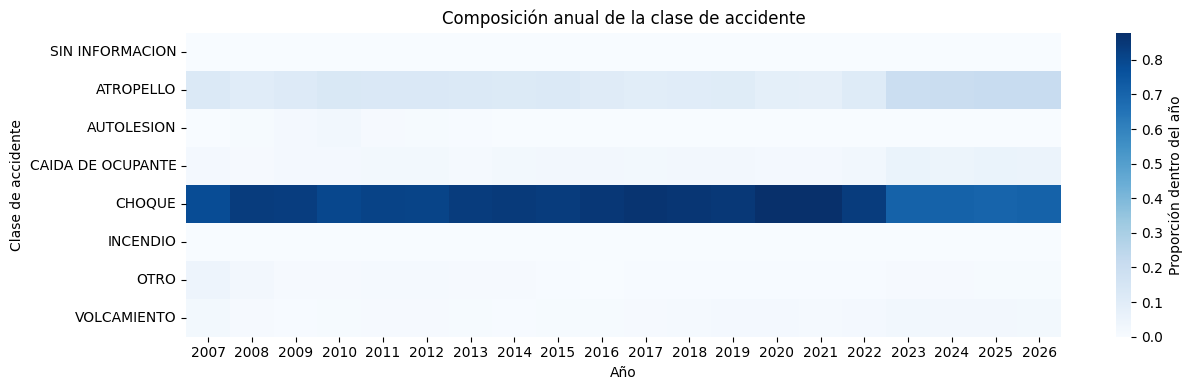

In [ ]:
# Gráfico de composición anual de la clase de accidente
fig, ax = plt.subplots(figsize=(13, 4))
proporcion_anual = conteo_anual.div(conteo_anual.sum(axis=1), axis=0)
sns.heatmap(
    proporcion_anual.T, cmap='Blues', ax=ax,
    cbar_kws={'label': 'Proporción dentro del año'}
)
ax.set_title('Composición anual de la clase de accidente')
ax.set_xlabel('Año')
ax.set_ylabel('Clase de accidente')
plt.tight_layout()
plt.show()

In [ ]:
# Frecuencia de presencia de cada clase a lo largo del tiempo
resumen_clases = (
    datos.groupby('CLASE_ACCIDENTE')
    .agg(
        CASOS=('ACCIDENTE_ID', 'size'),
        PRIMER_ANIO=('ANIO', 'min'),
        ULTIMO_ANIO=('ANIO', 'max'),
        ANIOS_CON_REGISTROS=('ANIO', 'nunique')
    )
    .reset_index()
)
resumen_clases['DESCRIPCION'] = resumen_clases['CLASE_ACCIDENTE'].map(catalogo_clases)
resumen_clases['PORCENTAJE_TOTAL'] = 100 * resumen_clases['CASOS'] / len(datos)
display(resumen_clases)

,CLASE_ACCIDENTE,CASOS,PRIMER_ANIO,ULTIMO_ANIO,ANIOS_CON_REGISTROS,DESCRIPCION,PORCENTAJE_TOTAL
0,0,278,2007,2008,2,SIN INFORMACION,0.031049
1,1,105206,2007,2026,20,ATROPELLO,11.750318
2,2,4383,2008,2017,10,AUTOLESION,0.489531
3,3,20387,2007,2026,20,CAIDA DE OCUPANTE,2.276997
4,4,742846,2007,2026,20,CHOQUE,82.967478
5,5,89,2008,2025,18,INCENDIO,0.009940
6,6,10598,2007,2026,20,OTRO,1.183676
7,7,11559,2007,2026,20,VOLCAMIENTO,1.291009


#### Distribución y estabilidad temporal de la clase de accidente

La variable `CLASE_ACCIDENTE` presenta un desbalance marcado. `CHOQUE` concentra aproximadamente el **82,97 %** de los accidentes, seguido de `ATROPELLO` con **11,75 %**. Las demás categorías representan individualmente menos del 2,5 % de los registros.

La revisión temporal muestra además diferencias importantes en la estabilidad de las categorías. `ATROPELLO`, `CAIDA DE OCUPANTE`, `CHOQUE`, `OTRO` y `VOLCAMIENTO` tienen registros durante los 20 años analizados. En contraste, `SIN INFORMACION` aparece únicamente entre 2007 y 2008, mientras que `AUTOLESION` deja de registrarse después de 2017. `INCENDIO`, aunque aparece en varios años, cuenta con solo **89 casos** en todo el periodo.

La composición anual también evidencia cambios temporales, especialmente en los años recientes, donde disminuye la participación relativa de `CHOQUE` y aumenta la de `ATROPELLO`. Estos cambios deben considerarse al mantener una partición temporal y al interpretar la capacidad de generalización del modelo.

In [ ]:
# Retirar SIN INFORMACION y construir las tres clases antes de cualquier partición
CODIGO_SIN_INFORMACION = 0
AGRUPACION_CLASES = {
    1: 'ATROPELLO',
    2: 'OTROS',
    3: 'OTROS',
    4: 'CHOQUE',
    5: 'OTROS',
    6: 'OTROS',
    7: 'OTROS'
}
CLASES_MODELO = ['ATROPELLO', 'CHOQUE', 'OTROS']

datos_modelo = datos.loc[
    datos['CLASE_ACCIDENTE'].ne(CODIGO_SIN_INFORMACION)
].copy()
datos_modelo['CLASE_ACCIDENTE_AGRUPADA'] = (
    datos_modelo['CLASE_ACCIDENTE'].map(AGRUPACION_CLASES)
)

registros_retirados = (datos['CLASE_ACCIDENTE'] == CODIGO_SIN_INFORMACION).sum()

print(f'Registros iniciales: {len(datos):,}')
print(f'Registros SIN INFORMACION retirados: {registros_retirados:,}')
print(f'Registros para modelado: {len(datos_modelo):,}')
print(f'Accidentes únicos: {datos_modelo["ACCIDENTE_ID"].nunique():,}')
print(f'Clases conservadas: {sorted(datos_modelo["CLASE_ACCIDENTE_AGRUPADA"].unique())}')

Registros iniciales: 895,346
Registros SIN INFORMACION retirados: 278
Registros para modelado: 895,068
Accidentes únicos: 895,068
Clases conservadas: ['ATROPELLO', 'CHOQUE', 'OTROS']


Después de retirar `SIN INFORMACION`, el conjunto conserva únicamente accidentes con una clase observable. La agrupación se realiza antes de cualquier partición para que entrenamiento, validación y prueba utilicen exactamente la misma definición del objetivo.

In [ ]:
# Desbalance de las tres clases modeladas
resumen_clases_modelo = (
    datos_modelo['CLASE_ACCIDENTE_AGRUPADA']
    .value_counts().reindex(CLASES_MODELO)
    .rename('CASOS').to_frame()
)
resumen_clases_modelo['DESCRIPCION'] = resumen_clases_modelo.index
resumen_clases_modelo['PORCENTAJE'] = (
    100 * resumen_clases_modelo['CASOS'] / len(datos_modelo)
).round(4)
resumen_clases_modelo = (
    resumen_clases_modelo.reset_index()
    .rename(columns={'CLASE_ACCIDENTE_AGRUPADA': 'CLASE'})
    [['CLASE', 'DESCRIPCION', 'CASOS', 'PORCENTAJE']]
)
display(resumen_clases_modelo)

,CLASE,DESCRIPCION,CASOS,PORCENTAJE
0,ATROPELLO,ATROPELLO,105206,11.7540
1,CHOQUE,CHOQUE,742846,82.9932
2,OTROS,OTROS,47016,5.2528


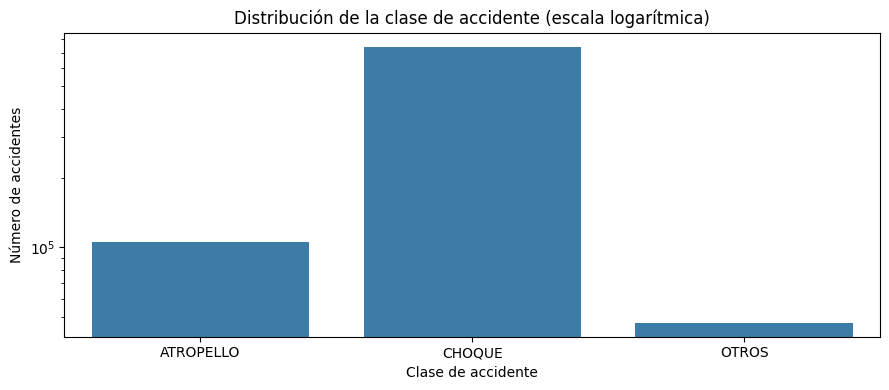

In [ ]:
# Gráfico de distribución de la clase de accidente (escala logarítmica)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=resumen_clases_modelo, x='DESCRIPCION', y='CASOS',
    ax=ax, color='#2C7FB8'
)
ax.set_yscale('log')
ax.set_title('Distribución de la clase de accidente (escala logarítmica)')
ax.set_xlabel('Clase de accidente')
ax.set_ylabel('Número de accidentes')
plt.tight_layout()
plt.show()

In [ ]:
# Faltantes de las variables candidatas para modelado
columnas_candidatas = list(dict.fromkeys([
    'LATITUD', 'LONGITUD', 'CELDA_X', 'CELDA_Y', 'ZONA_CIUDAD',
    'MES', 'DIA_SEMANA', 'HORA',
    *VARIABLES_CLIMA_CRUDAS,
    *COLUMNAS_VIA
]))
faltantes = pd.DataFrame({
    'CASOS_FALTANTES': datos_modelo[columnas_candidatas].isna().sum(),
    'PORCENTAJE_FALTANTES': (
        datos_modelo[columnas_candidatas].isna().mean().mul(100).round(4)
    )
}).sort_values('PORCENTAJE_FALTANTES', ascending=False)
display(faltantes)

,CASOS_FALTANTES,PORCENTAJE_FALTANTES
N_CARRILES,406794,45.4484
N_CALZADAS,406794,45.4484
DIRECCION_VIENTO_10M,0,0.0000
SEMAFORO,0,0.0000
ILUMINACION_ARTIFICIAL,0,0.0000
CONDICION_VIA,0,0.0000
ESTADO_VIA,0,0.0000
SUPERFICIE_RODADURA,0,0.0000
SENTIDO_VIA,0,0.0000
GEOMETRIA_SECCION,0,0.0000


#### Análisis del objetivo agrupado

Aun después de la agrupación, el objetivo mantiene un desbalance considerable. `CHOQUE` concentra aproximadamente el **83 %** de los accidentes, `ATROPELLO` cerca del **11,8 %** y `OTROS` alrededor del **5,3 %**. La nueva definición, sin embargo, evita clases con cantidades extremadamente reducidas de observaciones y permite trabajar con un problema multiclase más estable.

En cuanto a los predictores, los únicos faltantes relevantes corresponden a `N_CARRILES` y `N_CALZADAS`, ambas con aproximadamente **45,45 %** de ausencia. Las demás variables candidatas se encuentran completas. Debido a este nivel de faltantes, estas dos variables requerirán imputación dentro del `Pipeline` y deberán evaluarse únicamente en el escenario completo, ya que además no corresponden a información necesariamente disponible durante una consulta operativa.

### 2.1 Distribuciones numéricas y relaciones continuas

Las distribuciones permiten identificar asimetrías, concentraciones en cero y escalas muy diferentes. Las variables continuas se estandarizan posteriormente dentro del `Pipeline`; esta exploración no modifica todavía los datos.

In [ ]:
# Identificación de variables continuas
variables_continuas = [
    'CELDA_X', 'CELDA_Y', *VARIABLES_CLIMA_ORIGINALES
]

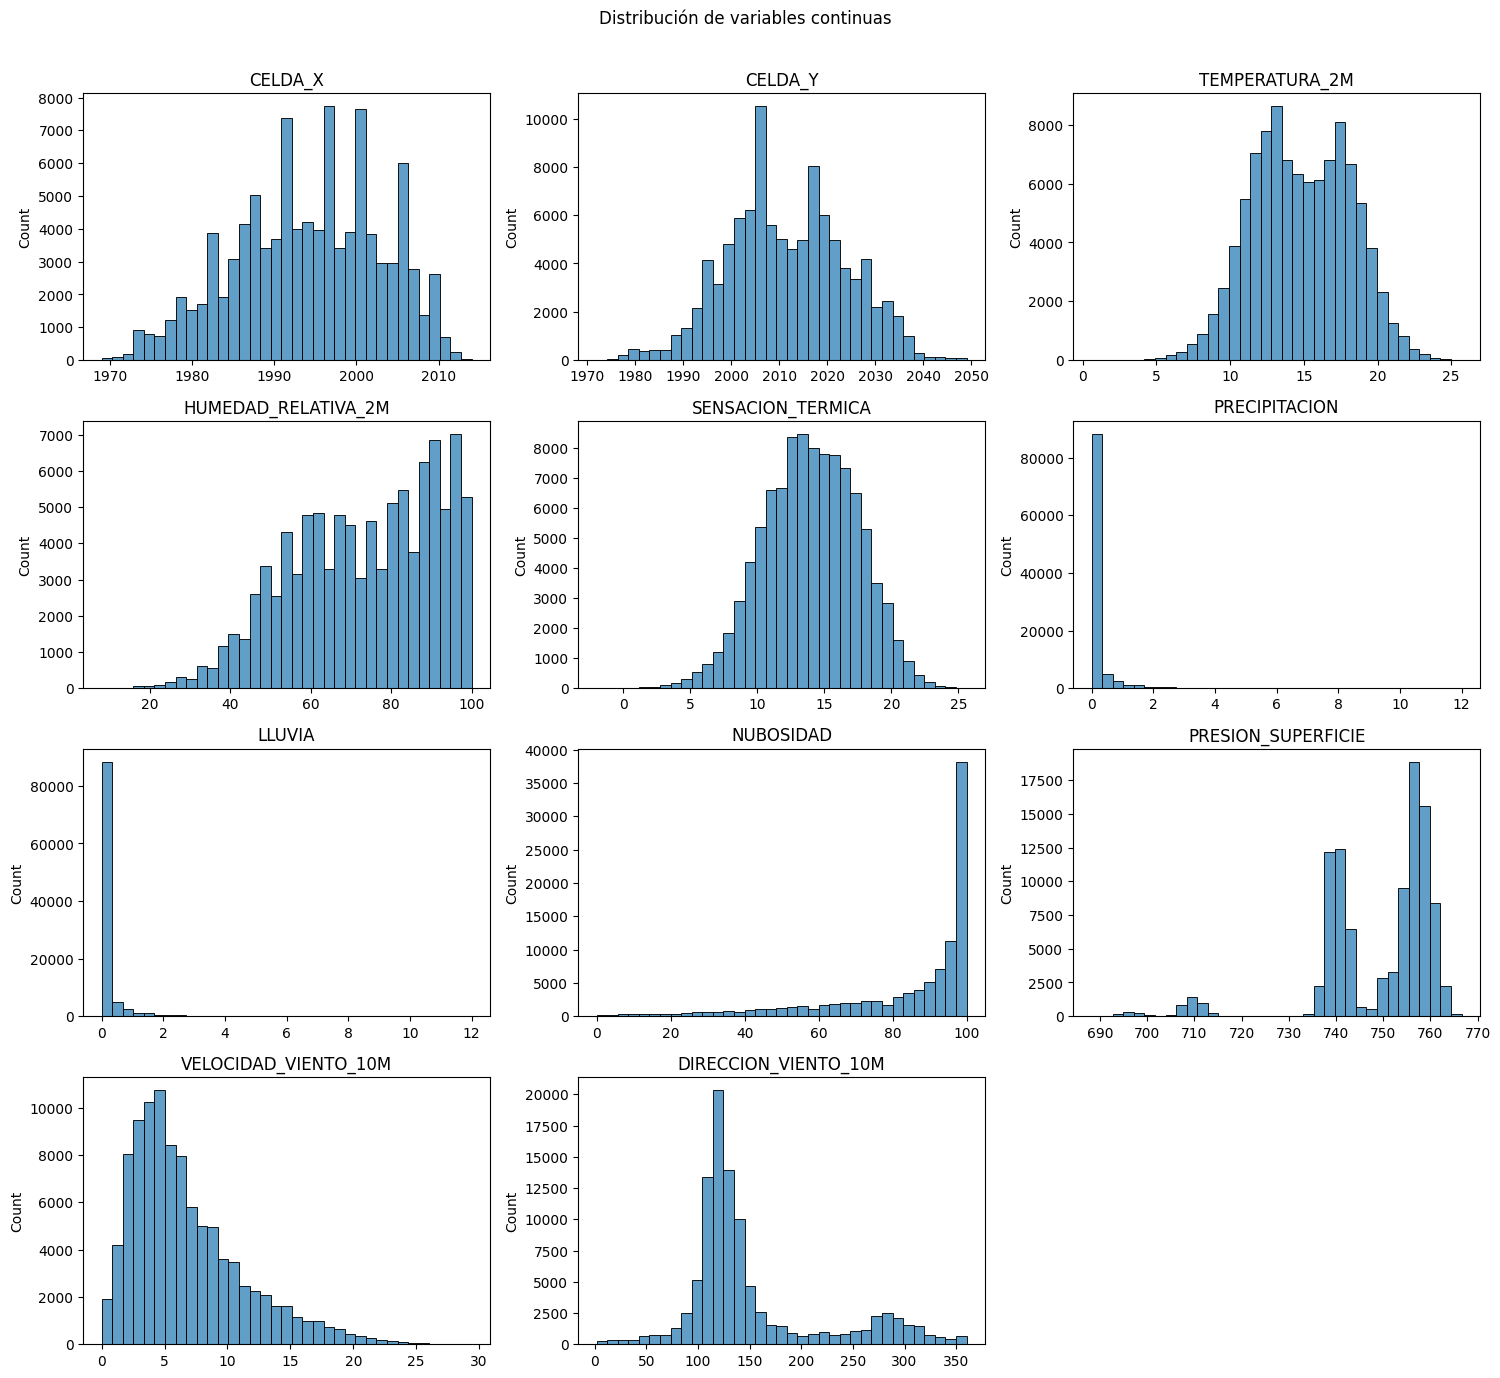

In [ ]:
# Gráficos de distribución de variables continuas
muestra_descriptiva = datos_modelo[variables_continuas].sample(
    n=min(100_000, len(datos_modelo)), random_state=SEMILLA
)

columnas_grafico = 3
filas_grafico = int(np.ceil(len(variables_continuas) / columnas_grafico))
fig, axes = plt.subplots(
    filas_grafico, columnas_grafico,
    figsize=(15, 3.4 * filas_grafico)
)
for ax, columna in zip(axes.flat, variables_continuas):
    sns.histplot(muestra_descriptiva[columna], bins=35, ax=ax, color='#2C7FB8')
    ax.set_title(columna)
    ax.set_xlabel('')
for ax in axes.flat[len(variables_continuas):]:
    ax.set_visible(False)
fig.suptitle('Distribución de variables continuas', y=1.01)
plt.tight_layout()
plt.show()

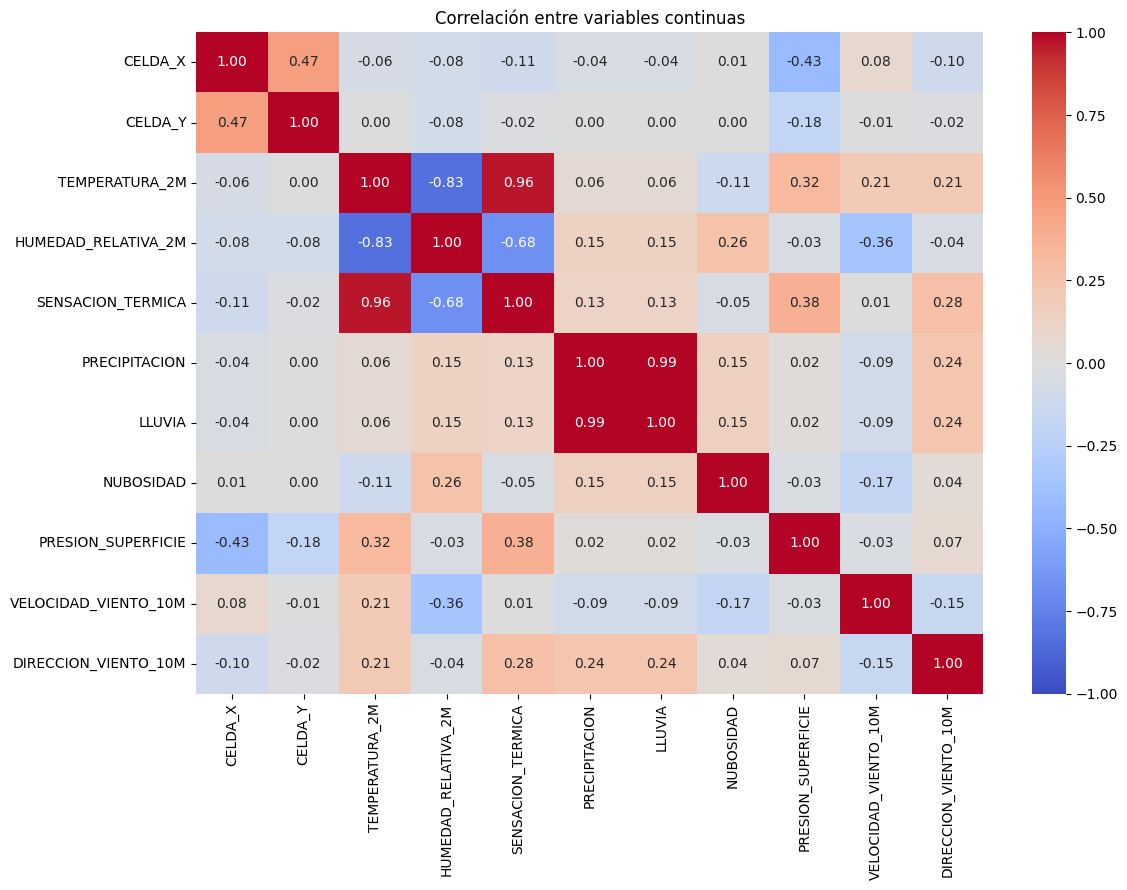

In [ ]:
# Correlación entre variables continuas
correlaciones = muestra_descriptiva.corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    correlaciones, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', ax=ax
)
ax.set_title('Correlación entre variables continuas')
plt.tight_layout()
plt.show()

#### Análisis de las distribuciones y correlaciones

Las variables meteorológicas presentan comportamientos similares a los observados en el modelo de estado. `PRECIPITACION` se concentra fuertemente en cero y presenta una cola hacia valores altos, mientras que `NUBOSIDAD` concentra gran parte de los registros en niveles elevados. `VELOCIDAD_VIENTO_10M` presenta asimetría positiva y `PRESION_SUPERFICIE` muestra varios grupos de valores, asociados a la variación espacial y temporal de las condiciones atmosféricas.

`N_CALZADAS` y `N_CARRILES` presentan pocos valores posibles y deben interpretarse como conteos discretos. Además, su análisis está condicionado por el porcentaje elevado de faltantes identificado previamente.

La matriz de correlación evidencia nuevamente una relación muy alta entre `TEMPERATURA_2M` y `SENSACION_TERMICA`, así como entre `PRECIPITACION` y `LLUVIA`. También se observa una relación negativa fuerte entre `TEMPERATURA_2M` y `HUMEDAD_RELATIVA_2M`. Por tanto, se mantiene el mismo criterio de reducción de redundancia utilizado anteriormente: conservar `TEMPERATURA_2M` y `PRECIPITACION`, y retirar `SENSACION_TERMICA`, `LLUVIA` y `HUMEDAD_RELATIVA_2M`.

Las demás variables no presentan relaciones lineales suficientemente altas como para justificar su eliminación únicamente por correlación.

### 2.2 Selección de variables meteorológicas por correlación

Para reducir redundancia se establece un umbral de correlación absoluta de 0,80. Cuando dos variables superan este valor se conserva la medición más directa e interpretable para una consulta de PrediRuta.

In [ ]:
# Selección de variables meteorológicas por correlación
UMBRAL_CORRELACION = 0.80

decisiones_correlacion = pd.DataFrame([
    {
        'VARIABLE_CONSERVADA': 'TEMPERATURA_2M',
        'VARIABLE_RETIRADA': 'SENSACION_TERMICA',
        'JUSTIFICACION': 'Se conserva la medición directa de temperatura.'
    },
    {
        'VARIABLE_CONSERVADA': 'PRECIPITACION',
        'VARIABLE_RETIRADA': 'LLUVIA',
        'JUSTIFICACION': 'Se conserva precipitación como medida meteorológica directa.'
    },
    {
        'VARIABLE_CONSERVADA': 'TEMPERATURA_2M',
        'VARIABLE_RETIRADA': 'HUMEDAD_RELATIVA_2M',
        'JUSTIFICACION': 'Se prioriza temperatura por su interpretación operativa directa.'
    }
])

decisiones_correlacion['CORRELACION'] = decisiones_correlacion.apply(
    lambda fila: correlaciones.loc[
        fila['VARIABLE_CONSERVADA'],
        fila['VARIABLE_RETIRADA']
    ],
    axis=1
)

decisiones_correlacion['CORRELACION_ABSOLUTA'] = (
    decisiones_correlacion['CORRELACION'].abs()
)

decisiones_correlacion['SUPERA_UMBRAL'] = (
    decisiones_correlacion['CORRELACION_ABSOLUTA'] >= UMBRAL_CORRELACION
)

# Validar que todas las decisiones cumplen el criterio definido
assert decisiones_correlacion['SUPERA_UMBRAL'].all(), (
    'Existe al menos una pareja que no supera el umbral de correlación.'
)

display(
    decisiones_correlacion[
        [
            'VARIABLE_CONSERVADA',
            'VARIABLE_RETIRADA',
            'CORRELACION',
            'CORRELACION_ABSOLUTA',
            'JUSTIFICACION'
        ]
    ].round(3)
)

,VARIABLE_CONSERVADA,VARIABLE_RETIRADA,CORRELACION,CORRELACION_ABSOLUTA,JUSTIFICACION
0,TEMPERATURA_2M,SENSACION_TERMICA,0.962,0.962,Se conserva la medición directa de temperatura.
1,PRECIPITACION,LLUVIA,0.995,0.995,Se conserva precipitación como medida meteorol...
2,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,-0.828,0.828,Se prioriza temperatura por su interpretación ...


Se retiran `SENSACION_TERMICA`, `LLUVIA` y `HUMEDAD_RELATIVA_2M` porque presentan correlaciones absolutas superiores a 0,80 con variables más directas que se conservan. Esta reducción evita representaciones meteorológicas redundantes y mantiene temperatura y precipitación como mediciones operativamente interpretables.

### 2.3 Composición de la clase por mes, día y hora

Como todos los registros representan accidentes ocurridos, estas gráficas describen cómo cambia la composición relativa de `CHOQUE`, `ATROPELLO` y `OTROS` según mes, día de la semana y hora; no representan la probabilidad de ocurrencia del accidente.

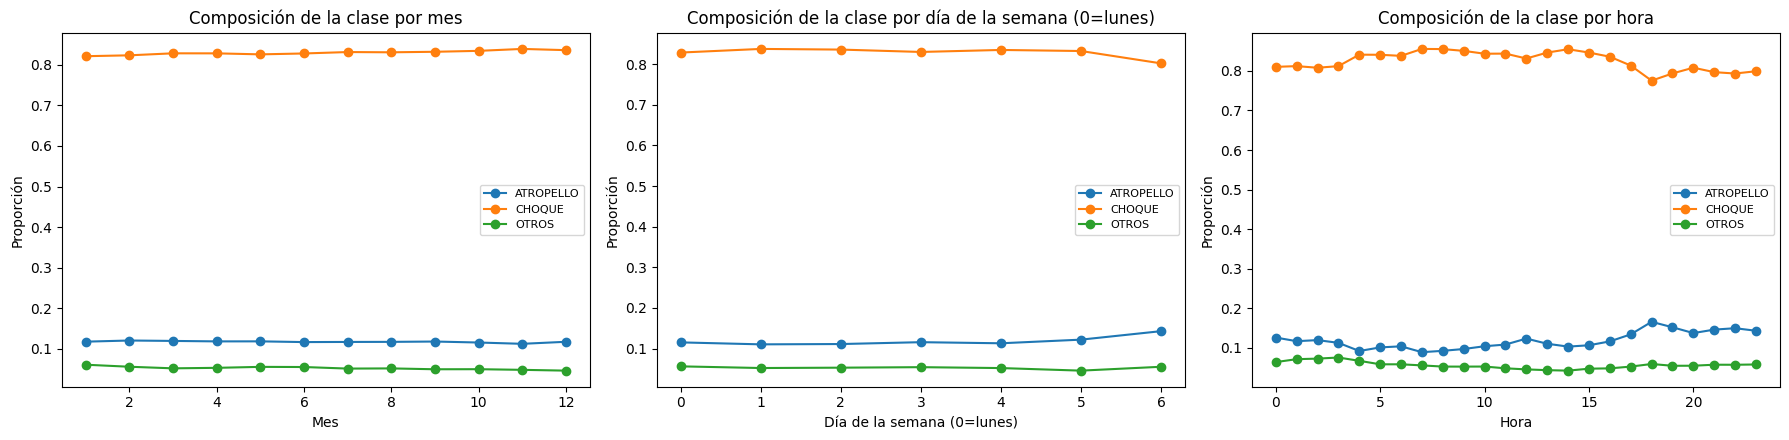

In [ ]:
# Gráficos de composición de la clase por mes, día de la semana y hora
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, columna, titulo in zip(
    axes, ['MES', 'DIA_SEMANA', 'HORA'],
    ['Mes', 'Día de la semana (0=lunes)', 'Hora']
):
    composicion = pd.crosstab(
        datos_modelo[columna],
        datos_modelo['CLASE_ACCIDENTE_AGRUPADA'],
        normalize='index'
    )
    composicion.plot(ax=ax, marker='o', linewidth=1.5)
    ax.set_title(f'Composición de la clase por {titulo.lower()}')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Proporción')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Estadísticas descriptivas de variables meteorológicas por clase
resumen_clima_clase = (
    datos_modelo
    .groupby('CLASE_ACCIDENTE_AGRUPADA')[[
        'TEMPERATURA_2M', 'PRECIPITACION',
        'NUBOSIDAD', 'VELOCIDAD_VIENTO_10M'
    ]]
    .agg(['mean', 'median'])
)
display(resumen_clima_clase)

TEMPERATURA_2M        PRECIPITACION         \
                                   mean median          mean median   
CLASE_ACCIDENTE_AGRUPADA                                              
ATROPELLO                     14.874623   14.7      0.179814    0.0   
CHOQUE                        14.851042   14.8      0.171833    0.0   
OTROS                         14.589233   14.4      0.162604    0.0   

                          NUBOSIDAD        VELOCIDAD_VIENTO_10M         
                               mean median                 mean median  
CLASE_ACCIDENTE_AGRUPADA                                                
ATROPELLO                 84.239292   95.0             6.347942    5.2  
CHOQUE                    83.745858   94.0             6.805019    5.6  
OTROS                     83.905841   95.0             6.444957    5.3

#### Análisis temporal y climático

La composición por mes presenta pocas variaciones, con predominio de `CHOQUE` durante todo el año y una participación de `ATROPELLO` cercana al 11 %–12 %. Por día de la semana se observa un comportamiento igualmente estable, aunque el domingo aumenta ligeramente la proporción de `ATROPELLO`.

La hora muestra una señal temporal más marcada. La participación de `ATROPELLO` es menor durante la madrugada y primeras horas de la mañana, mientras que aumenta durante la tarde y noche, especialmente entre aproximadamente las 17:00 y 23:00. `CHOQUE` conserva el mayor peso en todas las franjas, aunque su proporción disminuye en las horas donde aumenta `ATROPELLO`.

Las variables meteorológicas presentan diferencias reducidas entre las clases. Las medias y medianas de temperatura, precipitación, nubosidad y dirección del viento son similares para `ATROPELLO`, `CHOQUE` y `OTROS`. Se observan algunas diferencias en humedad, presión y velocidad del viento, pero su magnitud descriptiva es limitada.

En conjunto, las variables temporales, especialmente la hora, muestran una separación visual más clara entre las clases que las variables meteorológicas. El aporte del clima deberá comprobarse posteriormente mediante la comparación formal de los escenarios con y sin predictores meteorológicos.

### 2.4 Descriptiva de las 150 zonas

Las zonas no se recalibran con este objetivo. Se utilizan las mismas 150 zonas construidas para el modelo de ocurrencia, lo que mantiene una representación espacial coherente entre los componentes del proyecto.

In [ ]:
# Estadísticas descriptivas de accidentes por zona
resumen_zonas = (
    datos_modelo.groupby('ZONA_CIUDAD')
    .agg(ACCIDENTES=('ACCIDENTE_ID', 'size'))
    .reset_index()
    .merge(centroides_zona, on='ZONA_CIUDAD', how='left', validate='1:1')
)
composicion_zona = pd.crosstab(
    datos_modelo['ZONA_CIUDAD'],
    datos_modelo['CLASE_ACCIDENTE_AGRUPADA'],
    normalize='index'
)
assert len(resumen_zonas) == NUMERO_ZONAS
display(resumen_zonas[['ACCIDENTES']].describe().T)
display(resumen_zonas.nlargest(15, 'ACCIDENTES'))

,count,mean,std,min,25%,50%,75%,max
ACCIDENTES,150.0,5967.12,2280.78929,283.0,4476.5,5739.5,7189.0,11650.0


,ZONA_CIUDAD,ACCIDENTES,LATITUD_CENTROIDE,LONGITUD_CENTROIDE
51,51,11650,4.720632,-74.051823
76,76,11532,4.603915,-74.074688
29,29,11342,4.644874,-74.062205
70,70,10833,4.629379,-74.080767
12,12,10829,4.630131,-74.119967
116,116,10609,4.629776,-74.136337
40,40,10306,4.612003,-74.070541
41,41,10213,4.697094,-74.087579
102,102,10160,4.598093,-74.091137
5,5,10118,4.640591,-74.157047


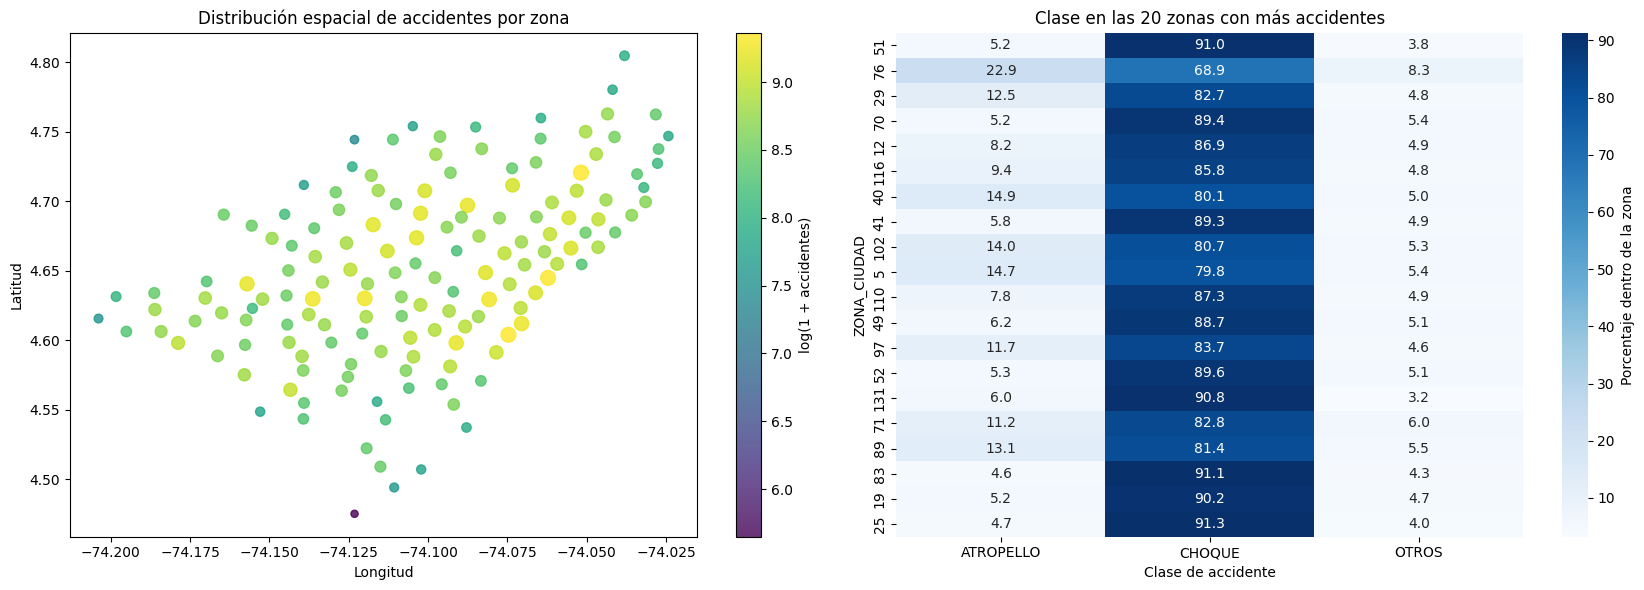

In [ ]:
# Gráficos de distribución espacial y composición de clase por zona
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
dispersion = axes[0].scatter(
    resumen_zonas['LONGITUD_CENTROIDE'],
    resumen_zonas['LATITUD_CENTROIDE'],
    c=np.log1p(resumen_zonas['ACCIDENTES']),
    s=25 + 90 * resumen_zonas['ACCIDENTES'] / resumen_zonas['ACCIDENTES'].max(),
    cmap='viridis', alpha=0.8
)
axes[0].set_title('Distribución espacial de accidentes por zona')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
fig.colorbar(dispersion, ax=axes[0], label='log(1 + accidentes)')

zonas_mayor_volumen = resumen_zonas.nlargest(20, 'ACCIDENTES')['ZONA_CIUDAD']
sns.heatmap(
    100 * composicion_zona.loc[zonas_mayor_volumen],
    cmap='Blues', annot=True, fmt='.1f', ax=axes[1],
    cbar_kws={'label': 'Porcentaje dentro de la zona'}
)
axes[1].set_title('Clase en las 20 zonas con más accidentes')
axes[1].set_xlabel('Clase de accidente')
axes[1].set_ylabel('ZONA_CIUDAD')
plt.tight_layout()
plt.show()

#### Análisis espacial

La distribución de accidentes no es homogénea entre las 150 zonas, ya que algunas concentran un número considerablemente mayor de eventos que otras. Esto confirma que la localización aporta una señal potencialmente relevante para el modelado.

En las 20 zonas con mayor número de accidentes, `CHOQUE` continúa siendo la clase dominante, generalmente con proporciones cercanas o superiores al 80 %. Sin embargo, la participación de `ATROPELLO` varía entre zonas y en algunos casos alcanza valores claramente superiores al promedio general, mientras que `OTROS` mantiene una participación menor.

Estas diferencias sugieren que la composición de la clase de accidente presenta una componente espacial. Por esta razón, `ZONA_CIUDAD` se mantiene como predictor en el escenario operativo, complementando la información de `CELDA_X` y `CELDA_Y`.

## 3. Definición de los conjuntos de variables

Se definen dos conjuntos de predictores con propósitos diferentes. El conjunto **completo** incorpora la caracterización vial enriquecida y se utiliza como referencia experimental. El conjunto **operativo** se restringe a ubicación, zona, fecha y hora, que pueden obtenerse directamente durante una consulta de ruta.

Ningún alcance utiliza atributos de actores o vehículos, consecuencias, gravedad, causas ni la clase original del accidente. Para los escenarios con clima también se excluyen `SENSACION_TERMICA`, `LLUVIA` y `HUMEDAD_RELATIVA_2M`, según el umbral de correlación absoluta de **0,80** definido previamente.

In [ ]:
# Crear variables cíclicas para representar correctamente
# la periodicidad temporal y la dirección del viento

def agregar_variables_ciclicas(df):
    salida = df.copy()

    ciclos = {
        'MES': 12,
        'DIA_SEMANA': 7,
        'HORA': 24,
        'DIRECCION_VIENTO_10M': 360
    }

    for columna, periodo in ciclos.items():
        angulo = 2 * np.pi * salida[columna].astype(float) / periodo

        salida[f'{columna}_SIN'] = np.sin(angulo)
        salida[f'{columna}_COS'] = np.cos(angulo)

    return salida


datos_modelo = agregar_variables_ciclicas(datos_modelo)

In [ ]:
# Variables disponibles en los escenarios operativos
NUMERICAS_COMUNES = [
    'CELDA_X', 'CELDA_Y',
    'MES_SIN', 'MES_COS',
    'DIA_SEMANA_SIN', 'DIA_SEMANA_COS',
    'HORA_SIN', 'HORA_COS'
]
CATEGORICAS_COMUNES = [
    'MES', 'DIA_SEMANA', 'HORA', 'ZONA_CIUDAD'
]
PREDICTORES_CLIMA = [
    'TEMPERATURA_2M', 'PRECIPITACION', 'NUBOSIDAD',
    'PRESION_SUPERFICIE', 'VELOCIDAD_VIENTO_10M',
    'DIRECCION_VIENTO_10M_SIN', 'DIRECCION_VIENTO_10M_COS'
]

In [ ]:
# Variables adicionales disponibles únicamente
# para el escenario completo experimental
NUMERICAS_COMPLETAS = [
    *NUMERICAS_COMUNES,
    *COLUMNAS_VIA_NUMERICAS
]
CATEGORICAS_COMPLETAS = [
    *CATEGORICAS_COMUNES,
    *COLUMNAS_VIA_CATEGORICAS
]

In [ ]:
# Escenarios experimentales

ESCENARIOS = {
    'COMPLETO_SIN_CLIMA': {
        'numericas': NUMERICAS_COMPLETAS,
        'categoricas': CATEGORICAS_COMPLETAS
    },

    'COMPLETO_CON_CLIMA': {
        'numericas': [
            *NUMERICAS_COMPLETAS,
            *PREDICTORES_CLIMA
        ],
        'categoricas': CATEGORICAS_COMPLETAS
    },

    'OPERATIVO_SIN_CLIMA': {
        'numericas': NUMERICAS_COMUNES,
        'categoricas': CATEGORICAS_COMUNES
    },

    'OPERATIVO_CON_CLIMA': {
        'numericas': [
            *NUMERICAS_COMUNES,
            *PREDICTORES_CLIMA
        ],
        'categoricas': CATEGORICAS_COMUNES
    }
}

In [ ]:
# Variables no permitidas en los escenarios operativos
VARIABLES_NO_DISPONIBLES = {
    *COLUMNAS_VIA_NUMERICAS,
    *COLUMNAS_VIA_CATEGORICAS
}
VARIABLES_POSTEVENTO_BLOQUEADAS = {
    'CLASE_ACCIDENTE',
    'CLASE_ACCIDENTE_DESC',
    'CLASE_ACCIDENTE_AGRUPADA',
    'ESTADO', 'OBJETIVO_GRAVE',
    'CANTIDAD_HERIDOS', 'CANTIDAD_MUERTOS',
    'CANTIDAD_CAUSAS', 'CAUSAS_DISTINTAS', 'TIPOS_CAUSA_DISTINTOS',
    'ACCIDENTE_ID', 'ACTOR_ID', 'VEHICULO_ID', 'CLIMA_ID'
}

for nombre, grupos in ESCENARIOS.items():
    variables = grupos['numericas'] + grupos['categoricas']
    assert len(variables) == len(set(variables)), (
        f'Hay variables duplicadas en {nombre}'
    )
    assert not (set(variables) & VARIABLES_POSTEVENTO_BLOQUEADAS), (
        f'{nombre} contiene variables postevento bloqueadas'
    )
    if nombre.startswith('OPERATIVO'):
        assert not (set(variables) & VARIABLES_NO_DISPONIBLES), (
            f'{nombre} contiene variables no disponibles operativamente'
        )

In [ ]:
# Resumen de los conjuntos de variables

resumen_escenarios = pd.DataFrame([
    {
        'ESCENARIO': nombre,
        'NUMERICAS': len(grupos['numericas']),
        'CATEGORICAS': len(grupos['categoricas']),
        'TOTAL_ENTRADAS': (
            len(grupos['numericas']) +
            len(grupos['categoricas'])
        )
    }
    for nombre, grupos in ESCENARIOS.items()
])

display(resumen_escenarios)

display(
    pd.DataFrame({
        'VARIABLE_RETIRADA_DEL_OPERATIVO':
            sorted(VARIABLES_NO_DISPONIBLES)
    })
)

,ESCENARIO,NUMERICAS,CATEGORICAS,TOTAL_ENTRADAS
0,COMPLETO_SIN_CLIMA,10,13,23
1,COMPLETO_CON_CLIMA,17,13,30
2,OPERATIVO_SIN_CLIMA,8,4,12
3,OPERATIVO_CON_CLIMA,15,4,19


,VARIABLE_RETIRADA_DEL_OPERATIVO
0,CONDICION_VIA
1,ESTADO_VIA
2,GEOMETRIA_PLANTA
3,GEOMETRIA_SECCION
4,GEOMETRIA_TERRENO
5,ILUMINACION_ARTIFICIAL
6,N_CALZADAS
7,N_CARRILES
8,SEMAFORO
9,SENTIDO_VIA


#### Análisis de los escenarios de variables

La definición genera cuatro escenarios comparables sobre los mismos accidentes. `COMPLETO_SIN_CLIMA` utiliza **23 entradas** y `COMPLETO_CON_CLIMA` utiliza **30**. Los escenarios operativos emplean **12 variables sin clima** y **19 con clima**. La diferencia de once variables corresponde a la caracterización vial enriquecida que se conserva como referencia experimental.

## 4. Partición temporal de entrenamiento, validación y prueba

La evaluación principal se realiza con cortes cronológicos para responder si un modelo ajustado con el pasado generaliza a periodos posteriores:

- **Entrenamiento:** 2007–2020.
- **Validación y selección:** 2021–2023.
- **Prueba final:** 2024–2026.

La variable `ANIO` se usa exclusivamente para formar estas particiones. No se incluye en `X`, evitando que el modelo memorice diferencias administrativas entre periodos.

In [ ]:
# Definición de los cortes temporales

ANIO_FIN_ENTRENAMIENTO = 2020
ANIO_FIN_VALIDACION = 2023
ANIO_FIN_PRUEBA = 2026

mascara_train = (
    datos_modelo['ANIO'] <= ANIO_FIN_ENTRENAMIENTO
)

mascara_val = datos_modelo['ANIO'].between(
    ANIO_FIN_ENTRENAMIENTO + 1,
    ANIO_FIN_VALIDACION
)

mascara_test = datos_modelo['ANIO'].between(
    ANIO_FIN_VALIDACION + 1,
    ANIO_FIN_PRUEBA
)

In [ ]:
# Codificación de la variable objetivo
encoder_objetivo = LabelEncoder()
encoder_objetivo.fit(CLASES_MODELO)
clases_codificadas = np.arange(len(encoder_objetivo.classes_))

def construir_xy(mascara, escenario):
    columnas = (
        ESCENARIOS[escenario]['numericas']
        + ESCENARIOS[escenario]['categoricas']
    )
    X = datos_modelo.loc[mascara, columnas].reset_index(drop=True)
    y_original = datos_modelo.loc[
        mascara, 'CLASE_ACCIDENTE_AGRUPADA'
    ].to_numpy()
    y = encoder_objetivo.transform(y_original)
    return X, y

X_train_referencia, y_train = construir_xy(
    mascara_train, 'COMPLETO_CON_CLIMA'
)
X_val_referencia, y_val = construir_xy(
    mascara_val, 'COMPLETO_CON_CLIMA'
)
X_test_referencia, y_test = construir_xy(
    mascara_test, 'COMPLETO_CON_CLIMA'
)

In [ ]:
# Validar que las particiones no se superponen

assert not (mascara_train & mascara_val).any()
assert not (mascara_train & mascara_test).any()
assert not (mascara_val & mascara_test).any()


# Validar que un accidente no aparezca en más de una partición

accidentes_train = set(
    datos_modelo.loc[mascara_train, 'ACCIDENTE_ID']
)

accidentes_val = set(
    datos_modelo.loc[mascara_val, 'ACCIDENTE_ID']
)

accidentes_test = set(
    datos_modelo.loc[mascara_test, 'ACCIDENTE_ID']
)

assert accidentes_train.isdisjoint(accidentes_val)
assert accidentes_train.isdisjoint(accidentes_test)
assert accidentes_val.isdisjoint(accidentes_test)


# Validar presencia de las tres clases en cada partición

assert set(np.unique(y_train)) == set(clases_codificadas)
assert set(np.unique(y_val)) == set(clases_codificadas)
assert set(np.unique(y_test)) == set(clases_codificadas)

In [ ]:
# Resumen de las particiones temporales

resumen_particiones = []

for nombre, mascara, y_particion in [
    ('ENTRENAMIENTO', mascara_train, y_train),
    ('VALIDACION', mascara_val, y_val),
    ('PRUEBA', mascara_test, y_test)
]:

    resumen_particiones.append({
        'PARTICION': nombre,
        'FILAS': int(mascara.sum()),
        'ACCIDENTES': datos_modelo.loc[
            mascara, 'ACCIDENTE_ID'
        ].nunique(),
        'FECHA_MINIMA': datos_modelo.loc[
            mascara, 'FECHA_HORA'
        ].min(),
        'FECHA_MAXIMA': datos_modelo.loc[
            mascara, 'FECHA_HORA'
        ].max(),
        'CLASES_PRESENTES': len(
            np.unique(y_particion)
        )
    })

resumen_particiones = pd.DataFrame(
    resumen_particiones
)

display(resumen_particiones)

,PARTICION,FILAS,ACCIDENTES,FECHA_MINIMA,FECHA_MAXIMA,CLASES_PRESENTES
0,ENTRENAMIENTO,795386,795386,2007-01-01 00:00:00,2020-12-31 22:34:00,3
1,VALIDACION,67444,67444,2021-01-01 00:30:00,2023-12-31 23:30:00,3
2,PRUEBA,32238,32238,2024-01-01 00:27:00,2026-08-13 00:50:00,3


In [ ]:
# Distribución porcentual de las clases por partición
distribucion_particiones = pd.DataFrame({
    'ENTRENAMIENTO': pd.Series(y_train).value_counts(normalize=True),
    'VALIDACION': pd.Series(y_val).value_counts(normalize=True),
    'PRUEBA': pd.Series(y_test).value_counts(normalize=True)
}).fillna(0)
distribucion_particiones.index = encoder_objetivo.inverse_transform(
    distribucion_particiones.index.to_numpy()
)
display((100 * distribucion_particiones).round(3))

,ENTRENAMIENTO,VALIDACION,PRUEBA
CHOQUE,83.530,82.667,70.429
ATROPELLO,11.401,11.580,20.823
OTROS,5.069,5.753,8.747


#### Análisis de la partición temporal

Las tres clases se encuentran presentes en entrenamiento, validación y prueba, por lo que no existe pérdida de categorías entre los periodos. Sin embargo, la distribución del objetivo presenta un cambio temporal importante.

Entrenamiento y validación conservan composiciones similares: `CHOQUE` representa alrededor del **83 %**, `ATROPELLO` cerca del **11 %–12 %** y `OTROS` aproximadamente el **5 %–6 %**. En el periodo de prueba 2024–2026 esta estructura cambia de forma marcada: `CHOQUE` disminuye hasta **70,43 %**, mientras que `ATROPELLO` aumenta a **20,82 %** y `OTROS` a **8,75 %**.

Por tanto, la prueba temporal no solo evalúa observaciones futuras, sino que exige al modelo generalizar ante un cambio relevante en la prevalencia de las clases. Esta diferencia hace que la evaluación 2024–2026 sea más exigente y deberá considerarse al interpretar las métricas finales, especialmente `F1_macro` y `Balanced_Accuracy`.

## 5. Preprocesamiento y métricas

Las variables numéricas se imputan y estandarizan, mientras que las categóricas se imputan y codifican mediante *one-hot encoding*. Todo el preprocesamiento queda dentro de cada `Pipeline` y se ajusta solamente con entrenamiento.

Debido al predominio de `CHOQUE`, la selección se basa primero en **F1 macro**, después en **balanced accuracy** y finalmente en **log loss** como desempate. `Accuracy` y F1 ponderado se reportan, pero no dirigen la elección.

In [ ]:
# Funciones auxiliares para preprocesamiento y evaluación de modelos

def crear_preprocesador(escenario): # Función para crear un preprocesador de datos basado en el escenario seleccionado
    grupos = ESCENARIOS[escenario]
    pipeline_numerico = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalador', StandardScaler()),
    ])
    pipeline_categorico = Pipeline([
        ('imputador', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ])
    return ColumnTransformer([
        ('numericas', pipeline_numerico, grupos['numericas']),
        ('categoricas', pipeline_categorico, grupos['categoricas']),
    ], remainder='drop')

def ordenar_probabilidades(modelo, X, clases_esperadas): # Función para ordenar las probabilidades predichas por el modelo según las clases esperadas
    probabilidades = modelo.predict_proba(X)
    clases_modelo = np.asarray(modelo.classes_)
    salida = np.zeros((len(X), len(clases_esperadas)), dtype=float)
    for posicion, clase in enumerate(clases_esperadas):
        coincidencia = np.where(clases_modelo == clase)[0]
        if len(coincidencia):
            salida[:, posicion] = probabilidades[:, coincidencia[0]]
    suma = salida.sum(axis=1, keepdims=True)
    return np.divide(salida, suma, out=np.zeros_like(salida), where=suma > 0)

def error_calibracion_esperado(y_real, probabilidades, n_bins=10): # Función para calcular el error de calibración esperado (ECE) de un modelo de clasificación
    confianza = probabilidades.max(axis=1)
    prediccion = probabilidades.argmax(axis=1)
    acierto = (prediccion == y_real).astype(float)
    limites = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for inferior, superior in zip(limites[:-1], limites[1:]):
        mascara = (confianza > inferior) & (confianza <= superior)
        if mascara.any():
            ece += mascara.mean() * abs(acierto[mascara].mean() - confianza[mascara].mean())
    return ece

def calcular_metricas(y_real, probabilidades, clases=clases_codificadas): # Función para calcular métricas de evaluación de un modelo de clasificación
    prediccion = clases[np.argmax(probabilidades, axis=1)]
    y_binaria = LabelBinarizer().fit(clases).transform(y_real)
    onehot_real = np.eye(len(clases))[y_real]
    metricas = {
        'Accuracy': accuracy_score(y_real, prediccion),
        'Balanced_Accuracy': balanced_accuracy_score(y_real, prediccion),
        'F1_macro': f1_score(y_real, prediccion, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_real, prediccion, average='weighted', zero_division=0),
        'PR_AUC_macro': average_precision_score(y_binaria, probabilidades, average='macro'),
        'ROC_AUC_OVR_macro': roc_auc_score(y_real, probabilidades, labels=clases, multi_class='ovr', average='macro'),
        'Log_Loss': log_loss(y_real, probabilidades, labels=clases),
        'Brier_multiclase': np.mean(np.sum((probabilidades - onehot_real) ** 2, axis=1)),
        'ECE_10_bins': error_calibracion_esperado(y_real, probabilidades, n_bins=10),
    }
    return metricas

def pesos_clase_suaves(y, potencia=0.50): # Función para calcular pesos de clase suaves para abordar el desbalance de clases en un conjunto de datos
    clases, conteos = np.unique(y, return_counts=True)
    maximo = conteos.max()
    return {
        int(clase): float(min((maximo / conteo) ** potencia, 25.0))
        for clase, conteo in zip(clases, conteos)
    }

In [ ]:
# Muestra común de ajuste: mismas filas para todos los escenarios
TAMANO_MUESTRA_AJUSTE = 300_000

def indices_muestra_ajuste(y, tamano=TAMANO_MUESTRA_AJUSTE, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    cantidad = min(len(y), tamano)
    return np.sort(rng.choice(len(y), size=cantidad, replace=False))

def balancear_para_mlp(X, y, cantidad_por_clase=25_000, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    seleccionados = []
    for clase in np.unique(y):
        indices = np.flatnonzero(y == clase)
        seleccionados.append(rng.choice(
            indices, size=cantidad_por_clase,
            replace=len(indices) < cantidad_por_clase
        ))
    seleccionados = rng.permutation(np.concatenate(seleccionados))
    return X.iloc[seleccionados].reset_index(drop=True), y[seleccionados]

indices_ajuste = indices_muestra_ajuste(y_train)
y_ajuste = y_train[indices_ajuste]
distribucion_muestra = pd.DataFrame({
    'ENTRENAMIENTO_COMPLETO': pd.Series(y_train).value_counts(normalize=True),
    'MUESTRA_AJUSTE': pd.Series(y_ajuste).value_counts(normalize=True)
}).sort_index()
distribucion_muestra.index = encoder_objetivo.inverse_transform(
    distribucion_muestra.index.to_numpy()
)
display((100 * distribucion_muestra).round(3))

,ENTRENAMIENTO_COMPLETO,MUESTRA_AJUSTE
ATROPELLO,11.401,11.392
CHOQUE,83.530,83.556
OTROS,5.069,5.052


#### Representatividad de la muestra de ajuste

La muestra utilizada para la búsqueda de hiperparámetros conserva prácticamente la misma distribución de clases del conjunto completo de entrenamiento. `ATROPELLO` representa **11,39 %** de la muestra frente a **11,40 %** en el entrenamiento completo; `CHOQUE`, **83,56 %** frente a **83,53 %**; y `OTROS`, **5,05 %** frente a **5,07 %**.

Las diferencias son mínimas, por lo que la reducción del conjunto de entrenamiento no altera de manera relevante el desbalance original de la variable objetivo. Esto permite comparar las distintas configuraciones sobre una muestra común y representativa, reduciendo el costo computacional sin modificar sustancialmente la composición de las clases.

## 6. Línea base

La línea base utiliza únicamente la prevalencia histórica de las tres clases. Un modelo candidato debe superarla en F1 macro y *balanced accuracy*, pero también debe demostrar que reconoce `ATROPELLO` y `OTROS` en lugar de limitarse a predecir `CHOQUE`.

In [ ]:
# Línea base basada en la prevalencia histórica de las clases

baseline = DummyClassifier(
    strategy='prior',
    random_state=SEMILLA
)

# DummyClassifier requiere una matriz X, aunque no utiliza sus valores
X_dummy_train = np.zeros((len(y_train), 1))
X_dummy_val = np.zeros((len(y_val), 1))

baseline.fit(X_dummy_train, y_train)

# Obtener probabilidades y mantener el mismo orden de clases
proba_baseline_val = ordenar_probabilidades(
    baseline,
    X_dummy_val,
    clases_codificadas
)

# Evaluar la línea base sobre el conjunto de validación
metricas_baseline = calcular_metricas(
    y_val,
    proba_baseline_val
)

resultado_baseline = pd.DataFrame([{
    'MODELO': 'BASELINE_PRIOR',
    **metricas_baseline
}])

display(resultado_baseline)

,MODELO,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,BASELINE_PRIOR,0.826671,0.333333,0.301704,0.74823,0.333333,0.5,0.571781,0.30002,0.00863


#### Análisis de la línea base

La línea base alcanza una `Accuracy` de **0,8267**, valor elevado debido al fuerte predominio de `CHOQUE`. Sin embargo, la `Balanced_Accuracy` permanece en **0,3333** y el `F1_macro` en **0,3017**, lo que muestra que este resultado no representa una capacidad real para distinguir equilibradamente las tres clases.

El `ROC_AUC_OVR_macro` de **0,5000** confirma que la línea base no posee capacidad discriminante, mientras que el `PR_AUC_macro` de **0,3333** corresponde al nivel de referencia esperado para un problema de tres clases.

Por tanto, la `Accuracy` no debe utilizarse como criterio principal de selección. Los modelos candidatos deberán superar especialmente el `F1_macro` y la `Balanced_Accuracy` de esta línea base, demostrando capacidad para identificar también `ATROPELLO` y `OTROS`.

## 7. Evaluación de modelos

In [ ]:
# Preparar los cuatro escenarios sobre exactamente las mismas filas
datos_escenario = {}

for escenario in ESCENARIOS:
    X_train_esc, _ = construir_xy(mascara_train, escenario)
    X_val_esc, _ = construir_xy(mascara_val, escenario)

    datos_escenario[escenario] = {
        'ajuste': X_train_esc.iloc[indices_ajuste].reset_index(drop=True),
        'validacion': X_val_esc
    }

# Contenedores comunes para consolidar todas las familias en la sección 8
resultados_ajuste_acumulados = []
resultados_validacion = [{
    'MODELO': 'BASELINE_PRIOR',
    'ALCANCE': 'BASELINE',
    'CLIMA': 'SIN_PREDICTORES',
    'ESCENARIO': 'SIN_PREDICTORES',
    'SEGUNDOS_AJUSTE': 0.0,
    **metricas_baseline
}]
mejores_parametros = {}
modelos_validacion = {}
probabilidades_validacion = {}

In [ ]:
# Funciones comunes: construcción, ajuste y gráfico de las configuraciones

def crear_modelo(nombre, escenario, parametros, y_referencia): # Función para crear un modelo de clasificación basado en el nombre del modelo, escenario y parámetros proporcionados
    preprocesador = crear_preprocesador(escenario)
    parametros_modelo = parametros.copy()
    potencia_peso = parametros_modelo.pop('potencia_peso', 0.50)
    pesos = pesos_clase_suaves(y_referencia, potencia=potencia_peso)

    if nombre == 'REGRESION_LOGISTICA': # Función para crear un modelo de regresión logística con regularización y pesos de clase
        estimador = LogisticRegression(
            C=parametros_modelo['C'],
            class_weight=pesos,
            solver='lbfgs',
            max_iter=500,
            random_state=SEMILLA,
            n_jobs=-1
        )
    elif nombre == 'RANDOM_FOREST': # Función para crear un modelo de Random Forest con pesos de clase y muestreo aleatorio
        estimador = RandomForestClassifier(
            **parametros_modelo,
            class_weight=pesos,
            max_samples=0.75,
            random_state=SEMILLA,
            n_jobs=-1
        )
    elif nombre == 'XGBOOST': # Función para crear un modelo de XGBoost con pesos de clase y parámetros específicos para clasificación multiclase
        estimador = XGBClassifier(
            **parametros_modelo,
            objective='multi:softprob',
            eval_metric='mlogloss',
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            tree_method='hist',
            random_state=SEMILLA,
            n_jobs=-1
        )
    elif nombre == 'MLP': # Función para crear un modelo de Perceptrón Multicapa (MLP) con pesos de clase y parámetros específicos para clasificación multiclase
        estimador = MLPClassifier(
            **parametros_modelo,
            activation='relu',
            solver='adam',
            batch_size=1024,
            max_iter=60,
            early_stopping=True,
            validation_fraction=0.12,
            n_iter_no_change=5,
            tol=0.001,
            random_state=SEMILLA
        )
    else:
        raise ValueError(f'Modelo no reconocido: {nombre}')

    return Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', estimador)
    ])


def ajustar_modelo(nombre, escenario, parametros, X, y): # Función para ajustar un modelo de clasificación basado en el nombre del modelo, escenario y parámetros proporcionados
    X_entrenar = X
    y_entrenar = y

    if nombre == 'MLP':
        X_entrenar, y_entrenar = balancear_para_mlp(X, y)

    modelo = crear_modelo(
        nombre,
        escenario,
        parametros,
        y_entrenar
    )

    inicio = perf_counter()

    if nombre == 'XGBOOST':
        pesos = pesos_clase_suaves(
            y_entrenar,
            potencia=parametros.get('potencia_peso', 0.50)
        )
        pesos_observacion = np.array([
            pesos[int(clase)] for clase in y_entrenar
        ])
        modelo.fit(
            X_entrenar,
            y_entrenar,
            modelo__sample_weight=pesos_observacion
        )
    else:
        modelo.fit(X_entrenar, y_entrenar)

    return modelo, perf_counter() - inicio



def formatear_valor_parametro(valor): # Función para formatear el valor de un parámetro para su visualización en gráficos y tablas
    if isinstance(valor, list):
        return ' × '.join(str(elemento) for elemento in valor)
    if isinstance(valor, float):
        return f'{valor:g}'
    return str(valor)


def graficar_configuraciones(tabla, titulo): # Función para graficar el desempeño de las configuraciones
    """Muestra desempeño por configuración y sensibilidad descriptiva por parámetro."""
    ordenada = tabla.sort_values(['ALCANCE', 'CONFIGURACION']).copy()
    alcances = ['COMPLETO', 'OPERATIVO']
    metricas_principales = ['F1_macro', 'Balanced_Accuracy']

    # Gráfica 1: comparar las métricas principales de cada configuración
    metricas_largas = ordenada.melt(
        id_vars=['ALCANCE', 'CONFIGURACION'],
        value_vars=metricas_principales,
        var_name='METRICA',
        value_name='VALOR'
    )
    minimo_metricas = min(
        metricas_largas['VALOR'].min(),
        metricas_baseline['F1_macro']
    )
    maximo_metricas = metricas_largas['VALOR'].max()
    margen_metricas = max(0.02, 0.12 * (maximo_metricas - minimo_metricas))
    limites_metricas = (
        max(0, minimo_metricas - margen_metricas),
        min(1, maximo_metricas + margen_metricas)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, alcance in zip(axes, alcances):
        datos_alcance = metricas_largas.query('ALCANCE == @alcance')
        sns.lineplot(
            data=datos_alcance,
            x='CONFIGURACION',
            y='VALOR',
            hue='METRICA',
            style='METRICA',
            markers=True,
            dashes=False,
            estimator=None,
            ax=ax
        )

        mejor = (
            ordenada.query('ALCANCE == @alcance')
            .sort_values(
                ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
                ascending=[False, False, True]
            )
            .iloc[0]
        )
        ax.scatter(
            mejor['CONFIGURACION'],
            mejor['F1_macro'],
            marker='*',
            s=230,
            color='black',
            zorder=5,
            label='Mejor configuración'
        )
        ax.axhline(
            metricas_baseline['F1_macro'],
            color='gray',
            linestyle='--',
            label='F1 macro de línea base'
        )
        ax.set_xticks(sorted(datos_alcance['CONFIGURACION'].unique()))
        ax.set_xlabel('Número de configuración')
        ax.set_ylabel('Valor en validación')
        ax.set_title(f'{alcance.title()}')
        ax.set_ylim(*limites_metricas)
        ax.grid(axis='y', alpha=0.25)

    axes[1].legend().remove()
    axes[0].legend(title='Métrica / referencia', loc='best')
    fig.suptitle(f'{titulo}: métricas por configuración', y=1.03)
    plt.tight_layout()
    plt.show()

    # Preparar una fila por configuración y parámetro
    registros_parametros = []
    for _, fila in ordenada.iterrows():
        parametros = json.loads(fila['PARAMETROS'])
        for parametro, valor in parametros.items():
            registros_parametros.append({
                'ALCANCE': fila['ALCANCE'],
                'CONFIGURACION': fila['CONFIGURACION'],
                'PARAMETRO': parametro,
                'VALOR_PARAMETRO': formatear_valor_parametro(valor),
                'F1_macro': fila['F1_macro']
            })

    sensibilidad = pd.DataFrame(registros_parametros)
    minimo_sensibilidad = sensibilidad['F1_macro'].min()
    maximo_sensibilidad = sensibilidad['F1_macro'].max()
    margen_sensibilidad = max(
        0.01,
        0.15 * (maximo_sensibilidad - minimo_sensibilidad)
    )
    limites_sensibilidad = (
        max(0, minimo_sensibilidad - margen_sensibilidad),
        min(1, maximo_sensibilidad + margen_sensibilidad)
    )
    parametros = sensibilidad['PARAMETRO'].drop_duplicates().tolist()
    columnas = min(3, len(parametros))
    filas = int(np.ceil(len(parametros) / columnas))
    fig, axes = plt.subplots(
        filas,
        columnas,
        figsize=(5.2 * columnas, 4.2 * filas),
        sharey=True,
        squeeze=False
    )
    colores = dict(zip(alcances, sns.color_palette('colorblind', len(alcances))))

    for ax, parametro in zip(axes.flat, parametros):
        datos_parametro = sensibilidad.query('PARAMETRO == @parametro').copy()
        valores = datos_parametro['VALOR_PARAMETRO'].drop_duplicates().tolist()
        posiciones = {valor: posicion for posicion, valor in enumerate(valores)}

        for indice_alcance, alcance in enumerate(alcances):
            datos_alcance = datos_parametro.query('ALCANCE == @alcance')
            promedios = (
                datos_alcance
                .groupby('VALOR_PARAMETRO', sort=False)['F1_macro']
                .mean()
                .reindex(valores)
            )
            desplazamiento = -0.08 if indice_alcance == 0 else 0.08
            x_promedios = np.array([
                posiciones[valor] + desplazamiento for valor in valores
            ])

            ax.plot(
                x_promedios,
                promedios.to_numpy(),
                marker='D',
                linewidth=1.5,
                color=colores[alcance],
                label=f'{alcance.title()} (promedio)'
            )

            for valor in valores:
                observaciones = datos_alcance.loc[
                    datos_alcance['VALOR_PARAMETRO'].eq(valor),
                    'F1_macro'
                ].to_numpy()
                if len(observaciones) == 0:
                    continue
                jitter = np.linspace(-0.035, 0.035, len(observaciones))
                ax.scatter(
                    posiciones[valor] + desplazamiento + jitter,
                    observaciones,
                    s=35,
                    alpha=0.55,
                    color=colores[alcance]
                )

        ax.set_xticks(range(len(valores)))
        ax.set_xticklabels(valores, rotation=25, ha='right')
        ax.set_xlabel('Valor evaluado')
        ax.set_ylabel('F1 macro en validación')
        ax.set_title(parametro.replace('_', ' ').title())
        ax.set_ylim(*limites_sensibilidad)
        ax.grid(axis='y', alpha=0.25)

    for ax in axes.flat[len(parametros):]:
        ax.set_visible(False)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.01),
        ncol=len(alcances)
    )
    fig.suptitle(
        f'{titulo}: sensibilidad descriptiva del F1 macro por hiperparámetro',
        y=1.06
    )
    plt.tight_layout()
    plt.show()

### 7.1 Regresión logística

Se evalúan diferentes niveles de regularización y ponderación de clases mediante un proceso secuencial de ajuste de hiperparámetros:

1. definir las configuraciones candidatas;
2. evaluarlas en `COMPLETO_CON_CLIMA` y seleccionar la mejor con base en `F1_macro`, `Balanced_Accuracy` y, como criterio de desempate, `Log_Loss`;
3. reutilizar la configuración seleccionada en `COMPLETO_SIN_CLIMA`;
4. repetir el mismo procedimiento para los escenarios operativos;
5. comparar el `F1_macro` de las configuraciones evaluadas y registrar los mejores resultados para la selección final entre modelos.

El ajuste de hiperparámetros se realiza únicamente en los escenarios con clima. La configuración ganadora se conserva sin modificaciones al evaluar el escenario equivalente sin clima, de modo que la comparación permita aislar el aporte de las variables meteorológicas sin introducir diferencias adicionales asociadas a los hiperparámetros.

In [ ]:
# Configuraciones de hiperparámetros para la regresión logística con regularización L2 y pesos de clase suaves
CONFIG_LOGISTICA = [
    {'C': 0.05, 'potencia_peso': 0.25},
    {'C': 0.25, 'potencia_peso': 0.50},
    {'C': 0.25, 'potencia_peso': 0.75},
    {'C': 0.25, 'potencia_peso': 0.90},
    {'C': 0.25, 'potencia_peso': 1.00},
    {'C': 0.25, 'potencia_peso': 0.90},
    {'C': 0.25, 'potencia_peso': 1.00},
    {'C': 0.10, 'potencia_peso': 0.75},
    {'C': 0.50, 'potencia_peso': 0.75},
    {'C': 1.00, 'potencia_peso': 0.75},
]

In [ ]:
# Escenario de ajuste y validación para regresión logística
escenario = 'COMPLETO_CON_CLIMA'

filas_logistica_completo = []
modelos_logistica_completo = {}
probas_logistica_completo = {}

for numero, parametros in enumerate(CONFIG_LOGISTICA, start=1):
    print(f'Configuración {numero}/{len(CONFIG_LOGISTICA)}: {parametros}')

    parametros_modelo = parametros.copy()
    potencia_peso = parametros_modelo.pop('potencia_peso')
    pesos = pesos_clase_suaves(y_ajuste, potencia=potencia_peso)

    modelo = Pipeline([
        ('preprocesador', crear_preprocesador(escenario)),
        ('modelo', LogisticRegression(
            C=parametros_modelo['C'],
            class_weight=pesos,
            solver='lbfgs',
            max_iter=500,
            random_state=SEMILLA,
            n_jobs=-1
        ))
    ])

    inicio = perf_counter()
    modelo.fit(datos_escenario[escenario]['ajuste'], y_ajuste)
    segundos = perf_counter() - inicio

    probabilidades = ordenar_probabilidades(
        modelo,
        datos_escenario[escenario]['validacion'],
        clases_codificadas
    )

    filas_logistica_completo.append({
        'MODELO': 'REGRESION_LOGISTICA',
        'ALCANCE': 'COMPLETO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_logistica_completo[numero] = modelo
    probas_logistica_completo[numero] = probabilidades

tabla_logistica_completo = pd.DataFrame(filas_logistica_completo)
display(tabla_logistica_completo.round(4))

Configuración 1/10: {'C': 0.05, 'potencia_peso': 0.25}
Configuración 2/10: {'C': 0.25, 'potencia_peso': 0.5}
Configuración 3/10: {'C': 0.25, 'potencia_peso': 0.75}
Configuración 4/10: {'C': 0.25, 'potencia_peso': 0.9}
Configuración 5/10: {'C': 0.25, 'potencia_peso': 1.0}
Configuración 6/10: {'C': 0.25, 'potencia_peso': 0.9}
Configuración 7/10: {'C': 0.25, 'potencia_peso': 1.0}
Configuración 8/10: {'C': 0.1, 'potencia_peso': 0.75}
Configuración 9/10: {'C': 0.5, 'potencia_peso': 0.75}
Configuración 10/10: {'C': 1.0, 'potencia_peso': 0.75}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,COMPLETO,1,"{""C"": 0.05, ""potencia_peso"": 0.25}",10.8290,0.8227,0.3427,0.3239,0.7540,0.3870,0.6223,0.5769,0.3083,0.0786
1,REGRESION_LOGISTICA,COMPLETO,2,"{""C"": 0.25, ""potencia_peso"": 0.5}",13.6416,0.7883,0.3734,0.3740,0.7548,0.3872,0.6217,0.6576,0.3618,0.1468
2,REGRESION_LOGISTICA,COMPLETO,3,"{""C"": 0.25, ""potencia_peso"": 0.75}",14.9265,0.6845,0.4112,0.3914,0.7065,0.3867,0.6204,0.8147,0.4693,0.1435
3,REGRESION_LOGISTICA,COMPLETO,4,"{""C"": 0.25, ""potencia_peso"": 0.9}",14.3315,0.5823,0.4287,0.3734,0.6390,0.3862,0.6190,0.9492,0.5599,0.0879
4,REGRESION_LOGISTICA,COMPLETO,5,"{""C"": 0.25, ""potencia_peso"": 1.0}",15.0094,0.4866,0.4312,0.3417,0.5618,0.3855,0.6174,1.0569,0.6302,0.0170
5,REGRESION_LOGISTICA,COMPLETO,6,"{""C"": 0.25, ""potencia_peso"": 0.9}",14.3304,0.5823,0.4287,0.3734,0.6390,0.3862,0.6190,0.9492,0.5599,0.0879
6,REGRESION_LOGISTICA,COMPLETO,7,"{""C"": 0.25, ""potencia_peso"": 1.0}",15.0305,0.4866,0.4312,0.3417,0.5618,0.3855,0.6174,1.0569,0.6302,0.0170
7,REGRESION_LOGISTICA,COMPLETO,8,"{""C"": 0.1, ""potencia_peso"": 0.75}",13.3283,0.6850,0.4109,0.3912,0.7067,0.3868,0.6205,0.8141,0.4689,0.1442
8,REGRESION_LOGISTICA,COMPLETO,9,"{""C"": 0.5, ""potencia_peso"": 0.75}",16.5772,0.6847,0.4111,0.3912,0.7065,0.3866,0.6202,0.8147,0.4693,0.1434
9,REGRESION_LOGISTICA,COMPLETO,10,"{""C"": 1.0, ""potencia_peso"": 0.75}",25.3427,0.6858,0.4107,0.3913,0.7072,0.3865,0.6200,0.8147,0.4691,0.1445


In [ ]:
# Identificar la mejor configuración de regresión logística en el escenario completo con clima
mejor_logistica_completo = (
    tabla_logistica_completo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)

numero_mejor = int(mejor_logistica_completo['CONFIGURACION'])
parametros_logistica_completo = CONFIG_LOGISTICA[numero_mejor - 1].copy()
modelo_logistica_completo_con = modelos_logistica_completo[numero_mejor]
proba_logistica_completo_con = probas_logistica_completo[numero_mejor]

print('Mejor configuración COMPLETO:', parametros_logistica_completo)

Mejor configuración COMPLETO: {'C': 0.25, 'potencia_peso': 0.75}


In [ ]:
# Ajuste del modelo de regresión logística en el escenario completo sin clima
escenario = 'COMPLETO_SIN_CLIMA'
parametros_modelo = parametros_logistica_completo.copy()
potencia_peso = parametros_modelo.pop('potencia_peso')
pesos = pesos_clase_suaves(y_ajuste, potencia=potencia_peso)

modelo_logistica_completo_sin = Pipeline([
    ('preprocesador', crear_preprocesador(escenario)),
    ('modelo', LogisticRegression(
        C=parametros_modelo['C'],
        class_weight=pesos,
        solver='lbfgs',
        max_iter=500,
        random_state=SEMILLA,
        n_jobs=-1
    ))
])

inicio = perf_counter()
modelo_logistica_completo_sin.fit(
    datos_escenario[escenario]['ajuste'],
    y_ajuste
)
segundos_sin = perf_counter() - inicio
proba_logistica_completo_sin = ordenar_probabilidades(
    modelo_logistica_completo_sin,
    datos_escenario[escenario]['validacion'],
    clases_codificadas
)

comparacion_logistica_completo = pd.DataFrame([
    {
        'MODELO': 'REGRESION_LOGISTICA',
        'ESCENARIO': 'COMPLETO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_sin,
        **calcular_metricas(y_val, proba_logistica_completo_sin)
    },
    {
        'MODELO': 'REGRESION_LOGISTICA',
        'ESCENARIO': 'COMPLETO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_logistica_completo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_logistica_completo_con)
    }
])
display(comparacion_logistica_completo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,COMPLETO_SIN_CLIMA,13.2327,0.6666,0.4152,0.3888,0.6952,0.3865,0.6191,0.8339,0.4835,0.1329
1,REGRESION_LOGISTICA,COMPLETO_CON_CLIMA,14.9265,0.6845,0.4112,0.3914,0.7065,0.3867,0.6204,0.8147,0.4693,0.1435


In [ ]:
# Ajuste del modelo de regresión logística en el escenario operativo con clima
escenario = 'OPERATIVO_CON_CLIMA'

filas_logistica_operativo = []
modelos_logistica_operativo = {}
probas_logistica_operativo = {}

for numero, parametros in enumerate(CONFIG_LOGISTICA, start=1):
    print(f'Configuración {numero}/{len(CONFIG_LOGISTICA)}: {parametros}')

    parametros_modelo = parametros.copy()
    potencia_peso = parametros_modelo.pop('potencia_peso')
    pesos = pesos_clase_suaves(y_ajuste, potencia=potencia_peso)

    modelo = Pipeline([
        ('preprocesador', crear_preprocesador(escenario)),
        ('modelo', LogisticRegression(
            C=parametros_modelo['C'],
            class_weight=pesos,
            solver='lbfgs',
            max_iter=500,
            random_state=SEMILLA,
            n_jobs=-1
        ))
    ])

    inicio = perf_counter()
    modelo.fit(datos_escenario[escenario]['ajuste'], y_ajuste)
    segundos = perf_counter() - inicio

    probabilidades = ordenar_probabilidades(
        modelo,
        datos_escenario[escenario]['validacion'],
        clases_codificadas
    )

    filas_logistica_operativo.append({
        'MODELO': 'REGRESION_LOGISTICA',
        'ALCANCE': 'OPERATIVO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_logistica_operativo[numero] = modelo
    probas_logistica_operativo[numero] = probabilidades

tabla_logistica_operativo = pd.DataFrame(filas_logistica_operativo)
display(tabla_logistica_operativo.round(4))

Configuración 1/10: {'C': 0.05, 'potencia_peso': 0.25}
Configuración 2/10: {'C': 0.25, 'potencia_peso': 0.5}
Configuración 3/10: {'C': 0.25, 'potencia_peso': 0.75}
Configuración 4/10: {'C': 0.25, 'potencia_peso': 0.9}
Configuración 5/10: {'C': 0.25, 'potencia_peso': 1.0}
Configuración 6/10: {'C': 0.25, 'potencia_peso': 0.9}
Configuración 7/10: {'C': 0.25, 'potencia_peso': 1.0}
Configuración 8/10: {'C': 0.1, 'potencia_peso': 0.75}
Configuración 9/10: {'C': 0.5, 'potencia_peso': 0.75}
Configuración 10/10: {'C': 1.0, 'potencia_peso': 0.75}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,OPERATIVO,1,"{""C"": 0.05, ""potencia_peso"": 0.25}",4.7981,0.8254,0.3360,0.3085,0.7501,0.3765,0.6009,0.5829,0.3094,0.0884
1,REGRESION_LOGISTICA,OPERATIVO,2,"{""C"": 0.25, ""potencia_peso"": 0.5}",5.5192,0.7996,0.3632,0.3573,0.7561,0.3763,0.6008,0.6687,0.3660,0.1734
2,REGRESION_LOGISTICA,OPERATIVO,3,"{""C"": 0.25, ""potencia_peso"": 0.75}",4.6936,0.6961,0.3963,0.3689,0.7092,0.3756,0.5991,0.8329,0.4793,0.1790
3,REGRESION_LOGISTICA,OPERATIVO,4,"{""C"": 0.25, ""potencia_peso"": 0.9}",4.4942,0.5822,0.4068,0.3546,0.6362,0.3749,0.5973,0.9725,0.5746,0.1160
4,REGRESION_LOGISTICA,OPERATIVO,5,"{""C"": 0.25, ""potencia_peso"": 1.0}",4.5427,0.4653,0.4089,0.3242,0.5429,0.3742,0.5956,1.0829,0.6470,0.0385
5,REGRESION_LOGISTICA,OPERATIVO,6,"{""C"": 0.25, ""potencia_peso"": 0.9}",4.4803,0.5822,0.4068,0.3546,0.6362,0.3749,0.5973,0.9725,0.5746,0.1160
6,REGRESION_LOGISTICA,OPERATIVO,7,"{""C"": 0.25, ""potencia_peso"": 1.0}",4.5557,0.4653,0.4089,0.3242,0.5429,0.3742,0.5956,1.0829,0.6470,0.0385
7,REGRESION_LOGISTICA,OPERATIVO,8,"{""C"": 0.1, ""potencia_peso"": 0.75}",5.4448,0.6972,0.3963,0.3692,0.7098,0.3756,0.5991,0.8326,0.4791,0.1806
8,REGRESION_LOGISTICA,OPERATIVO,9,"{""C"": 0.5, ""potencia_peso"": 0.75}",5.0861,0.6965,0.3964,0.3691,0.7094,0.3756,0.5991,0.8330,0.4793,0.1795
9,REGRESION_LOGISTICA,OPERATIVO,10,"{""C"": 1.0, ""potencia_peso"": 0.75}",5.4063,0.6967,0.3963,0.3694,0.7096,0.3756,0.5991,0.8328,0.4793,0.1797


In [ ]:
# Identificar la mejor configuración de regresión logística en el escenario operativo con clima
mejor_logistica_operativo = (
    tabla_logistica_operativo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)

numero_mejor = int(mejor_logistica_operativo['CONFIGURACION'])
parametros_logistica_operativo = CONFIG_LOGISTICA[numero_mejor - 1].copy()
modelo_logistica_operativo_con = modelos_logistica_operativo[numero_mejor]
proba_logistica_operativo_con = probas_logistica_operativo[numero_mejor]

print('Mejor configuración OPERATIVO:', parametros_logistica_operativo)

Mejor configuración OPERATIVO: {'C': 1.0, 'potencia_peso': 0.75}


In [ ]:
# Ajuste del modelo de regresión logística en el escenario operativo sin clima
escenario = 'OPERATIVO_SIN_CLIMA'
parametros_modelo = parametros_logistica_operativo.copy()
potencia_peso = parametros_modelo.pop('potencia_peso')
pesos = pesos_clase_suaves(y_ajuste, potencia=potencia_peso)

modelo_logistica_operativo_sin = Pipeline([
    ('preprocesador', crear_preprocesador(escenario)),
    ('modelo', LogisticRegression(
        C=parametros_modelo['C'],
        class_weight=pesos,
        solver='lbfgs',
        max_iter=500,
        random_state=SEMILLA,
        n_jobs=-1
    ))
])

inicio = perf_counter()
modelo_logistica_operativo_sin.fit(
    datos_escenario[escenario]['ajuste'],
    y_ajuste
)
segundos_sin = perf_counter() - inicio
proba_logistica_operativo_sin = ordenar_probabilidades(
    modelo_logistica_operativo_sin,
    datos_escenario[escenario]['validacion'],
    clases_codificadas
)

comparacion_logistica_operativo = pd.DataFrame([
    {
        'MODELO': 'REGRESION_LOGISTICA',
        'ESCENARIO': 'OPERATIVO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_sin,
        **calcular_metricas(y_val, proba_logistica_operativo_sin)
    },
    {
        'MODELO': 'REGRESION_LOGISTICA',
        'ESCENARIO': 'OPERATIVO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_logistica_operativo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_logistica_operativo_con)
    }
])
display(comparacion_logistica_operativo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,OPERATIVO_SIN_CLIMA,2.7602,0.6730,0.3982,0.3626,0.6947,0.3750,0.5973,0.8552,0.4958,0.1657
1,REGRESION_LOGISTICA,OPERATIVO_CON_CLIMA,5.4063,0.6967,0.3963,0.3694,0.7096,0.3756,0.5991,0.8328,0.4793,0.1797


In [ ]:
# Consolidación de resultados de regresión logística para ambos escenarios
resultados_logistica = pd.concat([
    tabla_logistica_completo,
    tabla_logistica_operativo
], ignore_index=True)
comparacion_logistica = pd.concat([
    comparacion_logistica_completo,
    comparacion_logistica_operativo
], ignore_index=True)

mejores_parametros[('REGRESION_LOGISTICA', 'COMPLETO')] = parametros_logistica_completo
mejores_parametros[('REGRESION_LOGISTICA', 'OPERATIVO')] = parametros_logistica_operativo

for escenario, modelo, probabilidades in [
    ('COMPLETO_SIN_CLIMA', modelo_logistica_completo_sin, proba_logistica_completo_sin),
    ('COMPLETO_CON_CLIMA', modelo_logistica_completo_con, proba_logistica_completo_con),
    ('OPERATIVO_SIN_CLIMA', modelo_logistica_operativo_sin, proba_logistica_operativo_sin),
    ('OPERATIVO_CON_CLIMA', modelo_logistica_operativo_con, proba_logistica_operativo_con),
]:
    modelos_validacion[('REGRESION_LOGISTICA', escenario)] = modelo
    probabilidades_validacion[('REGRESION_LOGISTICA', escenario)] = probabilidades

resultados_ajuste_acumulados.append(resultados_logistica)
resultados_validacion.extend(comparacion_logistica.to_dict('records'))

display(comparacion_logistica.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,REGRESION_LOGISTICA,COMPLETO_SIN_CLIMA,13.2327,0.6666,0.4152,0.3888,0.6952,0.3865,0.6191,0.8339,0.4835,0.1329
1,REGRESION_LOGISTICA,COMPLETO_CON_CLIMA,14.9265,0.6845,0.4112,0.3914,0.7065,0.3867,0.6204,0.8147,0.4693,0.1435
2,REGRESION_LOGISTICA,OPERATIVO_SIN_CLIMA,2.7602,0.6730,0.3982,0.3626,0.6947,0.3750,0.5973,0.8552,0.4958,0.1657
3,REGRESION_LOGISTICA,OPERATIVO_CON_CLIMA,5.4063,0.6967,0.3963,0.3694,0.7096,0.3756,0.5991,0.8328,0.4793,0.1797


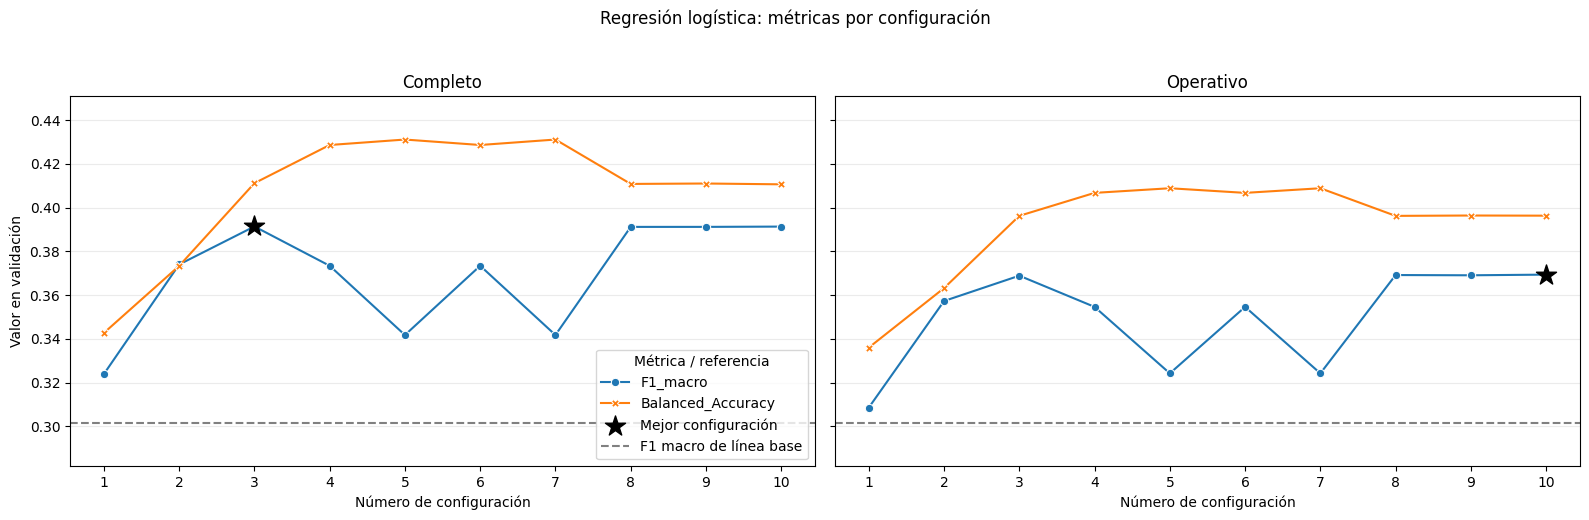

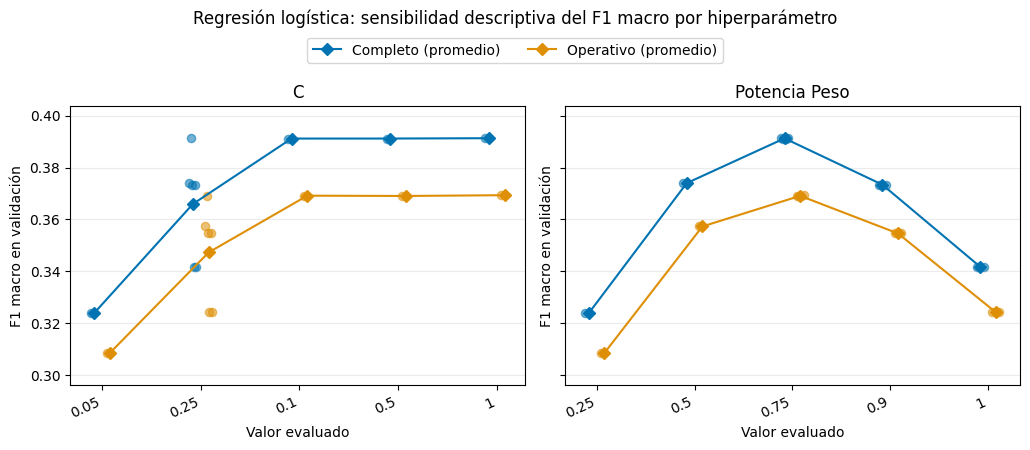

In [ ]:
graficar_configuraciones(resultados_logistica, 'Regresión logística')

#### Resultados de regresión logística

La ampliación de la búsqueda muestra que el efecto de los hiperparámetros depende del conjunto de predictores. En el escenario completo, las mejores configuraciones alcanzan un `F1_macro` cercano a **0,39**, mientras que en el escenario operativo el máximo se sitúa alrededor de **0,37**. En ambos casos se supera la línea base (`F1_macro = 0,3017`), aunque el margen de mejora continúa siendo moderado.

La ponderación de clases presenta un comportamiento no lineal. Incrementar `potencia_peso` mejora inicialmente el desempeño y favorece especialmente la `Balanced_Accuracy`, pero valores cercanos a `0,90–1,00` empiezan a deteriorar el `F1_macro`. Esto indica que una ponderación demasiado intensa mejora el equilibrio entre clases a costa de aumentar errores en la clasificación global. El parámetro `C` presenta un efecto menor y tiende a estabilizarse en los valores intermedios y altos evaluados.

La incorporación del clima incrementa el `F1_macro` de **0,3888 a 0,3914** en el escenario completo, equivalente a una mejora relativa aproximada de **0,67 %**. En el escenario operativo aumenta de **0,3626 a 0,3694**, una mejora relativa cercana al **1,88 %**. Sin embargo, la `Balanced_Accuracy` disminuye ligeramente en ambos casos, por lo que el aporte climático no es consistente entre las métricas principales.

Las variables meteorológicas sí producen mejoras en algunas métricas probabilísticas. El `Log_Loss` disminuye de **0,8339 a 0,8147** en el escenario completo y de **0,8552 a 0,8328** en el operativo. Aun así, el incremento en capacidad de clasificación es reducido, por lo que el verdadero aporte del clima deberá contrastarse con los demás modelos antes de decidir su inclusión en el diseño final.

### 7.2 Random Forest

Random Forest permite capturar relaciones no lineales e interacciones entre los predictores sin asumir una forma funcional específica. Para esta familia se evalúan diferentes combinaciones de profundidad, número de árboles, tamaño mínimo de hoja y ponderación de clases mediante un proceso secuencial de ajuste de hiperparámetros:

1. definir las configuraciones candidatas;
2. evaluarlas en `COMPLETO_CON_CLIMA` y seleccionar la mejor con base en `F1_macro`, `Balanced_Accuracy` y, como criterio de desempate, `Log_Loss`;
3. reutilizar la configuración seleccionada en `COMPLETO_SIN_CLIMA`;
4. repetir el mismo procedimiento para los escenarios operativos;
5. comparar el desempeño de las configuraciones evaluadas y registrar los mejores resultados para la selección final entre modelos.

El ajuste de hiperparámetros se realiza únicamente en los escenarios con clima. La configuración ganadora se mantiene sin modificaciones al evaluar el escenario equivalente sin clima, permitiendo aislar el aporte de las variables meteorológicas sin mezclarlo con cambios en la complejidad o ponderación del modelo.

In [60]:
# Configuraciones de hiperparámetros para Random Forest con pesos de clase suaves
CONFIG_RF = [
    {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.75},
    {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}, 
    {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.85},
    {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.90},
    {'n_estimators': 300, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75},
    {'n_estimators': 200, 'max_depth': 30, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75},
    {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.75},
]

In [61]:
# Ajuste del modelo Random Forest en el escenario completo con clima
nombre_modelo = 'RANDOM_FOREST'
escenario = 'COMPLETO_CON_CLIMA'
filas_rf_completo = []
modelos_rf_completo = {}
probas_rf_completo = {}

for numero, parametros in enumerate(CONFIG_RF, start=1):
    print(f'Configuración {numero}/{len(CONFIG_RF)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo,
        escenario,
        parametros,
        datos_escenario[escenario]['ajuste'],
        y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo,
        datos_escenario[escenario]['validacion'],
        clases_codificadas
    )
    filas_rf_completo.append({
        'MODELO': nombre_modelo,
        'ALCANCE': 'COMPLETO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_rf_completo[numero] = modelo
    probas_rf_completo[numero] = probabilidades

tabla_rf_completo = pd.DataFrame(filas_rf_completo)
display(tabla_rf_completo.round(4))

Configuración 1/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 2/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 3/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.85}
Configuración 4/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.9}
Configuración 5/7: {'n_estimators': 300, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 6/7: {'n_estimators': 200, 'max_depth': 30, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 7/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.75}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,COMPLETO,1,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",173.3825,0.8065,0.3565,0.3492,0.7560,0.3830,0.6142,0.7282,0.4058,0.2474
1,RANDOM_FOREST,COMPLETO,2,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",141.2037,0.7938,0.3656,0.3613,0.7541,0.3841,0.6174,0.7573,0.4265,0.2569
2,RANDOM_FOREST,COMPLETO,3,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",115.2276,0.7535,0.3823,0.3737,0.7388,0.3827,0.6133,0.8211,0.4724,0.2574
3,RANDOM_FOREST,COMPLETO,4,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",103.2059,0.7253,0.3910,0.3768,0.7251,0.3816,0.6116,0.8543,0.4963,0.2464
4,RANDOM_FOREST,COMPLETO,5,"{""n_estimators"": 300, ""max_depth"": 24, ""min_sa...",153.2090,0.7943,0.3652,0.3608,0.7542,0.3847,0.6176,0.7577,0.4267,0.2581
5,RANDOM_FOREST,COMPLETO,6,"{""n_estimators"": 200, ""max_depth"": 30, ""min_sa...",127.7661,0.7982,0.3645,0.3603,0.7557,0.3841,0.6166,0.7403,0.4146,0.2476
6,RANDOM_FOREST,COMPLETO,7,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",97.6729,0.7896,0.3671,0.3631,0.7526,0.3831,0.6146,0.7724,0.4370,0.2639


In [62]:
# Identificar la mejor configuración de Random Forest en el escenario completo con clima
mejor_rf_completo = (
    tabla_rf_completo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_rf_completo['CONFIGURACION'])
parametros_rf_completo = CONFIG_RF[numero_mejor - 1].copy()
modelo_rf_completo_con = modelos_rf_completo[numero_mejor]
proba_rf_completo_con = probas_rf_completo[numero_mejor]
print('Mejor configuración COMPLETO:', parametros_rf_completo)

Mejor configuración COMPLETO: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.9}


In [63]:
# Ajuste del modelo Random Forest en el escenario completo sin clima
modelo_rf_completo_sin, segundos_rf_completo_sin = ajustar_modelo(
    'RANDOM_FOREST',
    'COMPLETO_SIN_CLIMA',
    parametros_rf_completo,
    datos_escenario['COMPLETO_SIN_CLIMA']['ajuste'],
    y_ajuste
)
proba_rf_completo_sin = ordenar_probabilidades(
    modelo_rf_completo_sin,
    datos_escenario['COMPLETO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_rf_completo = pd.DataFrame([
    {
        'MODELO': 'RANDOM_FOREST', 
        'ESCENARIO': 'COMPLETO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_rf_completo_sin,
        **calcular_metricas(y_val, proba_rf_completo_sin)
    },
    {
        'MODELO': 'RANDOM_FOREST',
        'ESCENARIO': 'COMPLETO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_rf_completo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_rf_completo_con)
    }
])
display(comparacion_rf_completo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,COMPLETO_SIN_CLIMA,88.6388,0.6516,0.4129,0.3811,0.6839,0.3854,0.6164,0.9158,0.5398,0.1911
1,RANDOM_FOREST,COMPLETO_CON_CLIMA,103.2059,0.7253,0.3910,0.3768,0.7251,0.3816,0.6116,0.8543,0.4963,0.2464


In [64]:
# Ajuste del modelo Random Forest en el escenario operativo con clima
nombre_modelo = 'RANDOM_FOREST'
escenario = 'OPERATIVO_CON_CLIMA'
filas_rf_operativo = []
modelos_rf_operativo = {}
probas_rf_operativo = {}

for numero, parametros in enumerate(CONFIG_RF, start=1):
    print(f'Configuración {numero}/{len(CONFIG_RF)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo,
        escenario,
        parametros,
        datos_escenario[escenario]['ajuste'],
        y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo,
        datos_escenario[escenario]['validacion'],
        clases_codificadas
    )
    filas_rf_operativo.append({
        'MODELO': nombre_modelo,
        'ALCANCE': 'OPERATIVO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_rf_operativo[numero] = modelo
    probas_rf_operativo[numero] = probabilidades

tabla_rf_operativo = pd.DataFrame(filas_rf_operativo)
display(tabla_rf_operativo.round(4))

Configuración 1/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 2/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 3/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.85}
Configuración 4/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.9}
Configuración 5/7: {'n_estimators': 300, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 6/7: {'n_estimators': 200, 'max_depth': 30, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.75}
Configuración 7/7: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'potencia_peso': 0.75}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,OPERATIVO,1,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",80.4604,0.8046,0.3580,0.3511,0.7560,0.3750,0.5962,0.7460,0.4175,0.2592
1,RANDOM_FOREST,OPERATIVO,2,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",64.0280,0.7948,0.3692,0.3635,0.7560,0.3760,0.5982,0.7666,0.4321,0.2646
2,RANDOM_FOREST,OPERATIVO,3,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",62.3767,0.7487,0.3863,0.3697,0.7368,0.3745,0.5955,0.8341,0.4809,0.2607
3,RANDOM_FOREST,OPERATIVO,4,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",65.4492,0.7185,0.3943,0.3684,0.7211,0.3740,0.5941,0.8714,0.5076,0.2490
4,RANDOM_FOREST,OPERATIVO,5,"{""n_estimators"": 300, ""max_depth"": 24, ""min_sa...",94.5126,0.7950,0.3691,0.3634,0.7561,0.3760,0.5978,0.7669,0.4323,0.2653
5,RANDOM_FOREST,OPERATIVO,6,"{""n_estimators"": 200, ""max_depth"": 30, ""min_sa...",82.0328,0.7963,0.3669,0.3614,0.7559,0.3764,0.6002,0.7444,0.4166,0.2476
6,RANDOM_FOREST,OPERATIVO,7,"{""n_estimators"": 200, ""max_depth"": 24, ""min_sa...",60.4751,0.7886,0.3720,0.3655,0.7539,0.3756,0.5986,0.7763,0.4389,0.2652


In [65]:
# Identificar la mejor configuración de Random Forest en el escenario operativo con clima
mejor_rf_operativo = (
    tabla_rf_operativo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_rf_operativo['CONFIGURACION'])
parametros_rf_operativo = CONFIG_RF[numero_mejor - 1].copy()
modelo_rf_operativo_con = modelos_rf_operativo[numero_mejor]
proba_rf_operativo_con = probas_rf_operativo[numero_mejor]
print('Mejor configuración OPERATIVO:', parametros_rf_operativo)

Mejor configuración OPERATIVO: {'n_estimators': 200, 'max_depth': 24, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'potencia_peso': 0.85}


In [66]:
# Ajuste del modelo Random Forest en el escenario operativo sin clima
modelo_rf_operativo_sin, segundos_rf_operativo_sin = ajustar_modelo(
    'RANDOM_FOREST',
    'OPERATIVO_SIN_CLIMA',
    parametros_rf_operativo,
    datos_escenario['OPERATIVO_SIN_CLIMA']['ajuste'],
    y_ajuste
)
proba_rf_operativo_sin = ordenar_probabilidades(
    modelo_rf_operativo_sin,
    datos_escenario['OPERATIVO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_rf_operativo = pd.DataFrame([
    {
        'MODELO': 'RANDOM_FOREST',
        'ESCENARIO': 'OPERATIVO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_rf_operativo_sin,
        **calcular_metricas(y_val, proba_rf_operativo_sin)
    },
    {
        'MODELO': 'RANDOM_FOREST', 
        'ESCENARIO': 'OPERATIVO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_rf_operativo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_rf_operativo_con)
    }
])
display(comparacion_rf_operativo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,OPERATIVO_SIN_CLIMA,50.7639,0.6786,0.4027,0.3664,0.6985,0.3767,0.5967,0.9054,0.5316,0.2167
1,RANDOM_FOREST,OPERATIVO_CON_CLIMA,62.3767,0.7487,0.3863,0.3697,0.7368,0.3745,0.5955,0.8341,0.4809,0.2607


In [67]:
# Consolidación de resultados de Random Forest para ambos escenarios
resultados_rf = pd.concat([
    tabla_rf_completo,
    tabla_rf_operativo
], ignore_index=True)
comparacion_rf = pd.concat([
    comparacion_rf_completo,
    comparacion_rf_operativo
], ignore_index=True)

mejores_parametros[('RANDOM_FOREST', 'COMPLETO')] = parametros_rf_completo
mejores_parametros[('RANDOM_FOREST', 'OPERATIVO')] = parametros_rf_operativo
for escenario, modelo, probabilidades in [
    ('COMPLETO_SIN_CLIMA', modelo_rf_completo_sin, proba_rf_completo_sin),
    ('COMPLETO_CON_CLIMA', modelo_rf_completo_con, proba_rf_completo_con),
    ('OPERATIVO_SIN_CLIMA', modelo_rf_operativo_sin, proba_rf_operativo_sin),
    ('OPERATIVO_CON_CLIMA', modelo_rf_operativo_con, proba_rf_operativo_con),
]:
    modelos_validacion[('RANDOM_FOREST', escenario)] = modelo
    probabilidades_validacion[('RANDOM_FOREST', escenario)] = probabilidades

resultados_ajuste_acumulados.append(resultados_rf)
resultados_validacion.extend(comparacion_rf.to_dict('records'))
display(comparacion_rf.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,RANDOM_FOREST,COMPLETO_SIN_CLIMA,88.6388,0.6516,0.4129,0.3811,0.6839,0.3854,0.6164,0.9158,0.5398,0.1911
1,RANDOM_FOREST,COMPLETO_CON_CLIMA,103.2059,0.7253,0.3910,0.3768,0.7251,0.3816,0.6116,0.8543,0.4963,0.2464
2,RANDOM_FOREST,OPERATIVO_SIN_CLIMA,50.7639,0.6786,0.4027,0.3664,0.6985,0.3767,0.5967,0.9054,0.5316,0.2167
3,RANDOM_FOREST,OPERATIVO_CON_CLIMA,62.3767,0.7487,0.3863,0.3697,0.7368,0.3745,0.5955,0.8341,0.4809,0.2607


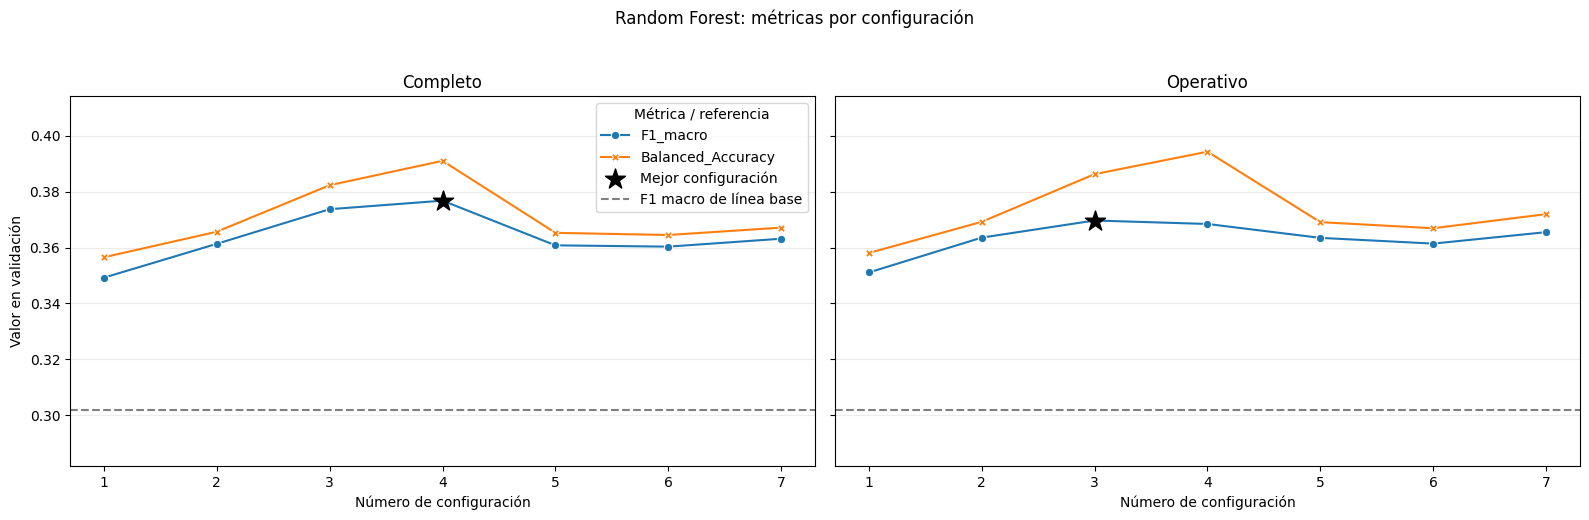

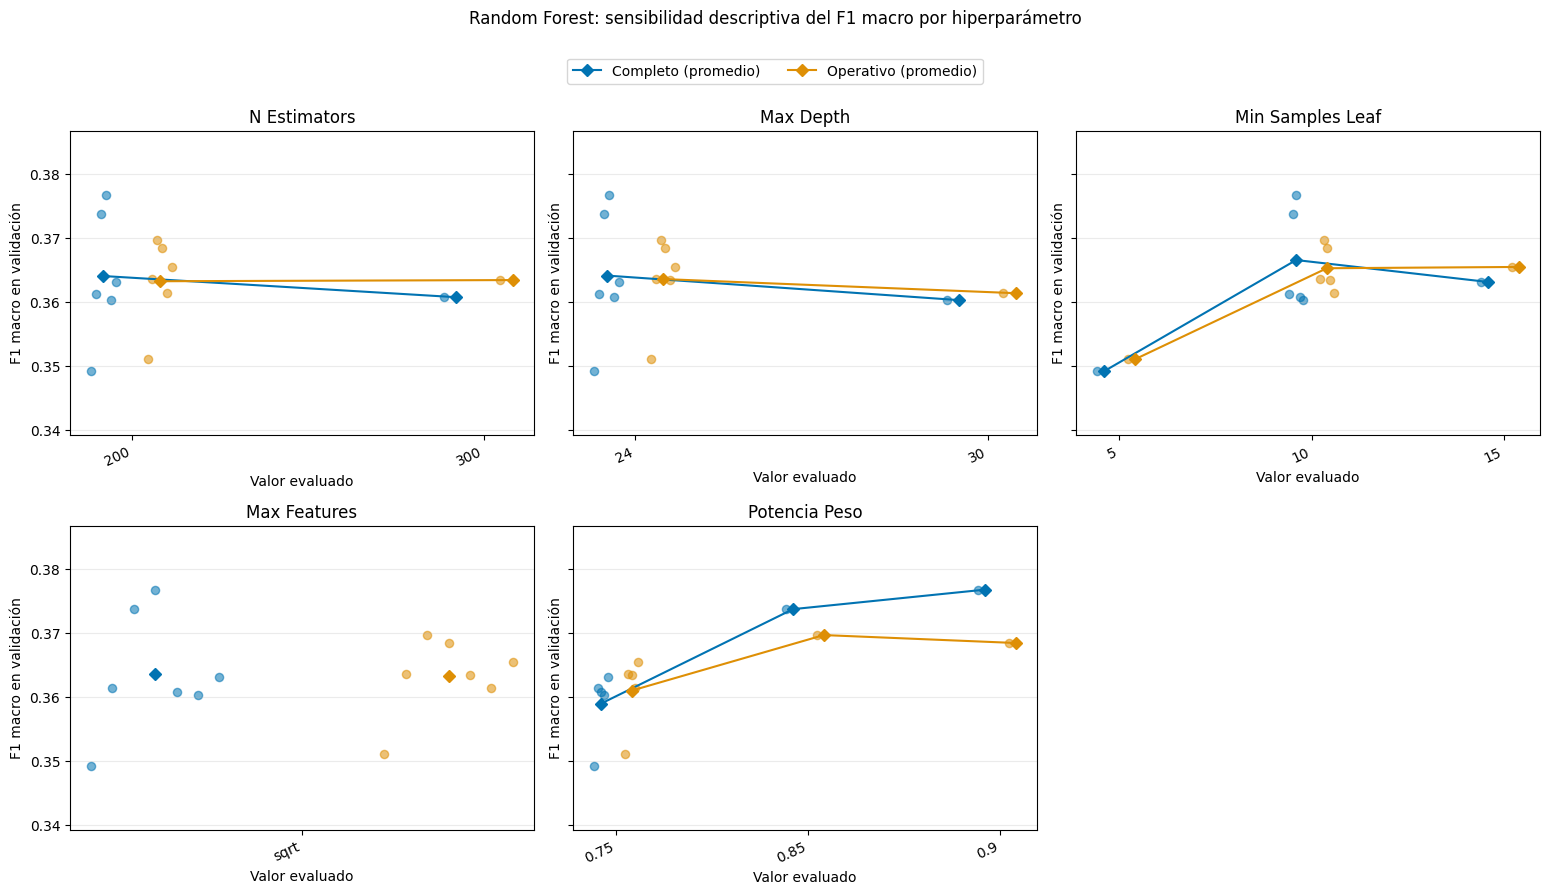

In [68]:
graficar_configuraciones(resultados_rf, 'Random Forest')

#### Resultados de Random Forest

La ampliación de hiperparámetros mejora parcialmente el desempeño de Random Forest, aunque las ganancias se estabilizan rápidamente. En el escenario completo, el mejor resultado alcanza un `F1_macro` de **0,3811** sin clima, mientras que en el escenario operativo el mejor valor se sitúa alrededor de **0,3697** con clima. Ambos resultados superan la línea base (`F1_macro = 0,3017`), pero permanecen por debajo del mejor desempeño obtenido con regresión logística en el escenario completo.

La exploración muestra que valores intermedios y altos de `potencia_peso` favorecen inicialmente el desempeño, pero continuar incrementando la ponderación no genera mejoras sostenidas. De igual forma, aumentar el número de árboles o la profundidad por encima de los valores ya evaluados no produce una ganancia clara en `F1_macro`. `min_samples_leaf` presenta un comportamiento más favorable alrededor de valores intermedios, aunque su efecto también es limitado.

El aporte del clima depende del escenario. En el alcance completo, el `F1_macro` disminuye de **0,3811** a **0,3768**, equivalente a una reducción relativa aproximada de **1,13 %**. En el escenario operativo ocurre el comportamiento contrario: aumenta de **0,3664** a **0,3697**, una mejora relativa cercana al **0,90 %**.

Sin embargo, esta mejora operativa no es consistente entre las métricas principales. La `Balanced_Accuracy` disminuye de **0,4027** a **0,3863** al incorporar clima. Además, aunque `Log_Loss` y `Brier_multiclase` mejoran, el `ECE` aumenta, indicando una peor calibración de las probabilidades.

En conjunto, Random Forest supera la línea base pero no presenta una ventaja clara frente a la regresión logística. La búsqueda adicional tampoco evidencia ganancias suficientes para justificar una exploración más amplia de hiperparámetros, por lo que se conserva como modelo candidato y se continúa con XGBoost.

### 7.3 XGBoost

XGBoost permite modelar relaciones no lineales e interacciones complejas mediante un ensamble secuencial de árboles, en el que cada nueva iteración busca corregir los errores de las anteriores. Para esta familia se evalúan diferentes combinaciones de número de árboles, profundidad, tasa de aprendizaje, peso mínimo por nodo y ponderación de clases mediante un proceso secuencial de ajuste de hiperparámetros:

1. definir las configuraciones candidatas;
2. evaluarlas en `COMPLETO_CON_CLIMA` y seleccionar la mejor con base en `F1_macro`, `Balanced_Accuracy` y, como criterio de desempate, `Log_Loss`;
3. reutilizar la configuración seleccionada en `COMPLETO_SIN_CLIMA`;
4. repetir el mismo procedimiento para los escenarios operativos;
5. comparar el desempeño de las configuraciones evaluadas y registrar los mejores resultados para la selección final entre modelos.

El ajuste de hiperparámetros se realiza únicamente en los escenarios con clima. La configuración ganadora se conserva sin modificaciones al evaluar el escenario equivalente sin clima, de manera que la comparación permita aislar el aporte de las variables meteorológicas sin introducir diferencias adicionales asociadas a la configuración del modelo.

In [69]:
# Configuraciones de hiperparámetros para XGBoost con pesos de clase suaves
CONFIG_XGB = [
    {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25},
    {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25},
    {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.50},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 1.00},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.06, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.10, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 4, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 6, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 5, 'potencia_peso': 0.90},
    {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 15, 'potencia_peso': 0.90},
]

In [70]:
# Ajuste del modelo XGBoost en el escenario completo con clima
nombre_modelo = 'XGBOOST'
escenario = 'COMPLETO_CON_CLIMA'
filas_xgb_completo = []
modelos_xgb_completo = {}
probas_xgb_completo = {}

for numero, parametros in enumerate(CONFIG_XGB, start=1):
    print(f'Configuración {numero}/{len(CONFIG_XGB)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo, escenario, parametros,
        datos_escenario[escenario]['ajuste'], y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo, datos_escenario[escenario]['validacion'], clases_codificadas
    )
    filas_xgb_completo.append({
        'MODELO': nombre_modelo, 'ALCANCE': 'COMPLETO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_xgb_completo[numero] = modelo
    probas_xgb_completo[numero] = probabilidades

tabla_xgb_completo = pd.DataFrame(filas_xgb_completo)
display(tabla_xgb_completo.round(4))

Configuración 1/14: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 2/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 3/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 4/14: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25}
Configuración 5/14: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.5}
Configuración 6/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}
Configuración 7/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}
Configuración 8/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, '

,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO,1,"{""n_estimators"": 160, ""max_depth"": 3, ""learnin...",7.8036,0.8264,0.3337,0.3027,0.7485,0.3876,0.6199,0.5785,0.3066,0.0940
1,XGBOOST,COMPLETO,2,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",11.2146,0.8260,0.3354,0.3068,0.7497,0.3917,0.6290,0.5735,0.3041,0.0884
2,XGBOOST,COMPLETO,3,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.0698,0.8243,0.3399,0.3176,0.7526,0.3931,0.6323,0.5709,0.3035,0.0807
3,XGBOOST,COMPLETO,4,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",14.6225,0.8245,0.3411,0.3198,0.7533,0.3938,0.6347,0.5683,0.3021,0.0761
4,XGBOOST,COMPLETO,5,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",14.7652,0.8070,0.3656,0.3650,0.7602,0.3942,0.6340,0.6431,0.3498,0.1632
5,XGBOOST,COMPLETO,6,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.1913,0.7197,0.4136,0.4026,0.7280,0.3923,0.6293,0.8063,0.4629,0.1948
6,XGBOOST,COMPLETO,7,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.1242,0.6100,0.4350,0.3859,0.6594,0.3917,0.6282,0.9352,0.5526,0.1348
7,XGBOOST,COMPLETO,8,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.8446,0.4951,0.4382,0.3478,0.5694,0.3896,0.6247,1.0406,0.6239,0.0444
8,XGBOOST,COMPLETO,9,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.8271,0.6108,0.4339,0.3853,0.6598,0.3910,0.6267,0.9404,0.5561,0.1416
9,XGBOOST,COMPLETO,10,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",9.0473,0.6118,0.4323,0.3853,0.6612,0.3903,0.6260,0.9301,0.5493,0.1329


In [71]:
# Identificar la mejor configuración de XGBoost en el escenario completo con clima
mejor_xgb_completo = (
    tabla_xgb_completo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_xgb_completo['CONFIGURACION'])
parametros_xgb_completo = CONFIG_XGB[numero_mejor - 1].copy()
modelo_xgb_completo_con = modelos_xgb_completo[numero_mejor]
proba_xgb_completo_con = probas_xgb_completo[numero_mejor]
print('Mejor configuración COMPLETO:', parametros_xgb_completo)

Mejor configuración COMPLETO: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


In [72]:
# Ajuste del modelo XGBoost en el escenario completo sin clima
modelo_xgb_completo_sin, segundos_xgb_completo_sin = ajustar_modelo(
    'XGBOOST', 'COMPLETO_SIN_CLIMA', parametros_xgb_completo,
    datos_escenario['COMPLETO_SIN_CLIMA']['ajuste'], y_ajuste
)
proba_xgb_completo_sin = ordenar_probabilidades(
    modelo_xgb_completo_sin,
    datos_escenario['COMPLETO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_xgb_completo = pd.DataFrame([
    {
        'MODELO': 'XGBOOST',
        'ESCENARIO': 'COMPLETO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_xgb_completo_sin,
        **calcular_metricas(y_val, proba_xgb_completo_sin)
    },
    {
        'MODELO': 'XGBOOST', 
        'ESCENARIO': 'COMPLETO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_xgb_completo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_xgb_completo_con)
    }
])
display(comparacion_xgb_completo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO_SIN_CLIMA,8.0313,0.6815,0.4233,0.3988,0.7059,0.3933,0.6316,0.8410,0.4876,0.1651
1,XGBOOST,COMPLETO_CON_CLIMA,9.1913,0.7197,0.4136,0.4026,0.7280,0.3923,0.6293,0.8063,0.4629,0.1948


In [73]:
# Ajuste del modelo XGBoost en el escenario operativo con clima
nombre_modelo = 'XGBOOST'
escenario = 'OPERATIVO_CON_CLIMA'
filas_xgb_operativo = []
modelos_xgb_operativo = {}
probas_xgb_operativo = {}

for numero, parametros in enumerate(CONFIG_XGB, start=1):
    print(f'Configuración {numero}/{len(CONFIG_XGB)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo, escenario, parametros,
        datos_escenario[escenario]['ajuste'], y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo, datos_escenario[escenario]['validacion'], clases_codificadas
    )
    filas_xgb_operativo.append({
        'MODELO': nombre_modelo, 'ALCANCE': 'OPERATIVO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_xgb_operativo[numero] = modelo
    probas_xgb_operativo[numero] = probabilidades

tabla_xgb_operativo = pd.DataFrame(filas_xgb_operativo)
display(tabla_xgb_operativo.round(4))

Configuración 1/14: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 2/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.03, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 3/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.25}
Configuración 4/14: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.25}
Configuración 5/14: {'n_estimators': 320, 'max_depth': 7, 'learning_rate': 0.05, 'min_child_weight': 20, 'potencia_peso': 0.5}
Configuración 6/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}
Configuración 7/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.9}
Configuración 8/14: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, '

,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,OPERATIVO,1,"{""n_estimators"": 160, ""max_depth"": 3, ""learnin...",4.3906,0.8267,0.3333,0.3017,0.7482,0.3777,0.6006,0.5795,0.3058,0.0887
1,XGBOOST,OPERATIVO,2,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",8.3464,0.8262,0.3336,0.3027,0.7484,0.3806,0.6069,0.5747,0.3034,0.0810
2,XGBOOST,OPERATIVO,3,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",7.5049,0.8257,0.3352,0.3067,0.7496,0.3815,0.6096,0.5722,0.3025,0.0746
3,XGBOOST,OPERATIVO,4,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",12.2679,0.8254,0.3364,0.3095,0.7505,0.3819,0.6109,0.5701,0.3014,0.0686
4,XGBOOST,OPERATIVO,5,"{""n_estimators"": 320, ""max_depth"": 7, ""learnin...",12.3689,0.8139,0.3544,0.3455,0.7581,0.3818,0.6104,0.6387,0.3449,0.1620
5,XGBOOST,OPERATIVO,6,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",7.4543,0.7413,0.3944,0.3767,0.7351,0.3804,0.6071,0.7929,0.4515,0.2130
6,XGBOOST,OPERATIVO,7,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",7.4920,0.6374,0.4089,0.3690,0.6748,0.3796,0.6063,0.9204,0.5405,0.1662
7,XGBOOST,OPERATIVO,8,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",7.3991,0.5337,0.4153,0.3491,0.6012,0.3788,0.6042,1.0193,0.6077,0.0886
8,XGBOOST,OPERATIVO,9,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",7.6811,0.6383,0.4078,0.3670,0.6748,0.3795,0.6057,0.9259,0.5443,0.1729
9,XGBOOST,OPERATIVO,10,"{""n_estimators"": 240, ""max_depth"": 5, ""learnin...",7.7622,0.6398,0.4081,0.3700,0.6769,0.3790,0.6049,0.9140,0.5362,0.1631


In [74]:
# Identificar la mejor configuración de XGBoost en el escenario operativo con clima
mejor_xgb_operativo = (
    tabla_xgb_operativo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_xgb_operativo['CONFIGURACION'])
parametros_xgb_operativo = CONFIG_XGB[numero_mejor - 1].copy()
modelo_xgb_operativo_con = modelos_xgb_operativo[numero_mejor]
proba_xgb_operativo_con = probas_xgb_operativo[numero_mejor]
print('Mejor configuración OPERATIVO:', parametros_xgb_operativo)

Mejor configuración OPERATIVO: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


In [75]:
# Ajuste del modelo XGBoost en el escenario operativo sin clima
modelo_xgb_operativo_sin, segundos_xgb_operativo_sin = ajustar_modelo(
    'XGBOOST', 'OPERATIVO_SIN_CLIMA', parametros_xgb_operativo,
    datos_escenario['OPERATIVO_SIN_CLIMA']['ajuste'], y_ajuste
)
proba_xgb_operativo_sin = ordenar_probabilidades(
    modelo_xgb_operativo_sin,
    datos_escenario['OPERATIVO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_xgb_operativo = pd.DataFrame([
    {
        'MODELO': 'XGBOOST', 
        'ESCENARIO': 'OPERATIVO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_xgb_operativo_sin,
        **calcular_metricas(y_val, proba_xgb_operativo_sin)
    },
    {
        'MODELO': 'XGBOOST', 
        'ESCENARIO': 'OPERATIVO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_xgb_operativo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_xgb_operativo_con)
    }
])
display(comparacion_xgb_operativo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,OPERATIVO_SIN_CLIMA,6.6873,0.6944,0.4055,0.3742,0.7094,0.3811,0.6067,0.8416,0.4864,0.1851
1,XGBOOST,OPERATIVO_CON_CLIMA,7.4543,0.7413,0.3944,0.3767,0.7351,0.3804,0.6071,0.7929,0.4515,0.2130


In [76]:
# Consolidación de resultados de XGBoost para ambos escenarios
resultados_xgb = pd.concat([
    tabla_xgb_completo,
    tabla_xgb_operativo
], ignore_index=True)
comparacion_xgb = pd.concat([
    comparacion_xgb_completo,
    comparacion_xgb_operativo
], ignore_index=True)

mejores_parametros[('XGBOOST', 'COMPLETO')] = parametros_xgb_completo
mejores_parametros[('XGBOOST', 'OPERATIVO')] = parametros_xgb_operativo
for escenario, modelo, probabilidades in [
    ('COMPLETO_SIN_CLIMA', modelo_xgb_completo_sin, proba_xgb_completo_sin),
    ('COMPLETO_CON_CLIMA', modelo_xgb_completo_con, proba_xgb_completo_con),
    ('OPERATIVO_SIN_CLIMA', modelo_xgb_operativo_sin, proba_xgb_operativo_sin),
    ('OPERATIVO_CON_CLIMA', modelo_xgb_operativo_con, proba_xgb_operativo_con),
]:
    modelos_validacion[('XGBOOST', escenario)] = modelo
    probabilidades_validacion[('XGBOOST', escenario)] = probabilidades

resultados_ajuste_acumulados.append(resultados_xgb)
resultados_validacion.extend(comparacion_xgb.to_dict('records'))
display(comparacion_xgb.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO_SIN_CLIMA,8.0313,0.6815,0.4233,0.3988,0.7059,0.3933,0.6316,0.8410,0.4876,0.1651
1,XGBOOST,COMPLETO_CON_CLIMA,9.1913,0.7197,0.4136,0.4026,0.7280,0.3923,0.6293,0.8063,0.4629,0.1948
2,XGBOOST,OPERATIVO_SIN_CLIMA,6.6873,0.6944,0.4055,0.3742,0.7094,0.3811,0.6067,0.8416,0.4864,0.1851
3,XGBOOST,OPERATIVO_CON_CLIMA,7.4543,0.7413,0.3944,0.3767,0.7351,0.3804,0.6071,0.7929,0.4515,0.2130


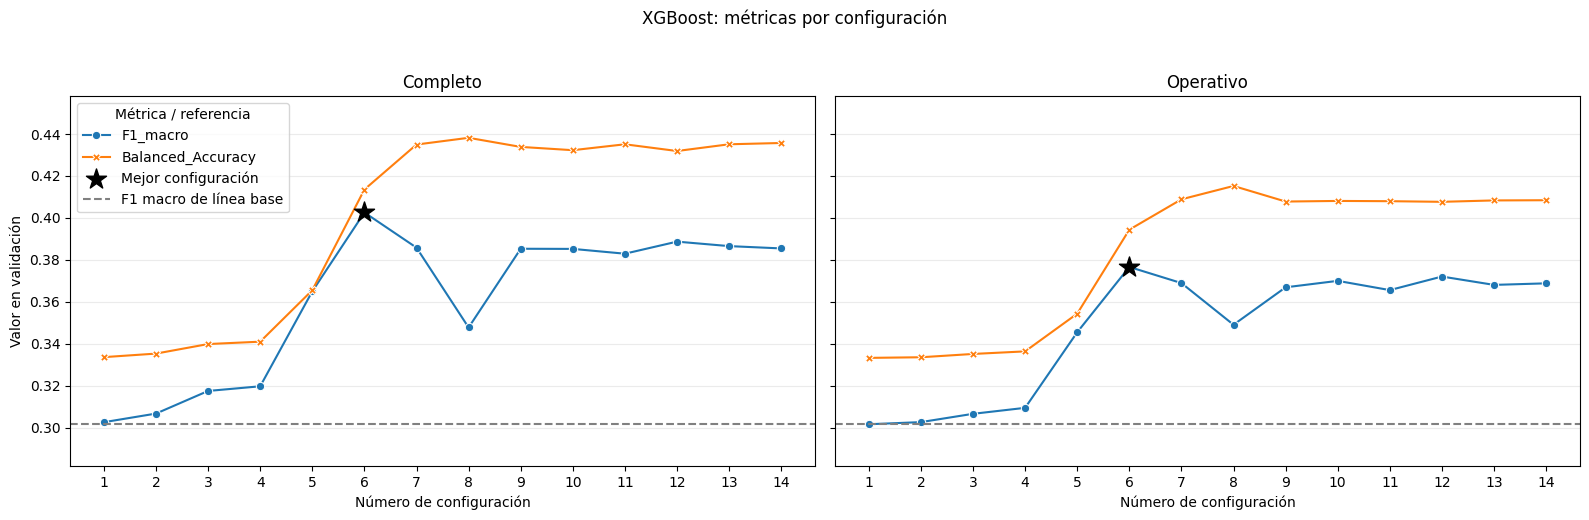

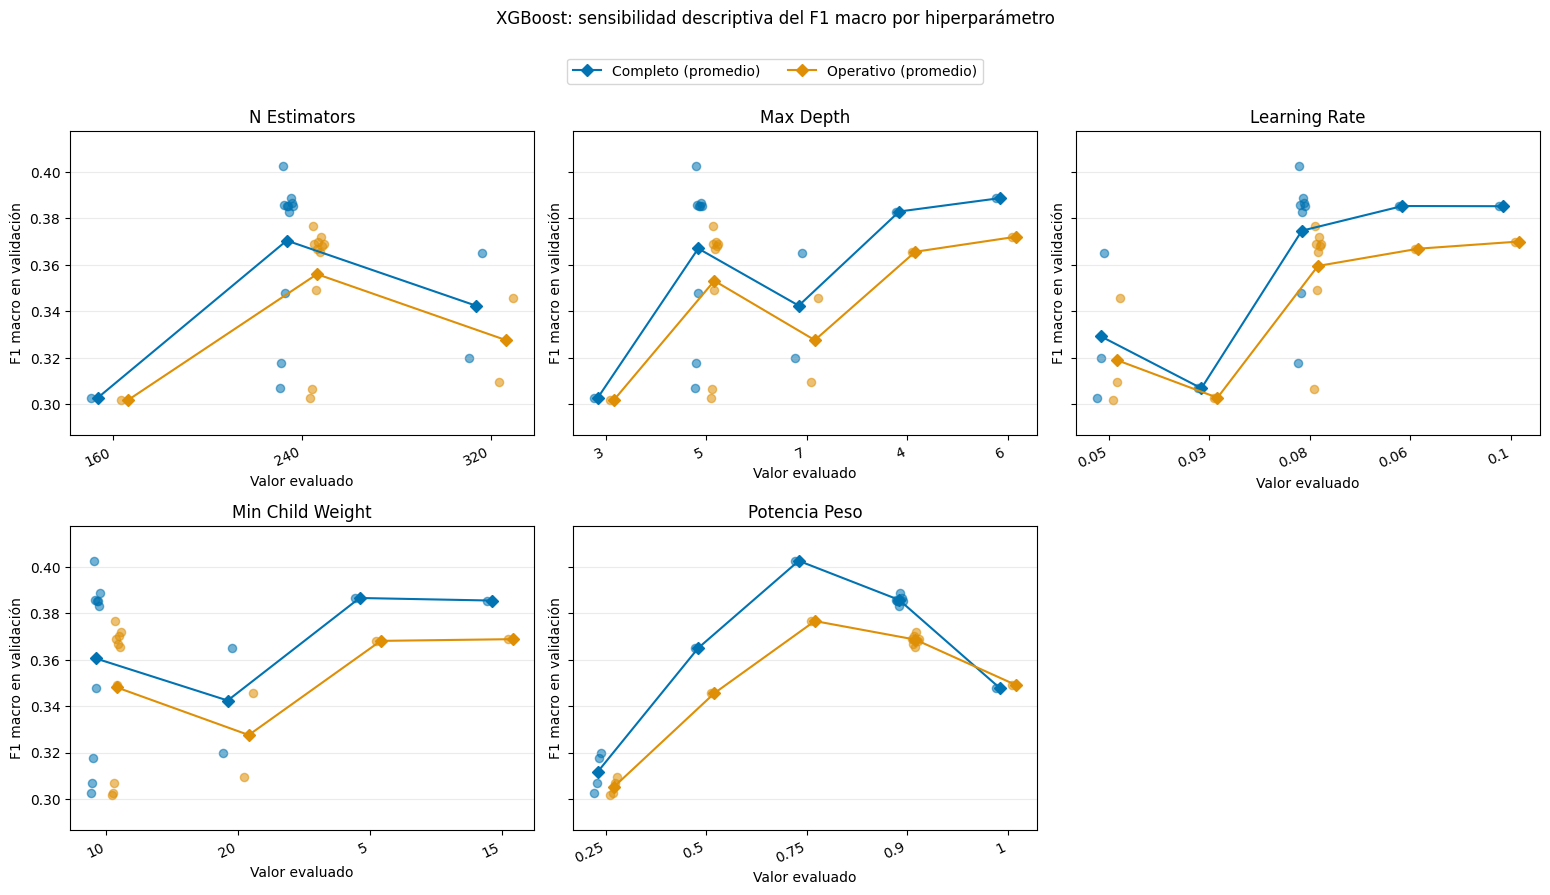

In [77]:
graficar_configuraciones(resultados_xgb, 'XGBoost')

#### Resultados de XGBoost

XGBoost obtiene el mejor desempeño observado hasta este punto entre los modelos evaluados. En el escenario completo alcanza un `F1_macro` de **0,4026** con clima, mientras que en el escenario operativo obtiene **0,3767**, superando los mejores resultados de regresión logística y Random Forest.

La exploración de hiperparámetros muestra que la ponderación de clases tiene un efecto importante sobre el desempeño. El `F1_macro` mejora progresivamente al aumentar `potencia_peso` hasta valores cercanos a **0,75**, pero posteriormente se estabiliza o disminuye. Las mejores configuraciones se concentran además alrededor de `n_estimators = 240`, profundidades intermedias y tasas de aprendizaje cercanas a `0,08`.

La incorporación del clima produce una mejora pequeña en `F1_macro`. En el escenario completo aumenta de **0,3988** a **0,4026**, equivalente a aproximadamente **0,95 %**, mientras que en el escenario operativo pasa de **0,3742** a **0,3767**, una mejora cercana al **0,67 %**. Sin embargo, la `Balanced_Accuracy` disminuye en ambos escenarios, de **0,4233** a **0,4136** en el completo y de **0,4055** a **0,3944** en el operativo.

Las variables meteorológicas sí mejoran algunas métricas probabilísticas. El `Log_Loss` disminuye de **0,8410** a **0,8063** en el escenario completo y de **0,8416** a **0,7929** en el operativo, y también se reduce el `Brier_multiclase`. En contraste, el `ECE` aumenta, por lo que la mejora probabilística tampoco es uniforme entre todas las métricas de calibración.

En conjunto, XGBoost presenta la mayor capacidad predictiva entre los modelos evaluados, aunque el aporte del clima sobre la clasificación continúa siendo reducido y no consistente entre `F1_macro` y `Balanced_Accuracy`. Esta diferencia deberá evaluarse posteriormente mediante el análisis global y el bootstrap pareado antes de definir el escenario final.

### 7.4 Red neuronal MLP

MLP permite modelar relaciones no lineales mediante una red neuronal multicapa capaz de aprender combinaciones complejas entre los predictores. Para esta familia se evalúan distintas arquitecturas, niveles de regularización y tasas de aprendizaje mediante un proceso secuencial de ajuste de hiperparámetros:

1. definir las configuraciones candidatas;
2. balancear la muestra de entrenamiento utilizada por la red neuronal;
3. evaluarlas en `COMPLETO_CON_CLIMA` y seleccionar la mejor con base en `F1_macro`, `Balanced_Accuracy` y, como criterio de desempate, `Log_Loss`;
4. reutilizar la configuración seleccionada en `COMPLETO_SIN_CLIMA`;
5. repetir el mismo procedimiento para los escenarios operativos;
6. comparar el desempeño de las configuraciones evaluadas y registrar los mejores resultados para la selección final entre modelos.

A diferencia de los modelos anteriores, MLP no utiliza directamente `class_weight`, por lo que el tratamiento del desbalance se realiza mediante una muestra de entrenamiento balanceada. El ajuste de hiperparámetros se efectúa únicamente en los escenarios con clima y la configuración ganadora se conserva sin modificaciones al evaluar el escenario equivalente sin clima, permitiendo aislar el aporte de las variables meteorológicas.

In [78]:
# Configuraciones de hiperparámetros para MLP sobre la muestra de entrenamiento balanceada
CONFIG_MLP = [
    {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007},
]

In [79]:
# Ajuste del modelo MLP en el escenario completo con clima
nombre_modelo = 'MLP'
escenario = 'COMPLETO_CON_CLIMA'
filas_mlp_completo = []
modelos_mlp_completo = {}
probas_mlp_completo = {}

for numero, parametros in enumerate(CONFIG_MLP, start=1):
    print(f'Configuración {numero}/{len(CONFIG_MLP)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo, escenario, parametros,
        datos_escenario[escenario]['ajuste'], y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo, datos_escenario[escenario]['validacion'], clases_codificadas
    )
    filas_mlp_completo.append({
        'MODELO': nombre_modelo, 'ALCANCE': 'COMPLETO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_mlp_completo[numero] = modelo
    probas_mlp_completo[numero] = probabilidades

tabla_mlp_completo = pd.DataFrame(filas_mlp_completo)
display(tabla_mlp_completo.round(4))

Configuración 1/3: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}
Configuración 2/3: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}
Configuración 3/3: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,COMPLETO,1,"{""hidden_layer_sizes"": [32], ""alpha"": 0.001, ""...",6.8859,0.4496,0.4278,0.3272,0.5309,0.3795,0.6081,1.0844,0.6518,0.0640
1,MLP,COMPLETO,2,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",31.9816,0.4024,0.4041,0.3003,0.4854,0.3658,0.5805,1.1687,0.7093,0.1668
2,MLP,COMPLETO,3,"{""hidden_layer_sizes"": [128, 64, 32], ""alpha"":...",66.2076,0.4214,0.3900,0.3027,0.5036,0.3604,0.5629,1.3543,0.7723,0.2607


In [80]:
# Identificar la mejor configuración de MLP en el escenario completo con clima
mejor_mlp_completo = (
    tabla_mlp_completo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_mlp_completo['CONFIGURACION'])
parametros_mlp_completo = CONFIG_MLP[numero_mejor - 1].copy()
modelo_mlp_completo_con = modelos_mlp_completo[numero_mejor]
proba_mlp_completo_con = probas_mlp_completo[numero_mejor]
print('Mejor configuración COMPLETO:', parametros_mlp_completo)

Mejor configuración COMPLETO: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}


In [81]:
# Ajuste del modelo MLP en el escenario completo sin clima
modelo_mlp_completo_sin, segundos_mlp_completo_sin = ajustar_modelo(
    'MLP', 'COMPLETO_SIN_CLIMA', parametros_mlp_completo,
    datos_escenario['COMPLETO_SIN_CLIMA']['ajuste'], y_ajuste
)
proba_mlp_completo_sin = ordenar_probabilidades(
    modelo_mlp_completo_sin,
    datos_escenario['COMPLETO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_mlp_completo = pd.DataFrame([
    {
        'MODELO': 'MLP',
        'ESCENARIO': 'COMPLETO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_mlp_completo_sin,
        **calcular_metricas(y_val, proba_mlp_completo_sin)
    },
    {
        'MODELO': 'MLP',
        'ESCENARIO': 'COMPLETO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_mlp_completo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_mlp_completo_con)
    }
])
display(comparacion_mlp_completo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,COMPLETO_SIN_CLIMA,2.9300,0.4449,0.4283,0.3248,0.5240,0.3804,0.6130,1.0806,0.6508,0.0595
1,MLP,COMPLETO_CON_CLIMA,6.8859,0.4496,0.4278,0.3272,0.5309,0.3795,0.6081,1.0844,0.6518,0.0640


In [82]:
# Ajuste del modelo MLP en el escenario operativo con clima
nombre_modelo = 'MLP'
escenario = 'OPERATIVO_CON_CLIMA'
filas_mlp_operativo = []
modelos_mlp_operativo = {}
probas_mlp_operativo = {}

for numero, parametros in enumerate(CONFIG_MLP, start=1):
    print(f'Configuración {numero}/{len(CONFIG_MLP)}: {parametros}')
    modelo, segundos = ajustar_modelo(
        nombre_modelo, escenario, parametros,
        datos_escenario[escenario]['ajuste'], y_ajuste
    )
    probabilidades = ordenar_probabilidades(
        modelo, datos_escenario[escenario]['validacion'], clases_codificadas
    )
    filas_mlp_operativo.append({
        'MODELO': nombre_modelo, 'ALCANCE': 'OPERATIVO',
        'CONFIGURACION': numero,
        'PARAMETROS': json.dumps(parametros, ensure_ascii=False),
        'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_val, probabilidades)
    })
    modelos_mlp_operativo[numero] = modelo
    probas_mlp_operativo[numero] = probabilidades

tabla_mlp_operativo = pd.DataFrame(filas_mlp_operativo)
display(tabla_mlp_operativo.round(4))

Configuración 1/3: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}
Configuración 2/3: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}
Configuración 3/3: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.003, 'learning_rate_init': 0.0007}


,MODELO,ALCANCE,CONFIGURACION,PARAMETROS,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,OPERATIVO,1,"{""hidden_layer_sizes"": [32], ""alpha"": 0.001, ""...",3.1153,0.4709,0.4031,0.3265,0.5511,0.3683,0.5870,1.0483,0.6287,0.0165
1,MLP,OPERATIVO,2,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",28.0068,0.4312,0.3832,0.3048,0.5156,0.3596,0.5615,1.1313,0.6890,0.1612
2,MLP,OPERATIVO,3,"{""hidden_layer_sizes"": [128, 64, 32], ""alpha"":...",110.6105,0.4530,0.3815,0.3108,0.5338,0.3569,0.5531,1.2872,0.7235,0.2252


In [83]:
# Identificar la mejor configuración de MLP en el escenario operativo con clima
mejor_mlp_operativo = (
    tabla_mlp_operativo
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .iloc[0]
)
numero_mejor = int(mejor_mlp_operativo['CONFIGURACION'])
parametros_mlp_operativo = CONFIG_MLP[numero_mejor - 1].copy()
modelo_mlp_operativo_con = modelos_mlp_operativo[numero_mejor]
proba_mlp_operativo_con = probas_mlp_operativo[numero_mejor]
print('Mejor configuración OPERATIVO:', parametros_mlp_operativo)

Mejor configuración OPERATIVO: {'hidden_layer_sizes': (32,), 'alpha': 0.001, 'learning_rate_init': 0.001}


In [84]:
# Ajuste del modelo MLP en el escenario operativo sin clima
modelo_mlp_operativo_sin, segundos_mlp_operativo_sin = ajustar_modelo(
    'MLP', 'OPERATIVO_SIN_CLIMA', parametros_mlp_operativo,
    datos_escenario['OPERATIVO_SIN_CLIMA']['ajuste'], y_ajuste
)
proba_mlp_operativo_sin = ordenar_probabilidades(
    modelo_mlp_operativo_sin,
    datos_escenario['OPERATIVO_SIN_CLIMA']['validacion'],
    clases_codificadas
)
comparacion_mlp_operativo = pd.DataFrame([
    {
        'MODELO': 'MLP', 
        'ESCENARIO': 'OPERATIVO_SIN_CLIMA',
        'SEGUNDOS_AJUSTE': segundos_mlp_operativo_sin,
        **calcular_metricas(y_val, proba_mlp_operativo_sin)
    },
    {
        'MODELO': 'MLP',
        'ESCENARIO': 'OPERATIVO_CON_CLIMA',
        'SEGUNDOS_AJUSTE': float(mejor_mlp_operativo['SEGUNDOS_AJUSTE']),
        **calcular_metricas(y_val, proba_mlp_operativo_con)
    }
])
display(comparacion_mlp_operativo.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,OPERATIVO_SIN_CLIMA,2.6917,0.4060,0.4032,0.3021,0.4887,0.3703,0.589,1.1167,0.6729,0.0742
1,MLP,OPERATIVO_CON_CLIMA,3.1153,0.4709,0.4031,0.3265,0.5511,0.3683,0.587,1.0483,0.6287,0.0165


In [85]:
# Consolidación de resultados de MLP para ambos escenarios
resultados_mlp = pd.concat([
    tabla_mlp_completo,
    tabla_mlp_operativo
], ignore_index=True)
comparacion_mlp = pd.concat([
    comparacion_mlp_completo,
    comparacion_mlp_operativo
], ignore_index=True)

mejores_parametros[('MLP', 'COMPLETO')] = parametros_mlp_completo
mejores_parametros[('MLP', 'OPERATIVO')] = parametros_mlp_operativo
for escenario, modelo, probabilidades in [
    ('COMPLETO_SIN_CLIMA', modelo_mlp_completo_sin, proba_mlp_completo_sin),
    ('COMPLETO_CON_CLIMA', modelo_mlp_completo_con, proba_mlp_completo_con),
    ('OPERATIVO_SIN_CLIMA', modelo_mlp_operativo_sin, proba_mlp_operativo_sin),
    ('OPERATIVO_CON_CLIMA', modelo_mlp_operativo_con, proba_mlp_operativo_con),
]:
    modelos_validacion[('MLP', escenario)] = modelo
    probabilidades_validacion[('MLP', escenario)] = probabilidades

resultados_ajuste_acumulados.append(resultados_mlp)
resultados_validacion.extend(comparacion_mlp.to_dict('records'))
display(comparacion_mlp.round(4))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,MLP,COMPLETO_SIN_CLIMA,2.9300,0.4449,0.4283,0.3248,0.5240,0.3804,0.6130,1.0806,0.6508,0.0595
1,MLP,COMPLETO_CON_CLIMA,6.8859,0.4496,0.4278,0.3272,0.5309,0.3795,0.6081,1.0844,0.6518,0.0640
2,MLP,OPERATIVO_SIN_CLIMA,2.6917,0.4060,0.4032,0.3021,0.4887,0.3703,0.5890,1.1167,0.6729,0.0742
3,MLP,OPERATIVO_CON_CLIMA,3.1153,0.4709,0.4031,0.3265,0.5511,0.3683,0.5870,1.0483,0.6287,0.0165


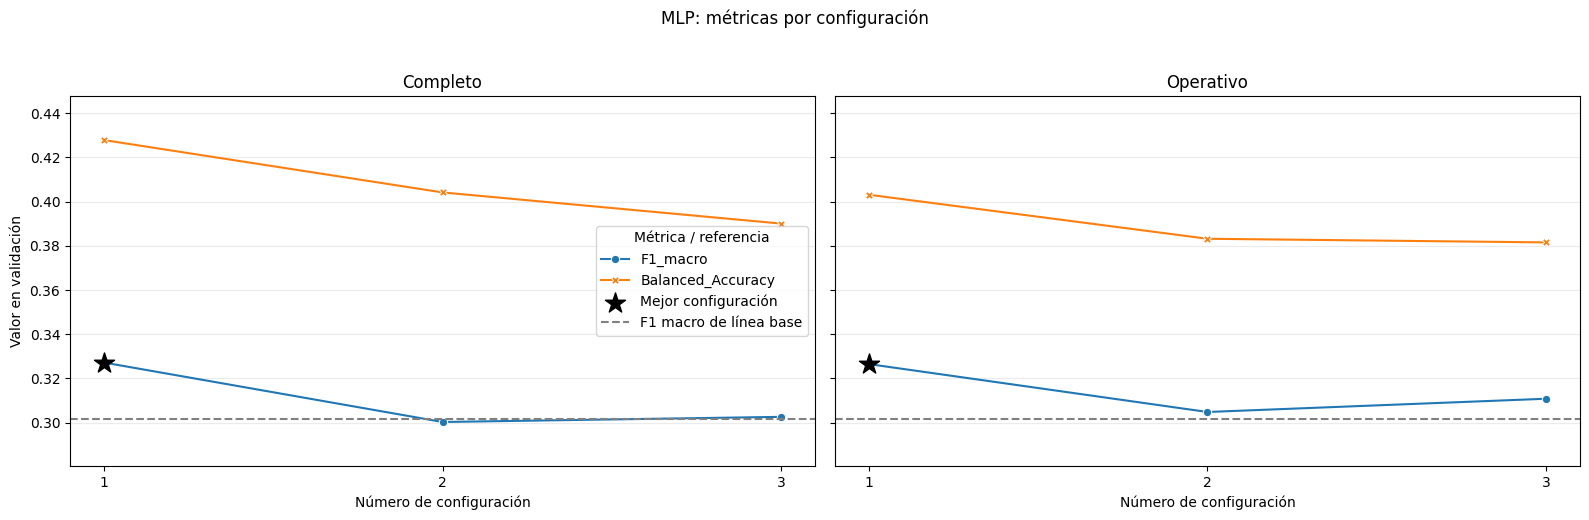

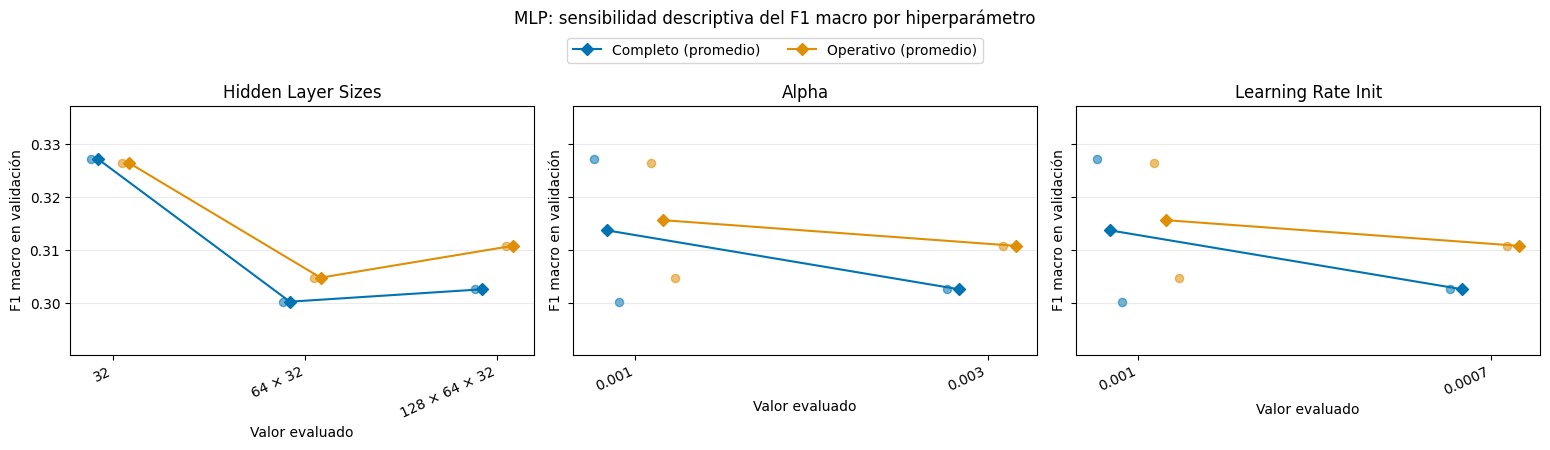

In [86]:
graficar_configuraciones(resultados_mlp, 'MLP')

#### Resultados de MLP

MLP presenta el desempeño más bajo entre los modelos evaluados. En el escenario completo, el mejor `F1_macro` alcanza **0,3272** con clima, mientras que en el escenario operativo llega a **0,3265**. Aunque ambos valores superan ligeramente la línea base (`F1_macro = 0,3017`), la mejora es reducida frente a la obtenida con regresión logística, Random Forest y XGBoost.

La exploración de arquitecturas muestra que aumentar el número de capas y neuronas no produce mejoras. La configuración más sencilla, con una sola capa oculta de 32 neuronas, obtiene el mejor desempeño tanto en el escenario completo como en el operativo. Las arquitecturas más profundas reducen el `F1_macro`, lo que indica que una mayor complejidad no aporta capacidad predictiva adicional para este problema.

La incorporación del clima aumenta el `F1_macro` de **0,3248** a **0,3272** en el escenario completo, una mejora relativa aproximada de **0,74 %**. En el escenario operativo el aumento es mayor, de **0,3021** a **0,3265**, equivalente a aproximadamente **8,08 %**. Sin embargo, esta mejora parte de un desempeño inicial muy bajo y no permite que MLP alcance a los demás modelos.

En las métricas probabilísticas, el escenario operativo con clima presenta una reducción importante en `Log_Loss`, `Brier_multiclase` y `ECE`, pero mantiene valores de `PR_AUC_macro` y `ROC_AUC_OVR_macro` inferiores a los obtenidos por XGBoost.

En conjunto, MLP supera marginalmente la línea base, pero no presenta una ventaja competitiva frente a los demás modelos. Por esta razón, no se justifica ampliar la búsqueda de hiperparámetros y se conserva únicamente como referencia dentro de la comparación final.

## 8. Comparación final de modelos, variables disponibles y clima

In [87]:
# Consolidar una sola evaluación por modelo y escenario
resultados_ajuste = pd.concat(resultados_ajuste_acumulados, ignore_index=True).drop_duplicates()
resultados_validacion = pd.DataFrame(resultados_validacion).copy()

# Reconstruir estas etiquetas desde ESCENARIO para evitar valores faltantes
# cuando las celdas de los modelos se ejecutan en momentos diferentes.
escenarios_texto = resultados_validacion['ESCENARIO'].astype(str)
resultados_validacion['ALCANCE'] = np.select(
    [
        escenarios_texto.str.startswith('COMPLETO_'),
        escenarios_texto.str.startswith('OPERATIVO_')
    ],
    ['COMPLETO', 'OPERATIVO'],
    default='BASELINE'
)
resultados_validacion['CLIMA'] = np.select(
    [
        escenarios_texto.str.endswith('_CON_CLIMA'),
        escenarios_texto.str.endswith('_SIN_CLIMA')
    ],
    ['CON_CLIMA', 'SIN_CLIMA'],
    default='SIN_PREDICTORES'
)

# Si una celda se ejecutó más de una vez, conservar la mejor evaluación
# de cada combinación modelo-escenario y evitar promedios artificiales.
resultados_validacion = (
    resultados_validacion
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .drop_duplicates(subset=['MODELO', 'ESCENARIO'], keep='first')
    .reset_index(drop=True)
)

display(resultados_validacion.drop(columns=['ALCANCE', 'CLIMA']))


,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO_CON_CLIMA,9.191294,0.719693,0.413563,0.402606,0.728019,0.392312,0.629305,0.806304,0.462897,0.194751
1,XGBOOST,COMPLETO_SIN_CLIMA,8.031286,0.681514,0.423286,0.398788,0.705912,0.393305,0.631596,0.840980,0.487648,0.165054
2,REGRESION_LOGISTICA,COMPLETO_CON_CLIMA,14.926534,0.684538,0.411207,0.391406,0.706451,0.386705,0.620383,0.814722,0.469345,0.143471
3,REGRESION_LOGISTICA,COMPLETO_SIN_CLIMA,13.232708,0.666597,0.415209,0.388806,0.695247,0.386461,0.619070,0.833942,0.483540,0.132942
4,RANDOM_FOREST,COMPLETO_SIN_CLIMA,88.638764,0.651563,0.412863,0.381084,0.683947,0.385446,0.616366,0.915797,0.539809,0.191142
5,RANDOM_FOREST,COMPLETO_CON_CLIMA,103.205895,0.725343,0.391029,0.376765,0.725117,0.381593,0.611626,0.854273,0.496309,0.246401
6,XGBOOST,OPERATIVO_CON_CLIMA,7.454253,0.741267,0.394413,0.376657,0.735146,0.380406,0.607117,0.792896,0.451535,0.212987
7,XGBOOST,OPERATIVO_SIN_CLIMA,6.687325,0.694354,0.405516,0.374199,0.709396,0.381091,0.606726,0.841601,0.486443,0.185110
8,RANDOM_FOREST,OPERATIVO_SIN_CLIMA,42.388425,0.742305,0.391674,0.372694,0.734359,0.377707,0.598855,0.822404,0.472498,0.241327
9,RANDOM_FOREST,OPERATIVO_CON_CLIMA,62.376668,0.748740,0.386259,0.369666,0.736762,0.374538,0.595543,0.834148,0.480910,0.260709


In [88]:
candidatos = resultados_validacion.query("ALCANCE in ['COMPLETO', 'OPERATIVO']").copy()
mejor_por_escenario = (
    candidatos.sort_values(['F1_macro', 'Balanced_Accuracy', 'Log_Loss'], ascending=[False, False, True])
    .groupby('ESCENARIO', as_index=False).first()
)
display(mejor_por_escenario.drop(columns=['ALCANCE', 'CLIMA']))

,ESCENARIO,MODELO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,COMPLETO_CON_CLIMA,XGBOOST,9.191294,0.719693,0.413563,0.402606,0.728019,0.392312,0.629305,0.806304,0.462897,0.194751
1,COMPLETO_SIN_CLIMA,XGBOOST,8.031286,0.681514,0.423286,0.398788,0.705912,0.393305,0.631596,0.840980,0.487648,0.165054
2,OPERATIVO_CON_CLIMA,XGBOOST,7.454253,0.741267,0.394413,0.376657,0.735146,0.380406,0.607117,0.792896,0.451535,0.212987
3,OPERATIVO_SIN_CLIMA,XGBOOST,6.687325,0.694354,0.405516,0.374199,0.709396,0.381091,0.606726,0.841601,0.486443,0.185110


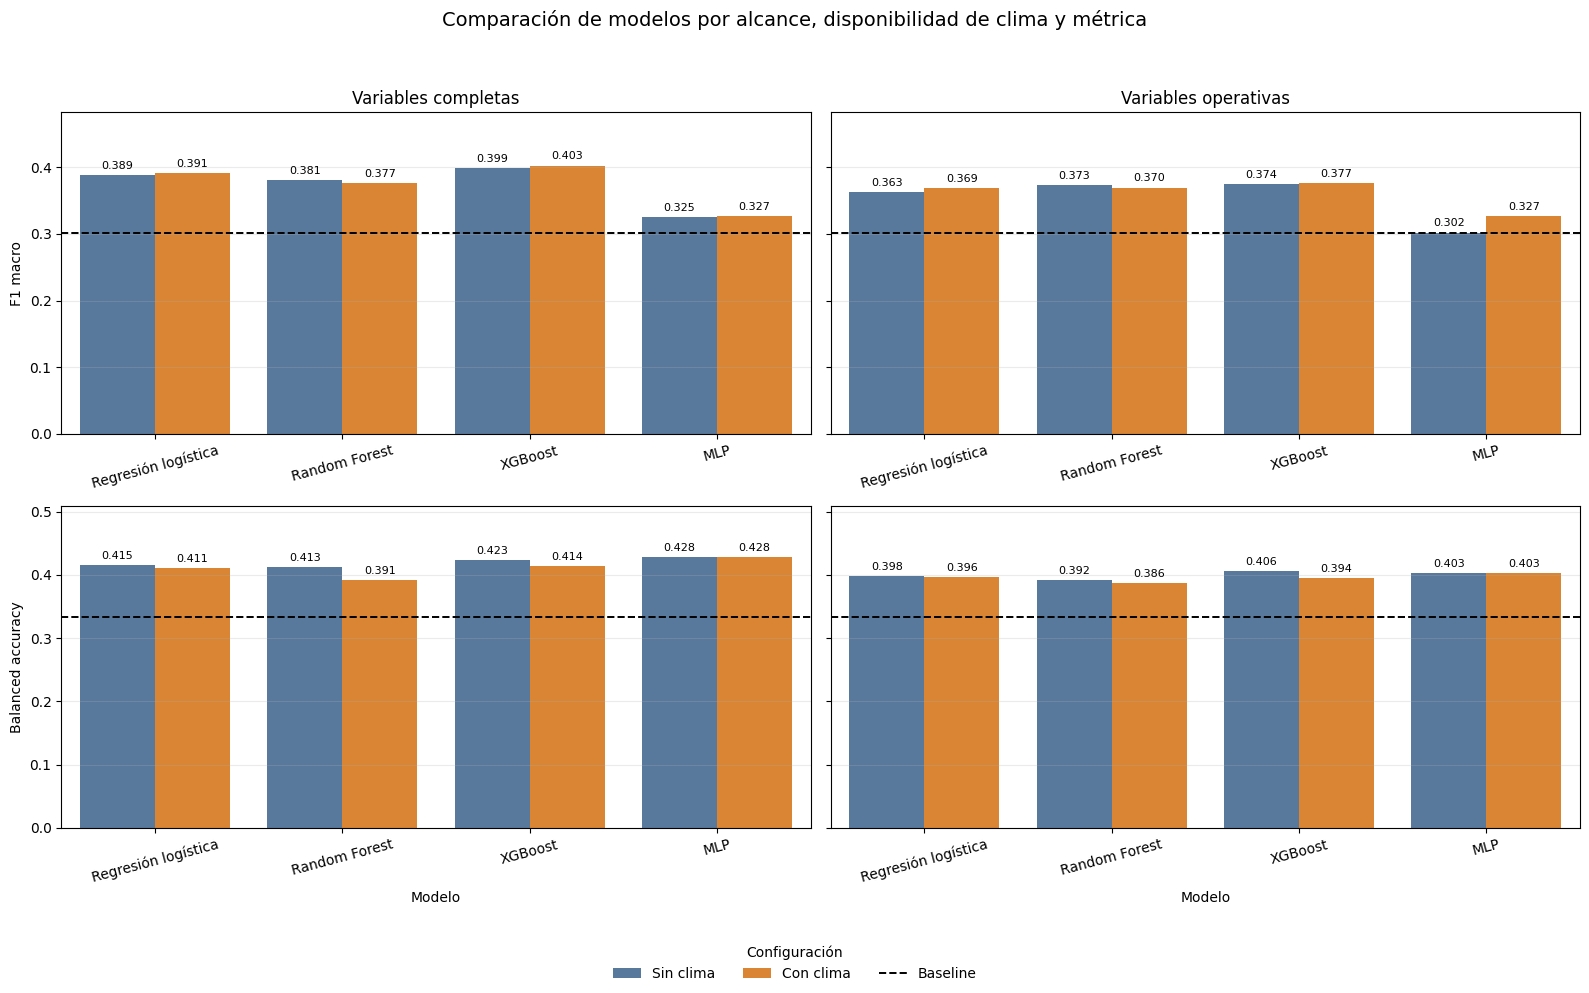

In [89]:
# Comparación visual separada por alcance, clima y métrica
comparacion_grafica = candidatos.copy()
comparacion_grafica['MODELO_GRAFICA'] = comparacion_grafica['MODELO'].replace({
    'REGRESION_LOGISTICA': 'Regresión logística',
    'RANDOM_FOREST': 'Random Forest',
    'XGBOOST': 'XGBoost',
    'MLP': 'MLP'
})
comparacion_grafica['CLIMA_GRAFICA'] = comparacion_grafica['CLIMA'].replace({
    'SIN_CLIMA': 'Sin clima',
    'CON_CLIMA': 'Con clima'
})

orden_modelos = [
    modelo for modelo in ['Regresión logística', 'Random Forest', 'XGBoost', 'MLP']
    if modelo in comparacion_grafica['MODELO_GRAFICA'].unique()
]
orden_clima = ['Sin clima', 'Con clima']
paleta_clima = {'Sin clima': '#4C78A8', 'Con clima': '#F58518'}

alcances_grafica = [
    ('COMPLETO', 'Variables completas'),
    ('OPERATIVO', 'Variables operativas')
]
metricas_grafica = [
    ('F1_macro', 'F1 macro'),
    ('Balanced_Accuracy', 'Balanced accuracy')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row')

for fila, (metrica, etiqueta_metrica) in enumerate(metricas_grafica):
    limite_superior = min(1.0, comparacion_grafica[metrica].max() + 0.08)

    for columna, (alcance, titulo_alcance) in enumerate(alcances_grafica):
        ax = axes[fila, columna]
        datos_panel = comparacion_grafica.query('ALCANCE == @alcance')

        sns.barplot(
            data=datos_panel,
            x='MODELO_GRAFICA',
            y=metrica,
            hue='CLIMA_GRAFICA',
            order=orden_modelos,
            hue_order=orden_clima,
            palette=paleta_clima,
            errorbar=None,
            ax=ax
        )
        ax.axhline(
            metricas_baseline[metrica],
            color='black',
            linestyle='--',
            linewidth=1.4,
            label='Baseline'
        )
        if fila == 0:
            ax.set_title(titulo_alcance)
        ax.set_xlabel('Modelo' if fila == 1 else '')
        ax.set_ylabel(etiqueta_metrica if columna == 0 else '')
        ax.set_ylim(0, limite_superior)
        ax.tick_params(axis='x', rotation=15)
        ax.grid(axis='y', alpha=0.25)

        for contenedor in ax.containers:
            ax.bar_label(contenedor, fmt='%.3f', padding=3, fontsize=8)

handles, etiquetas = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    leyenda = ax.get_legend()
    if leyenda is not None:
        leyenda.remove()

fig.legend(
    handles,
    etiquetas,
    title='Configuración',
    loc='lower center',
    ncol=3,
    frameon=False
)
fig.suptitle(
    'Comparación de modelos por alcance, disponibilidad de clima y métrica',
    fontsize=14
)
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()


#### Comparación global de los modelos

Todos los modelos, excepto algunas configuraciones de MLP, superan la línea base en `F1_macro` y `Balanced_Accuracy`. La `Accuracy` de la línea base alcanza **0,8267**, pero este valor está determinado principalmente por el predominio de `CHOQUE`; su `Balanced_Accuracy = 0,3333` y `F1_macro = 0,3017` evidencian que no existe una capacidad real para distinguir equilibradamente las tres clases.

XGBoost presenta el mejor desempeño global. En el escenario completo con clima obtiene `F1_macro = 0,4026`, aproximadamente **33,4 % superior** a la línea base, mientras que en el escenario operativo con clima alcanza **0,3767**, una mejora cercana al **24,8 %** frente a la misma referencia. Regresión logística y Random Forest presentan resultados próximos en el escenario operativo, pero permanecen ligeramente por debajo de XGBoost. MLP muestra el menor `F1_macro` y no resulta competitivo para la selección final.

La reducción desde el mejor escenario completo (`0,4026`) hasta el mejor operativo (`0,3767`) es de aproximadamente **6,4 %**. Esto indica que las variables excluidas del diseño operativo contienen información predictiva adicional, aunque el modelo conserva parte importante de su capacidad al limitarse a variables disponibles durante una consulta real.

El aporte del clima es reducido. En XGBoost, el `F1_macro` aumenta de **0,3988 a 0,4026** en el escenario completo y de **0,3742 a 0,3767** en el operativo, equivalentes a mejoras relativas inferiores al **1 %**. Además, la `Balanced_Accuracy` disminuye al incorporar clima en ambos alcances. Por tanto, aunque las variables meteorológicas mejoran algunas métricas probabilísticas como `Log_Loss` y `Brier_multiclase`, no producen una mejora consistente en las métricas principales de clasificación.

De acuerdo con el criterio definido, XGBoost constituye la familia candidata para la etapa final. La decisión entre el escenario operativo con y sin clima no debe basarse únicamente en la pequeña diferencia de `F1_macro`; se complementará con el bootstrap pareado para determinar si el aporte meteorológico es suficientemente consistente como para justificar su inclusión.

In [90]:
# Elegir un ganador completo y uno operativo sin consultar prueba
ganadores_alcance = (
    candidatos
    .sort_values(
        ['F1_macro', 'Balanced_Accuracy', 'Log_Loss'],
        ascending=[False, False, True]
    )
    .groupby('ALCANCE', as_index=False)
    .first()
)

display(ganadores_alcance.drop(columns=['ALCANCE', 'CLIMA']))

,MODELO,ESCENARIO,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,XGBOOST,COMPLETO_CON_CLIMA,9.191294,0.719693,0.413563,0.402606,0.728019,0.392312,0.629305,0.806304,0.462897,0.194751
1,XGBOOST,OPERATIVO_CON_CLIMA,7.454253,0.741267,0.394413,0.376657,0.735146,0.380406,0.607117,0.792896,0.451535,0.212987


In [91]:
# Guardar la configuración ganadora de cada alcance
GANADORES = {}

for _, fila in ganadores_alcance.iterrows():

    alcance = fila['ALCANCE']

    GANADORES[alcance] = {
        'modelo': fila['MODELO'],
        'escenario': fila['ESCENARIO'],
        'parametros': mejores_parametros[
            (fila['MODELO'], alcance)
        ]
    }

In [92]:
# Mostrar ganadores seleccionados

for alcance, ganador in GANADORES.items():

    print(f'\n{alcance}')
    print(f"Modelo: {ganador['modelo']}")
    print(f"Escenario: {ganador['escenario']}")
    print(f"Parámetros: {ganador['parametros']}")


COMPLETO
Modelo: XGBOOST
Escenario: COMPLETO_CON_CLIMA
Parámetros: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}

OPERATIVO
Modelo: XGBOOST
Escenario: OPERATIVO_CON_CLIMA
Parámetros: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


In [93]:
# El escenario operativo dirige los diagnósticos y el backtesting

NOMBRE_GANADOR = GANADORES['OPERATIVO']['modelo']
ESCENARIO_GANADOR = GANADORES['OPERATIVO']['escenario']
PARAMETROS_GANADOR = GANADORES['OPERATIVO']['parametros']

print(f'Modelo operativo ganador: {NOMBRE_GANADOR}')
print(f'Escenario: {ESCENARIO_GANADOR}')
print(f'Parámetros: {PARAMETROS_GANADOR}')

Modelo operativo ganador: XGBOOST
Escenario: OPERATIVO_CON_CLIMA
Parámetros: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.08, 'min_child_weight': 10, 'potencia_peso': 0.75}


## 9. Incertidumbre en las diferencias entre escenarios

Con el fin de determinar si las diferencias observadas entre escenarios son consistentes o pueden atribuirse a variación muestral, se aplica un bootstrap pareado y estratificado sobre el conjunto de validación.

El análisis se utiliza para evaluar dos comparaciones principales: la diferencia entre los escenarios completo y operativo, y el efecto de incorporar variables meteorológicas dentro del escenario operativo. En cada réplica, ambos modelos se evalúan sobre las mismas observaciones remuestreadas y se estiman las diferencias en `F1_macro`, `Balanced_Accuracy` y `Log_Loss`, junto con intervalos de confianza del 95 %.

Los deltas se definen de manera que valores positivos representan una mejora de la alternativa evaluada. Cuando el intervalo de confianza incluye cero, la diferencia se considera insuficiente para afirmar una mejora consistente en validación.

In [94]:
# Funciones ligeras para el bootstrap estratificado
def indices_bootstrap_estratificado(y, rng): # Función auxiliar para generar índices de bootstrap estratificado
    return np.concatenate([
        rng.choice(indices_clase, size=len(indices_clase), replace=True)
        for indices_clase in (
            np.flatnonzero(y == clase) for clase in np.unique(y)
        )
    ])

def calcular_metricas_bootstrap(y_real, probabilidades): # Función auxiliar para calcular métricas de evaluación a partir de etiquetas reales y probabilidades predichas
    # El punto 9 solo necesita estas tres métricas. Evitar aquí ROC-AUC,
    # PR-AUC, Brier y calibración reduce considerablemente el tiempo.
    numero_clases = len(clases_codificadas)
    indices_reales = np.searchsorted(clases_codificadas, y_real)
    indices_predichos = np.argmax(probabilidades, axis=1)

    matriz = np.bincount(
        indices_reales * numero_clases + indices_predichos,
        minlength=numero_clases ** 2
    ).reshape(numero_clases, numero_clases)

    verdaderos_positivos = np.diag(matriz).astype(float)
    reales_por_clase = matriz.sum(axis=1)
    predichos_por_clase = matriz.sum(axis=0)

    recall = np.divide(
        verdaderos_positivos,
        reales_por_clase,
        out=np.zeros(numero_clases, dtype=float),
        where=reales_por_clase > 0
    )
    precision = np.divide(
        verdaderos_positivos,
        predichos_por_clase,
        out=np.zeros(numero_clases, dtype=float),
        where=predichos_por_clase > 0
    )
    f1_por_clase = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros(numero_clases, dtype=float),
        where=(precision + recall) > 0
    )

    probabilidad_clase_real = probabilidades[
        np.arange(len(y_real)), indices_reales
    ]

    return {
        'F1_macro': f1_por_clase.mean(),
        'Balanced_Accuracy': recall.mean(),
        'Log_Loss': -np.log(
            np.clip(probabilidad_clase_real, 1e-15, 1.0)
        ).mean()
    }

# Función principal para calcular intervalos de confianza del delta entre dos modelos
def bootstrap_delta(y, proba_base, proba_alternativa, repeticiones=250, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    indices_por_clase = [
        np.flatnonzero(y == clase) for clase in np.unique(y)
    ]
    registros = []

    for _ in range(repeticiones):
        indices = np.concatenate([
            rng.choice(indices_clase, size=len(indices_clase), replace=True)
            for indices_clase in indices_por_clase
        ])
        m_base = calcular_metricas_bootstrap(
            y[indices], proba_base[indices]
        )
        m_alt = calcular_metricas_bootstrap(
            y[indices], proba_alternativa[indices]
        )
        registros.append({
            'F1_macro': m_alt['F1_macro'] - m_base['F1_macro'],
            'Balanced_Accuracy': (
                m_alt['Balanced_Accuracy'] - m_base['Balanced_Accuracy']
            ),
            'Log_Loss': m_base['Log_Loss'] - m_alt['Log_Loss'],
        })

    muestras = pd.DataFrame(registros)
    return pd.DataFrame({
        'DELTA_PROMEDIO': muestras.mean(),
        'IC95_INFERIOR': muestras.quantile(0.025),
        'IC95_SUPERIOR': muestras.quantile(0.975)
    })


In [95]:
# Comparación de escenarios completo y operativo para el modelo ganador
g_completo = GANADORES['COMPLETO']
g_operativo = GANADORES['OPERATIVO']
proba_completo_val = probabilidades_validacion[(g_completo['modelo'], g_completo['escenario'])]
proba_operativo_val = probabilidades_validacion[(g_operativo['modelo'], g_operativo['escenario'])]

# Positivo significa que agregar las variables no disponibles mejora
impacto_variables = bootstrap_delta(y_val, proba_operativo_val, proba_completo_val)
display(impacto_variables)

,DELTA_PROMEDIO,IC95_INFERIOR,IC95_SUPERIOR
F1_macro,0.025860,0.021298,0.030057
Balanced_Accuracy,0.018933,0.014972,0.022505
Log_Loss,-0.013433,-0.014466,-0.012360


In [96]:
# Comparación climática dentro del mismo modelo y alcance operativo
escenario_op_con = 'OPERATIVO_CON_CLIMA'
escenario_op_sin = 'OPERATIVO_SIN_CLIMA'
proba_op_con = probabilidades_validacion[(NOMBRE_GANADOR, escenario_op_con)]
proba_op_sin = probabilidades_validacion[(NOMBRE_GANADOR, escenario_op_sin)]
impacto_clima_operativo = bootstrap_delta(y_val, proba_op_sin, proba_op_con)
display(impacto_clima_operativo)

,DELTA_PROMEDIO,IC95_INFERIOR,IC95_SUPERIOR
F1_macro,0.002425,-0.000434,0.005337
Balanced_Accuracy,-0.011067,-0.013605,-0.008247
Log_Loss,0.048707,0.048153,0.049358


#### Resultados del bootstrap pareado

La comparación entre los escenarios completo y operativo muestra que el escenario completo obtiene una mejora promedio de **0,0259** en `F1_macro` y de **0,0189** en `Balanced_Accuracy`. En ambos casos, los intervalos de confianza del 95 % permanecen completamente por encima de cero, lo que evidencia una ventaja consistente del conjunto completo en capacidad de clasificación.

Sin embargo, esta ventaja no se mantiene en `Log_Loss`. El delta promedio es de **-0,0134** y todo su intervalo de confianza permanece por debajo de cero, indicando que el escenario completo presenta un `Log_Loss` ligeramente mayor. Por tanto, las variables adicionales mejoran las decisiones de clasificación, pero no necesariamente la calidad de las probabilidades generadas por el modelo.

La comparación del clima dentro del escenario operativo presenta un resultado diferente. El incremento promedio de `F1_macro` al incorporar variables meteorológicas es de apenas **0,0024**, y su intervalo de confianza del 95 % va de **-0,0004 a 0,0053**, incluyendo cero. En consecuencia, no existe evidencia suficiente para afirmar que el clima mejore de forma consistente el `F1_macro`.

Además, la `Balanced_Accuracy` disminuye en promedio **0,0111** al incorporar clima, con un intervalo completamente por debajo de cero, lo que evidencia un deterioro consistente en la capacidad de reconocer equilibradamente las tres clases. En contraste, el `Log_Loss` mejora aproximadamente **0,0487**, con un intervalo completamente positivo, indicando una mejora estable en esta métrica probabilística.

En conjunto, el clima mejora el `Log_Loss`, pero no produce una mejora estadísticamente consistente en `F1_macro` y deteriora de manera consistente la `Balanced_Accuracy`. Dado que la selección del modelo prioriza `F1_macro` y `Balanced_Accuracy`, los resultados favorecen el escenario **`OPERATIVO_SIN_CLIMA`** para continuar hacia la evaluación final.

## 10. Backtesting temporal del modelo operativo seleccionado

Como diagnóstico adicional de estabilidad temporal, se evalúa el modelo operativo seleccionado en dos ventanas históricas anteriores al periodo utilizado para la selección final. En cada ventana se reajustan los parámetros del modelo utilizando únicamente observaciones disponibles hasta ese momento, manteniendo fija la configuración de hiperparámetros seleccionada previamente:

- entrenamiento hasta 2016 y evaluación en 2017–2018;
- entrenamiento hasta 2018 y evaluación en 2019–2020.

Se conserva la misma familia de modelo, escenario e hiperparámetros seleccionados previamente, de manera que el objetivo no es realizar una nueva búsqueda, sino comprobar si el diseño mantiene un desempeño similar al desplazarse en el tiempo. Este análisis funciona como una verificación retrospectiva de estabilidad y no sustituye la evaluación final sobre el conjunto de prueba 2024–2026.

In [97]:
VENTANAS_BACKTEST = [
    {'ENTRENA_HASTA': 2016, 'VALIDA_DESDE': 2017, 'VALIDA_HASTA': 2018},
    {'ENTRENA_HASTA': 2018, 'VALIDA_DESDE': 2019, 'VALIDA_HASTA': 2020},
]

resultados_backtest = []
for ventana in VENTANAS_BACKTEST:
    mascara_bt_train = datos_modelo['ANIO'] <= ventana['ENTRENA_HASTA']
    mascara_bt_val = datos_modelo['ANIO'].between(ventana['VALIDA_DESDE'], ventana['VALIDA_HASTA'])
    X_bt_train, y_bt_train = construir_xy(mascara_bt_train, ESCENARIO_GANADOR)
    X_bt_val, y_bt_val = construir_xy(mascara_bt_val, ESCENARIO_GANADOR)
    indices_bt = indices_muestra_ajuste(y_bt_train)
    modelo_bt, segundos = ajustar_modelo(
        NOMBRE_GANADOR, ESCENARIO_GANADOR, PARAMETROS_GANADOR,
        X_bt_train.iloc[indices_bt].reset_index(drop=True), y_bt_train[indices_bt]
    )
    proba_bt = ordenar_probabilidades(modelo_bt, X_bt_val, clases_codificadas)
    resultados_backtest.append({
        **ventana, 'FILAS_ENTRENAMIENTO': len(indices_bt),
        'FILAS_VALIDACION': len(y_bt_val), 'SEGUNDOS_AJUSTE': segundos,
        **calcular_metricas(y_bt_val, proba_bt),
    })

resultados_backtest = pd.DataFrame(resultados_backtest)
display(resultados_backtest)

,ENTRENA_HASTA,VALIDA_DESDE,VALIDA_HASTA,FILAS_ENTRENAMIENTO,FILAS_VALIDACION,SEGUNDOS_AJUSTE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,2016,2017,2018,300000,129966,8.310988,0.750058,0.401179,0.384884,0.764351,0.376668,0.617656,0.821690,0.471211,0.253937
1,2018,2019,2020,300000,107856,7.468523,0.756759,0.397106,0.371969,0.764536,0.376662,0.619171,0.757149,0.426924,0.215545


#### Resultados del backtesting temporal

El modelo operativo mantiene un comportamiento relativamente estable en las dos ventanas históricas evaluadas. El `F1_macro` pasa de **0,3849** en 2017–2018 a **0,3720** en 2019–2020, lo que representa una reducción relativa aproximada de **3,36 %**. La `Balanced_Accuracy` presenta una variación menor, de **0,4012** a **0,3971**, mientras que la `Accuracy` permanece prácticamente estable alrededor de **0,75**.

Las métricas probabilísticas muestran incluso una mejora en la segunda ventana: el `Log_Loss` disminuye de **0,8217** a **0,7571**, el `Brier_multiclase` de **0,4712** a **0,4269** y el `ECE` de **0,2539** a **0,2155**. El `ROC_AUC_OVR_macro` también se mantiene estable, cercano a **0,62**.

En conjunto, no se observa un deterioro abrupto del modelo al desplazar la ventana temporal. Aunque el `F1_macro` disminuye ligeramente en 2019–2020, las demás métricas permanecen estables o mejoran, por lo que el backtesting aporta una señal favorable de estabilidad histórica. La capacidad de generalización hacia periodos más recientes deberá confirmarse posteriormente en la prueba temporal 2024–2026.

## 11. Reajuste final y evaluación sobre prueba no utilizada

Una vez cerrada la selección con validación, los diseños ganadores de los alcances completo y operativo se reajustan con la información disponible entre 2007 y 2023. Para mantener un costo computacional razonable, se utiliza una muestra común, aleatoria y reproducible de hasta **600.000 accidentes**, conservando la distribución de las clases.

La misma muestra se utiliza para ambos alcances y la línea base se reconstruye con esta información. El periodo **2024–2026** permanece excluido de la selección, el ajuste de hiperparámetros, el bootstrap y el backtesting, y se utiliza únicamente para estimar el desempeño final.

In [98]:
# Preparar el modelo final para producción y backtesting
mascara_desarrollo = datos_modelo['ANIO'] <= ANIO_FIN_VALIDACION
resultados_test = []
modelos_finales = {}
probabilidades_finales = {}

# Construir una muestra final común para evitar reajustes prohibitivos
_, y_desarrollo_referencia = construir_xy(mascara_desarrollo, 'COMPLETO_CON_CLIMA')
indices_desarrollo = indices_muestra_ajuste(
    y_desarrollo_referencia, tamano=600_000, semilla=SEMILLA + 100
)
print(f'Muestra de reajuste final: {len(indices_desarrollo):,} de {len(y_desarrollo_referencia):,} accidentes')

Muestra de reajuste final: 600,000 de 862,830 accidentes


In [99]:
# Ajuste del baseline para la muestra de desarrollo
baseline_final = DummyClassifier(strategy='prior', random_state=SEMILLA)
baseline_final.fit(np.zeros((len(indices_desarrollo), 1)), y_desarrollo_referencia[indices_desarrollo])
proba_baseline_test = ordenar_probabilidades(baseline_final, np.zeros((mascara_test.sum(), 1)), clases_codificadas)
metricas_baseline_test = calcular_metricas(y_test, proba_baseline_test)
resultados_test.append({'ALCANCE': 'BASELINE', 'MODELO': 'BASELINE_PRIOR', 'ESCENARIO': 'SIN_PREDICTORES', **metricas_baseline_test})

for alcance in ['COMPLETO', 'OPERATIVO']:
    ganador = GANADORES[alcance]
    X_desarrollo_alcance, y_desarrollo = construir_xy(mascara_desarrollo, ganador['escenario'])
    X_test_alcance, _ = construir_xy(mascara_test, ganador['escenario'])
    X_reajuste = X_desarrollo_alcance.iloc[indices_desarrollo].reset_index(drop=True)
    y_reajuste = y_desarrollo[indices_desarrollo]
    print(f'Reajustando {alcance}: {ganador["modelo"]} / {ganador["escenario"]} con {len(y_reajuste):,} registros...')
    modelo, segundos = ajustar_modelo(
        ganador['modelo'], ganador['escenario'], ganador['parametros'],
        X_reajuste, y_reajuste
    )
    proba = ordenar_probabilidades(modelo, X_test_alcance, clases_codificadas)
    modelos_finales[alcance] = modelo
    probabilidades_finales[alcance] = proba
    resultados_test.append({
        'ALCANCE': alcance, 'MODELO': ganador['modelo'], 'ESCENARIO': ganador['escenario'],
        'SEGUNDOS_AJUSTE': segundos, **calcular_metricas(y_test, proba)
    })

comparacion_test = pd.DataFrame(resultados_test)
display(comparacion_test)

Reajustando COMPLETO: XGBOOST / COMPLETO_CON_CLIMA con 600,000 registros...
Reajustando OPERATIVO: XGBOOST / OPERATIVO_CON_CLIMA con 600,000 registros...


,ALCANCE,MODELO,ESCENARIO,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins,SEGUNDOS_AJUSTE
0,BASELINE,BASELINE_PRIOR,SIN_PREDICTORES,0.704293,0.333333,0.275498,0.582093,0.333333,0.500000,0.839191,0.480114,0.130374,NaN
1,COMPLETO,XGBOOST,COMPLETO_CON_CLIMA,0.618463,0.400765,0.397063,0.608748,0.390252,0.589253,0.916925,0.541916,0.119887,20.480346
2,OPERATIVO,XGBOOST,OPERATIVO_CON_CLIMA,0.636268,0.387133,0.373461,0.612027,0.380003,0.571885,0.905850,0.532315,0.135816,15.229533


In [100]:
# Variables de referencia para el diagnóstico del modelo operativo
modelo_final = modelos_finales['OPERATIVO']
probabilidades_test = probabilidades_finales['OPERATIVO']
prediccion_test = clases_codificadas[np.argmax(probabilidades_test, axis=1)]
metricas_test = calcular_metricas(y_test, probabilidades_test)
X_desarrollo_completo, y_desarrollo = construir_xy(mascara_desarrollo, ESCENARIO_GANADOR)
X_desarrollo = X_desarrollo_completo.iloc[indices_desarrollo].reset_index(drop=True)
X_test, _ = construir_xy(mascara_test, ESCENARIO_GANADOR)

In [101]:
# Intervalos de confianza del 95 % mediante bootstrap estratificado
def bootstrap_metricas(y, probabilidades, repeticiones=300, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    registros = []
    for _ in range(repeticiones):
        indices = indices_bootstrap_estratificado(y, rng)
        registros.append(calcular_metricas(y[indices], probabilidades[indices]))
    muestras = pd.DataFrame(registros)
    return pd.DataFrame({
        'ESTIMACION_TEST': pd.Series(metricas_test),
        'IC95_INFERIOR': muestras.quantile(0.025),
        'IC95_SUPERIOR': muestras.quantile(0.975),
    })

intervalos_test = bootstrap_metricas(y_test, probabilidades_test)
display(intervalos_test)

,ESTIMACION_TEST,IC95_INFERIOR,IC95_SUPERIOR
Accuracy,0.636268,0.631861,0.640120
Balanced_Accuracy,0.387133,0.382825,0.390988
F1_macro,0.373461,0.368912,0.377482
F1_weighted,0.612027,0.608139,0.615426
PR_AUC_macro,0.380003,0.376689,0.384277
ROC_AUC_OVR_macro,0.571885,0.566525,0.577501
Log_Loss,0.905850,0.903295,0.908548
Brier_multiclase,0.532315,0.530464,0.534261
ECE_10_bins,0.135816,0.131501,0.139528


### Resultados en el conjunto de prueba

La evaluación sobre el periodo 2024–2026 confirma que XGBoost mantiene un desempeño similar al observado durante la validación. En el escenario operativo se obtiene un `F1_macro` de **0,3735** y una `Balanced_Accuracy` de **0,3871**, valores cercanos a los obtenidos previamente, lo que indica que no se produce un deterioro abrupto al avanzar hacia observaciones futuras.

El escenario completo presenta un mejor desempeño balanceado, con `F1_macro = 0,3971` y `Balanced_Accuracy = 0,4008`, confirmando que las variables adicionales contienen información útil para distinguir las clases. Sin embargo, estas variables no necesariamente están disponibles durante una consulta real, por lo que el escenario operativo continúa siendo la referencia relevante para la implementación.

Ambos modelos superan ampliamente la línea base en las métricas que consideran de manera equilibrada las tres clases. El `F1_macro` operativo alcanza **0,3735**, frente a **0,2755** de la línea base, una mejora relativa aproximada de **35,6 %**. De igual forma, la `Balanced_Accuracy` aumenta de **0,3333** a **0,3871**.

Los intervalos de confianza del 95 % del modelo operativo son estrechos: el `F1_macro` se encuentra entre **0,3689 y 0,3775**, y la `Balanced_Accuracy` entre **0,3828 y 0,3910**. Esto indica que la estimación sobre el conjunto de prueba es estable, aunque el nivel de desempeño continúa siendo moderado.

Las métricas probabilísticas requieren una interpretación más cautelosa. Aunque el modelo mejora frente a la línea base en `PR_AUC_macro` y `ROC_AUC_OVR_macro`, presenta un `Log_Loss` y un `Brier_multiclase` superiores a los de la línea base. Esto indica que las probabilidades predichas todavía no representan adecuadamente la incertidumbre del problema, especialmente ante el cambio temporal observado en la distribución de las clases.

En conjunto, el modelo aporta capacidad predictiva para diferenciar `ATROPELLO`, `CHOQUE` y `OTROS`, pero su principal fortaleza se encuentra en la clasificación relativa y no todavía en la estimación de probabilidades perfectamente calibradas. El diagnóstico por clase será necesario para determinar en qué categorías se concentra la capacidad predictiva y cuáles continúan siendo las principales fuentes de error.

## 12. Diagnóstico por clase y análisis de errores

La evaluación global se complementa con métricas específicas por clase y una matriz de confusión normalizada. Este análisis permite identificar en cuáles categorías el modelo operativo presenta mayor capacidad de reconocimiento y dónde se concentran sus errores, aspecto especialmente relevante por el predominio de `CHOQUE` y la heterogeneidad de `OTROS`.

In [102]:
# Diagnóstico de la predicción final sobre la muestra de prueba
nombres_clases = encoder_objetivo.classes_.tolist()
reporte_clases = pd.DataFrame(classification_report(
    y_test, prediccion_test, labels=clases_codificadas,
    target_names=nombres_clases, output_dict=True, zero_division=0
)).T
display(reporte_clases)

,precision,recall,f1-score,support
ATROPELLO,0.315768,0.353493,0.333568,6713.000000
CHOQUE,0.740574,0.797622,0.768040,22705.000000
OTROS,0.107807,0.010284,0.018776,2820.000000
accuracy,0.636268,0.636268,0.636268,0.636268
macro avg,0.388050,0.387133,0.373461,32238.000000
weighted avg,0.596765,0.636268,0.612027,32238.000000


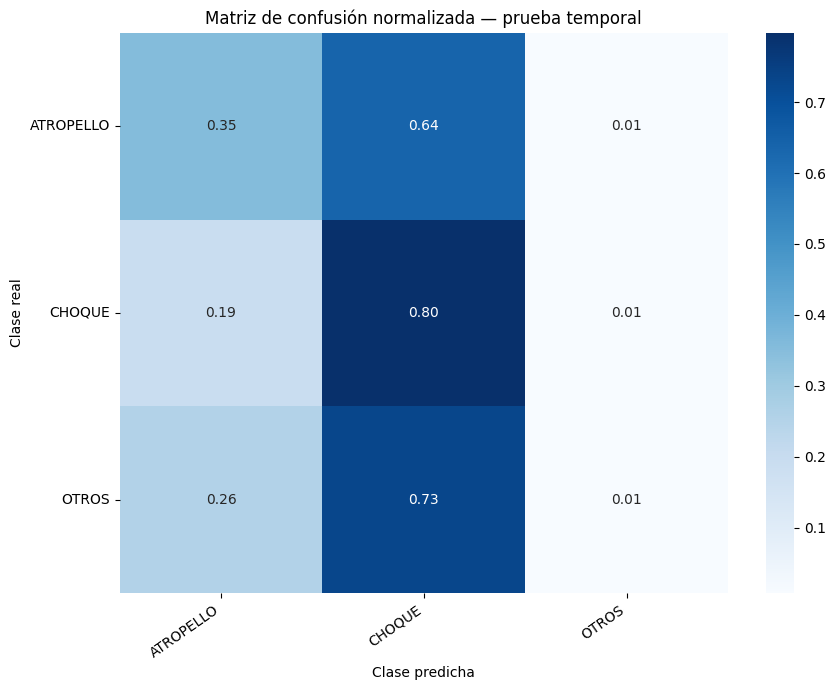

In [103]:
# Visualización de la matriz de confusión normalizada
matriz = confusion_matrix(y_test, prediccion_test, labels=clases_codificadas, normalize='true')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases, ax=ax)
ax.set_title('Matriz de confusión normalizada — prueba temporal')
ax.set_xlabel('Clase predicha')
ax.set_ylabel('Clase real')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Análisis por clase

La matriz de confusión muestra que el modelo identifica correctamente cerca del **80 %** de los `CHOQUE`, pero presenta mayores dificultades con las clases minoritarias. Solo alrededor del **35 %** de los `ATROPELLO` se clasifican correctamente y `OTROS` prácticamente no se reconoce como clase propia.

El principal error consiste en clasificar `ATROPELLO` y `OTROS` como `CHOQUE`, lo que confirma que el desbalance continúa afectando la capacidad del modelo para diferenciar las tres categorías.

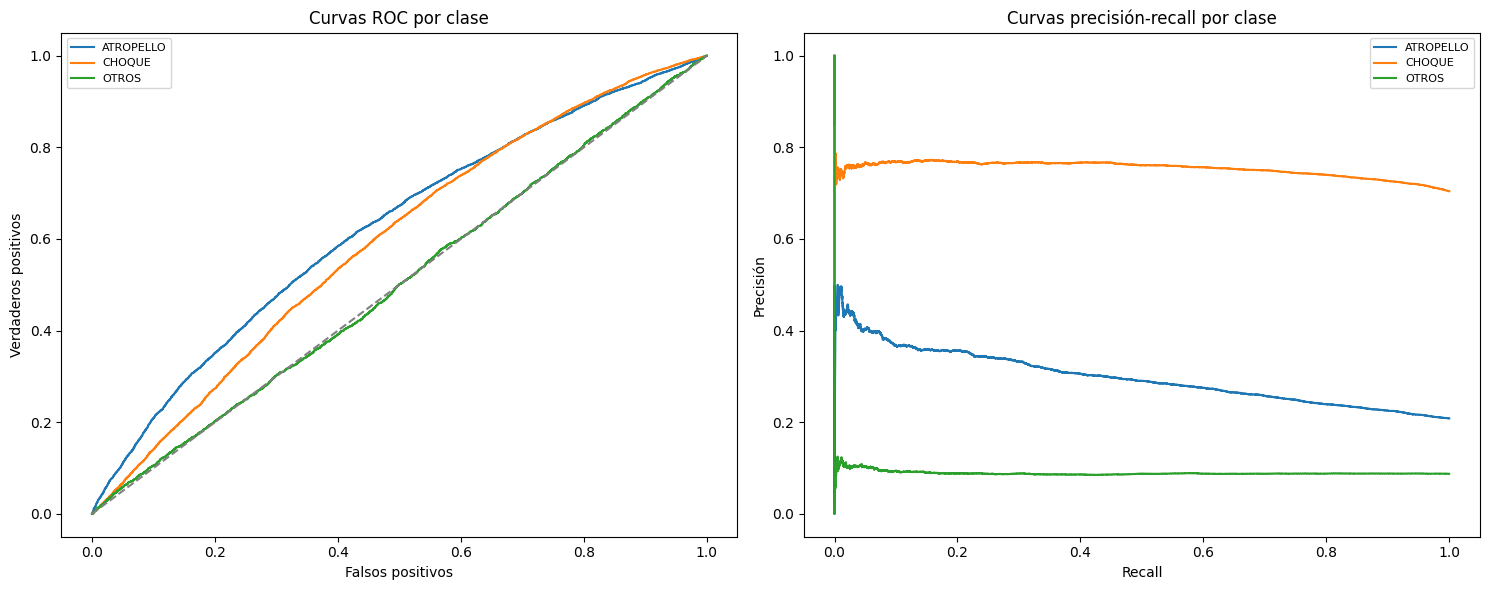

In [104]:
# Curvas ROC y precisión-recall uno contra el resto
y_test_bin = LabelBinarizer().fit(clases_codificadas).transform(y_test)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for posicion, nombre_clase in enumerate(nombres_clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, posicion], probabilidades_test[:, posicion])
    precision, recall, _ = precision_recall_curve(y_test_bin[:, posicion], probabilidades_test[:, posicion])
    axes[0].plot(fpr, tpr, label=nombre_clase)
    axes[1].plot(recall, precision, label=nombre_clase)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(title='Curvas ROC por clase', xlabel='Falsos positivos', ylabel='Verdaderos positivos')
axes[1].set(title='Curvas precisión-recall por clase', xlabel='Recall', ylabel='Precisión')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Curvas ROC y precisión-recall

Las curvas confirman que la capacidad de discriminación es limitada. `ATROPELLO` presenta una separación moderada respecto al azar, mientras que `CHOQUE` mantiene el mejor desempeño por su mayor representación. `OTROS`, en cambio, permanece muy cerca del comportamiento aleatorio.

Las curvas precisión-recall muestran con mayor claridad el efecto del desbalance: `CHOQUE` conserva una precisión alta, `ATROPELLO` presenta un desempeño intermedio y `OTROS` mantiene una precisión muy baja. Esto confirma que la principal limitación del modelo continúa siendo la identificación de la clase `OTROS`.

In [105]:
# Estabilidad por año dentro del periodo de prueba
anios_test = datos_modelo.loc[mascara_test, 'ANIO'].reset_index(drop=True)
metricas_por_anio = []
for anio in sorted(anios_test.unique()):
    mascara_anio = anios_test.eq(anio).to_numpy()
    metricas_anio = calcular_metricas(y_test[mascara_anio], probabilidades_test[mascara_anio])
    metricas_por_anio.append({'ANIO': int(anio), 'FILAS': int(mascara_anio.sum()), **metricas_anio})
metricas_por_anio = pd.DataFrame(metricas_por_anio)
display(metricas_por_anio)

,ANIO,FILAS,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins
0,2024,13798,0.636469,0.387067,0.372276,0.612101,0.378663,0.569386,0.906588,0.533131,0.135548
1,2025,12192,0.635499,0.386278,0.372058,0.609441,0.380461,0.570043,0.905286,0.531863,0.134077
2,2026,6248,0.637324,0.389139,0.378793,0.616894,0.384354,0.582036,0.905319,0.531395,0.139920


### Estabilidad anual en el periodo de prueba

El desempeño del modelo se mantiene estable entre 2024 y 2026. El `F1_macro` permanece alrededor de **0,37–0,38** y la `Balanced_Accuracy` cerca de **0,39**, sin evidenciar un deterioro progresivo.

Las métricas probabilísticas también presentan poca variación entre años. En conjunto, los resultados sugieren estabilidad temporal dentro del periodo de prueba. Los valores de 2026 deben interpretarse con cautela, ya que corresponden a un periodo parcial y contienen menos observaciones.

In [106]:
# Confiabilidad de la probabilidad máxima
confianza = probabilidades_test.max(axis=1)
acierto = (prediccion_test == y_test).astype(int)
bins = pd.cut(confianza, bins=np.linspace(0, 1, 11), include_lowest=True)
tabla_calibracion = (
    pd.DataFrame({'BIN': bins, 'CONFIANZA': confianza, 'ACIERTO': acierto})
    .groupby('BIN', observed=False)
    .agg(CASOS=('ACIERTO', 'size'), CONFIANZA_MEDIA=('CONFIANZA', 'mean'), EXACTITUD=('ACIERTO', 'mean'))
    .reset_index()
)
display(tabla_calibracion)

,BIN,CASOS,CONFIANZA_MEDIA,EXACTITUD
0,"(-0.001, 0.1]",0,NaN,NaN
1,"(0.1, 0.2]",0,NaN,NaN
2,"(0.2, 0.3]",0,NaN,NaN
3,"(0.3, 0.4]",3904,0.381187,0.462346
4,"(0.4, 0.5]",13807,0.447442,0.581517
5,"(0.5, 0.6]",9312,0.546551,0.717139
6,"(0.6, 0.7]",4659,0.638554,0.768620
7,"(0.7, 0.8]",552,0.725210,0.753623
8,"(0.8, 0.9]",4,0.809165,0.750000
9,"(0.9, 1.0]",0,NaN,NaN


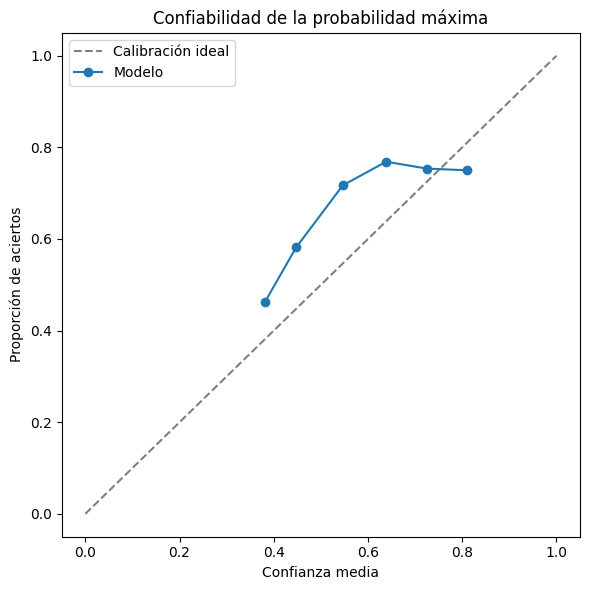

In [107]:
# Visualización de la confiabilidad de la probabilidad máxima
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibración ideal')
ax.plot(tabla_calibracion['CONFIANZA_MEDIA'], tabla_calibracion['EXACTITUD'], marker='o', label='Modelo')
ax.set(title='Confiabilidad de la probabilidad máxima', xlabel='Confianza media', ylabel='Proporción de aciertos')
ax.legend()
plt.tight_layout()
plt.show()

### Confiabilidad de las probabilidades

La curva muestra que el modelo tiende a ser **conservador** en la mayor parte del rango: entre aproximadamente **0,38 y 0,64** de confianza, la exactitud observada es superior a la probabilidad asignada. Por ejemplo, con una confianza media cercana a **0,55**, la proporción de aciertos alcanza aproximadamente **0,72**.

En los niveles más altos de confianza la diferencia disminuye y aparece una ligera sobreconfianza. En conjunto, las probabilidades presentan una calibración imperfecta, por lo que conviene utilizarlas principalmente para comparar o ordenar resultados y no interpretarlas todavía como probabilidades exactas del tipo de accidente.

## 13. Experimento de sensibilidad: partición aleatoria por accidente

La evaluación temporal se mantiene como estimación principal porque simula la predicción sobre periodos futuros. Como contraste, se construye una partición aleatoria usando todos los años. La asignación se realiza por `ACCIDENTE_ID`, aunque la tabla ya contiene una fila por evento, para conservar el mismo criterio metodológico del notebook original.

Para aislar el efecto de la partición se mantiene el modelo operativo, sus variables y los hiperparámetros seleccionados con 2021–2023. `ANIO` continúa fuera de los predictores y el resultado aleatorio no se utiliza para cambiar el ganador.

In [108]:
# Construir una partición aleatoria por accidente comparable con la prueba temporal

fraccion_prueba_aleatoria = (
    datos_modelo.loc[mascara_test, 'ACCIDENTE_ID'].nunique()
    / datos_modelo['ACCIDENTE_ID'].nunique()
)

separador_aleatorio = GroupShuffleSplit(
    n_splits=1,
    test_size=fraccion_prueba_aleatoria,
    random_state=SEMILLA
)

indices_entrenamiento_aleatorio, indices_prueba_aleatoria = next(
    separador_aleatorio.split(
        datos_modelo,
        groups=datos_modelo['ACCIDENTE_ID'].to_numpy()
    )
)

mascara_entrenamiento_aleatorio = np.zeros(len(datos_modelo),dtype=bool)
mascara_prueba_aleatoria = np.zeros(len(datos_modelo), dtype=bool)
mascara_entrenamiento_aleatorio[indices_entrenamiento_aleatorio] = True
mascara_prueba_aleatoria[indices_prueba_aleatoria] = True

In [109]:
# Verificar que ningún accidente aparezca en ambas particiones

accidentes_entrenamiento_aleatorio = set(
    datos_modelo.loc[
        mascara_entrenamiento_aleatorio,
        'ACCIDENTE_ID'
    ]
)

accidentes_prueba_aleatoria = set(
    datos_modelo.loc[
        mascara_prueba_aleatoria,
        'ACCIDENTE_ID'
    ]
)

assert accidentes_entrenamiento_aleatorio.isdisjoint(accidentes_prueba_aleatoria)
assert (mascara_entrenamiento_aleatorio ^ mascara_prueba_aleatoria).all()

In [110]:
# Construir los conjuntos de entrenamiento y prueba aleatorios

X_entrenamiento_aleatorio, y_entrenamiento_aleatorio = construir_xy(
    mascara_entrenamiento_aleatorio,
    ESCENARIO_GANADOR
)

X_prueba_aleatoria, y_prueba_aleatoria = construir_xy(
    mascara_prueba_aleatoria,
    ESCENARIO_GANADOR
)


# Utilizar una muestra de ajuste del mismo tamaño que en el reajuste temporal
indices_ajuste_aleatorio = indices_muestra_ajuste(
    y_entrenamiento_aleatorio,
    tamano=len(indices_desarrollo),
    semilla=SEMILLA + 200
)


# Ajustar el mismo modelo e hiperparámetros seleccionados previamente
modelo_aleatorio, segundos_aleatorio = ajustar_modelo(
    NOMBRE_GANADOR,
    ESCENARIO_GANADOR,
    PARAMETROS_GANADOR,
    X_entrenamiento_aleatorio
        .iloc[indices_ajuste_aleatorio]
        .reset_index(drop=True),
    y_entrenamiento_aleatorio[indices_ajuste_aleatorio]
)


# Predicciones sobre la prueba aleatoria
probabilidades_aleatorias = ordenar_probabilidades(
    modelo_aleatorio,
    X_prueba_aleatoria,
    clases_codificadas
)

prediccion_aleatoria = clases_codificadas[
    np.argmax(probabilidades_aleatorias, axis=1)
]

metricas_aleatorias = calcular_metricas(
    y_prueba_aleatoria,
    probabilidades_aleatorias
)

In [111]:
# Construir una línea base específica para la partición aleatoria

baseline_aleatorio = DummyClassifier(strategy='prior', random_state=SEMILLA)

baseline_aleatorio.fit(
    np.zeros((len(indices_ajuste_aleatorio), 1)),
    y_entrenamiento_aleatorio[indices_ajuste_aleatorio]
)

probabilidades_baseline_aleatorio = ordenar_probabilidades(
    baseline_aleatorio,
    np.zeros((len(y_prueba_aleatoria), 1)),
    clases_codificadas
)

metricas_baseline_aleatorio = calcular_metricas(
    y_prueba_aleatoria,
    probabilidades_baseline_aleatorio
)

In [112]:
# Resumen de entrenamiento y prueba en la partición aleatoria

resumen_particion_aleatoria = []

for nombre, mascara, y_particion in [
    (
        'ENTRENAMIENTO_ALEATORIO',
        mascara_entrenamiento_aleatorio,
        y_entrenamiento_aleatorio
    ),
    (
        'PRUEBA_ALEATORIA',
        mascara_prueba_aleatoria,
        y_prueba_aleatoria
    )
]:

    resumen_particion_aleatoria.append({
        'PARTICION': nombre,
        'FILAS': int(mascara.sum()),
        'ACCIDENTES': datos_modelo.loc[
            mascara,
            'ACCIDENTE_ID'
        ].nunique(),
        'FECHA_MINIMA': datos_modelo.loc[
            mascara,
            'FECHA_HORA'
        ].min(),
        'FECHA_MAXIMA': datos_modelo.loc[
            mascara,
            'FECHA_HORA'
        ].max(),
        'CLASES_PRESENTES': len(
            np.unique(y_particion)
        )
    })

resumen_particion_aleatoria = pd.DataFrame(
    resumen_particion_aleatoria
)

display(resumen_particion_aleatoria)

,PARTICION,FILAS,ACCIDENTES,FECHA_MINIMA,FECHA_MAXIMA,CLASES_PRESENTES
0,ENTRENAMIENTO_ALEATORIO,862830,862830,2007-01-01 00:00:00,2026-08-13 00:50:00,3
1,PRUEBA_ALEATORIA,32238,32238,2007-01-01 14:10:00,2026-07-14 20:20:00,3


In [113]:
# Distribución de clases en la partición aleatoria

distribucion_aleatoria = pd.DataFrame({
    'ENTRENAMIENTO_ALEATORIO': pd.Series(
        y_entrenamiento_aleatorio
    ).value_counts(normalize=True),

    'PRUEBA_ALEATORIA': pd.Series(
        y_prueba_aleatoria
    ).value_counts(normalize=True)
})

distribucion_aleatoria = (
    distribucion_aleatoria
    .fillna(0)
    .reindex(clases_codificadas, fill_value=0)
)

distribucion_aleatoria.index = nombres_clases

display(
    (100 * distribucion_aleatoria).round(3)
)

,ENTRENAMIENTO_ALEATORIO,PRUEBA_ALEATORIA
ATROPELLO,11.743,12.054
CHOQUE,83.005,82.666
OTROS,5.252,5.279


In [114]:
# Comparar la evaluación temporal con la partición aleatoria por accidente

comparacion_particiones = pd.DataFrame([
    {
        'ESQUEMA': 'TEMPORAL_2024_2026',
        'FILAS_PRUEBA': len(y_test),
        'ACCIDENTES_PRUEBA': datos_modelo.loc[
            mascara_test,
            'ACCIDENTE_ID'
        ].nunique(),
        'F1_BASELINE': metricas_baseline_test['F1_macro'],
        **metricas_test
    },
    {
        'ESQUEMA': 'ALEATORIA_POR_ACCIDENTE',
        'FILAS_PRUEBA': len(y_prueba_aleatoria),
        'ACCIDENTES_PRUEBA': len(
            accidentes_prueba_aleatoria
        ),
        'F1_BASELINE': metricas_baseline_aleatorio[
            'F1_macro'
        ],
        **metricas_aleatorias
    }
])

comparacion_particiones['DELTA_F1_VS_BASELINE'] = (
    comparacion_particiones['F1_macro']
    - comparacion_particiones['F1_BASELINE']
)

display(
    comparacion_particiones.round(4)
)

,ESQUEMA,FILAS_PRUEBA,ACCIDENTES_PRUEBA,F1_BASELINE,Accuracy,Balanced_Accuracy,F1_macro,F1_weighted,PR_AUC_macro,ROC_AUC_OVR_macro,Log_Loss,Brier_multiclase,ECE_10_bins,DELTA_F1_VS_BASELINE
0,TEMPORAL_2024_2026,32238,32238,0.2755,0.6363,0.3871,0.3735,0.612,0.3800,0.5719,0.9058,0.5323,0.1358,0.0980
1,ALEATORIA_POR_ACCIDENTE,32238,32238,0.3017,0.7520,0.4184,0.4019,0.748,0.4109,0.6667,0.7866,0.4463,0.2277,0.1002


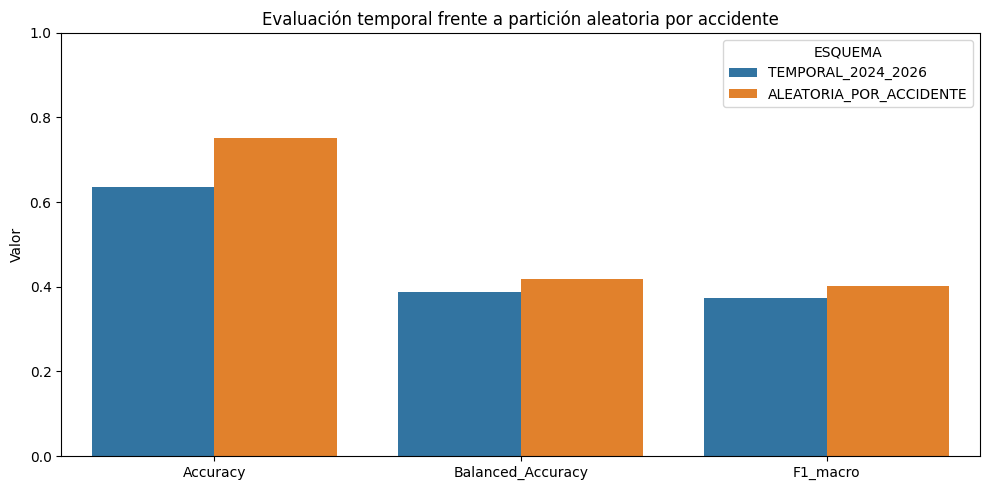

In [115]:
# Comparación gráfica de las métricas principales

metricas_grafico = comparacion_particiones.melt(
    id_vars='ESQUEMA',
    value_vars=[
        'Accuracy',
        'Balanced_Accuracy',
        'F1_macro'
    ],
    var_name='METRICA',
    value_name='VALOR'
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=metricas_grafico,
    x='METRICA',
    y='VALOR',
    hue='ESQUEMA',
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.set_ylabel('Valor')
ax.set_title(
    'Evaluación temporal frente a partición aleatoria por accidente'
)

plt.tight_layout()
plt.show()

### Comparación entre partición temporal y aleatoria

La partición aleatoria produce resultados más favorables que la evaluación temporal. El `F1_macro` aumenta de **0,3735** a **0,4019** y la `Balanced_Accuracy` de **0,3871** a **0,4184**, lo que confirma que mezclar observaciones de todo el periodo genera un escenario menos exigente.

Además, entrenamiento y prueba aleatorios conservan prácticamente la misma distribución de clases, mientras que la prueba temporal 2024–2026 presenta el cambio de prevalencias identificado previamente.

Sin embargo, la mejora frente a la línea base es muy similar en ambos esquemas (`+0,0980` temporal y `+0,1002` aleatorio). Por tanto, el modelo mantiene capacidad predictiva bajo ambas particiones, pero la evaluación temporal se conserva como referencia principal porque representa mejor la generalización hacia accidentes futuros.

### Conclusión del modelo de clase de accidente

El modelo demuestra que existe señal predictiva asociada principalmente a la ubicación y, en menor medida, al momento del accidente. Sin embargo, su capacidad para diferenciar las tres clases continúa siendo limitada. En la prueba temporal, el modelo alcanza un `F1_macro` cercano a **0,37** y una `Balanced_Accuracy` cercana a **0,39**, con dificultades especialmente marcadas para identificar `OTROS` y una proporción importante de `ATROPELLO` clasificados como `CHOQUE`.

Aunque los resultados superan la línea base y muestran estabilidad temporal, el desempeño no se considera suficiente para utilizar la clase de accidente como una predicción operativa dentro de PrediRuta. Por esta razón, este modelo se conserva como resultado experimental y de análisis, pero no se incorpora al flujo productivo del MVP.

## 14. Importancia de variables operativas

Para interpretar el comportamiento del modelo operativo se calcula la importancia por permutación sobre una muestra de la prueba temporal. La técnica mide cuánto disminuye el F1 macro al desordenar cada variable. Una caída mayor indica que el modelo depende más de esa entrada para distinguir la clase del accidente.

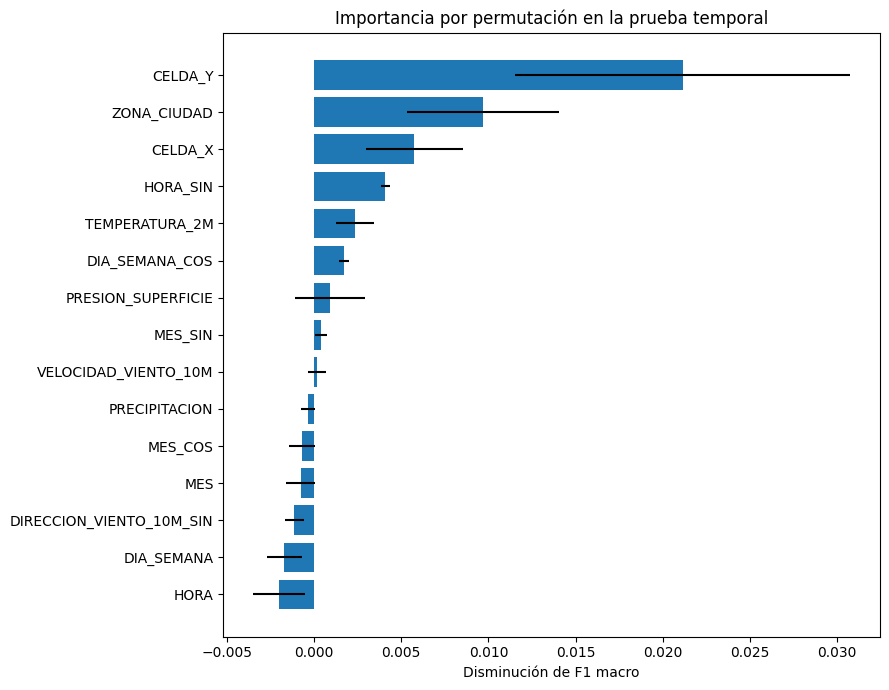

In [116]:
# Importancia por permutación sobre columnas de entrada, usando una muestra del test
rng_importancia = np.random.default_rng(SEMILLA)
cantidad_importancia = min(4_000, len(y_test))
indices_importancia = rng_importancia.choice(len(y_test), size=cantidad_importancia, replace=False)
importancia = permutation_importance(
    modelo_final, X_test.iloc[indices_importancia], y_test[indices_importancia],
    scoring='f1_macro', n_repeats=3, random_state=SEMILLA, n_jobs=1
)
importancia_variables = (
    pd.DataFrame({
        'VARIABLE': X_test.columns,
        'IMPORTANCIA_MEDIA': importancia.importances_mean,
        'DESVIACION': importancia.importances_std,
    })
    .sort_values('IMPORTANCIA_MEDIA', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
top_importancias = importancia_variables.head(15).sort_values('IMPORTANCIA_MEDIA')
ax.barh(top_importancias['VARIABLE'], top_importancias['IMPORTANCIA_MEDIA'], xerr=top_importancias['DESVIACION'])
ax.set_title('Importancia por permutación en la prueba temporal')
ax.set_xlabel('Disminución de F1 macro')
plt.tight_layout()
plt.show()

### Importancia de las variables

La importancia por permutación muestra que el modelo se apoya principalmente en la información espacial. `CELDA_Y` presenta la mayor contribución al `F1_macro`, seguida por `ZONA_CIUDAD` y `CELDA_X`. Entre las variables temporales, `HORA_SIN` aporta una señal secundaria.

Las variables meteorológicas presentan una contribución mucho menor: `TEMPERATURA_2M` muestra un efecto positivo moderado, mientras que precipitación, viento y presión se encuentran cerca de cero. Las importancias negativas observadas en algunas variables indican que su contribución individual es limitada y no necesariamente mejora el desempeño del modelo.